# Проект разработки модели машинного обучения (МО)

**Цель**: подготовить модель МО для использования в сервисе API.

**Данные**: медицинские данные из открытых источников.

**Результаты**: сервис (и модель) даёт прогноз риска сердечного приступа (Да/Нет).

**План**

 - Загрузить данные
 - Провести анализ данных
 - Провести подготовку данных
 - Обучить и сохранить модель
 - Сформировать предсказания для тестовых данных

## Установка библиотек

In [1]:
!pip install -U scikit-learn -q
!pip install phik -q
!pip install seaborn -q
!pip install shap -q
!pip install joblib -q

## Импорт библиотек

In [2]:
# для сохранения модели на диск
import joblib


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# для интерпретации моделей и оценки важности признаков
import shap

# для подсчёта корреляции между признаками разных типов данных
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# Пайплайны
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# дополнительные классы для преобразования данных
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PolynomialFeatures

# класс для работы с пропусками
from sklearn.impute import SimpleImputer

# загружаем функцию для работы с метриками
from sklearn.metrics import roc_auc_score

# загружаем нужные модели
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC

## Настройки отображения в тетради и константы

In [3]:
# сделаем вывод таблиц без пропуска колонок
pd.set_option('display.max_colwidth', None)

In [4]:
# константы
RANDOM_STATE = 33
TEST_SIZE    = 0.25

## Функции для автоматизации работы с данными

In [5]:
def visualize_stats(dataframe: pd.DataFrame, relative : bool=False) -> None:
    """
    Принимает на вход датафрейм.

    Выводит графики для статистичесого анализа.

    Если relative=True, для категориальной величины value_counts(normilize=True).
    А также .hist графики для числовой величины покажут среднее значение и медиану.

    Не возвращает ничего.
    """
    try:
        for column in dataframe.columns:
            if column == 'id':
                print(f'-----------------------------------------------------------')
                print(f'Анализ уникальных идентификаторов: {column}')
                unique_ids = dataframe['id'].nunique()
                print(f'Уникальных ID: {unique_ids} из {len(dataframe)} записей')
            elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
                print(f'-----------------------------------------------------------')
                print(f'Распределение категориальной величины: {column}')
                plt.figure(figsize=(12, 6))
                if relative == True:
                    dataframe[column].value_counts(ascending=True, normalize=True).plot.bar()
                else:
                    dataframe[column].value_counts(ascending=True).plot.bar()
                plt.title(column)
                plt.xlabel(f"Категории: {column}")
                plt.ylabel("Кол-во человек")
                plt.show()
            # числовые данные
            elif pd.api.types.is_numeric_dtype(dataframe[column]):
                print(f'-----------------------------------------------------------')
                print(f'Распределение числовой величины: {column}')
                print(dataframe[column].describe())
                plt.figure(figsize=(12, 6))
                dataframe[column].hist(bins=100, alpha=0.5)

                if relative == True:
                # линии для среднего и медианы
                    mean_val = dataframe[column].mean()
                    median_val = dataframe[column].median()
                    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
                    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Медиана: {median_val:.2f}')
                else:
                    pass

                plt.title(column)
                plt.xlabel(f"Значение: {column}")
                plt.ylabel("Кол-во человек")
                plt.legend()
                plt.show()

                dataframe.boxplot(column=[column])
                plt.title(column, fontsize=14, pad=20)
                plt.xlabel("")
                plt.ylabel(f"Диапазон значений {column}")
                plt.show()
            else:
                print(f'-----------------------------------------------------------')
                print(f'Тип данных в столбце {column} : {dataframe[column].dtype}')
    except Exception as e:
        print(f'Cant proceed column {column}. Error: {e}')

## Загружаем данных и первичный анализ

In [6]:
train_data = pd.read_csv("heart_train.csv")

train_data.head(5)

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


In [7]:
test_data = pd.read_csv("heart_test.csv")

test_data.head(5)

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,...,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,...,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,...,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,...,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,...,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

In [9]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       966 non-null    int64  
 1   Age                              966 non-null    float64
 2   Cholesterol                      966 non-null    float64
 3   Heart rate                       966 non-null    float64
 4   Diabetes                         935 non-null    float64
 5   Family History                   935 non-null    float64
 6   Smoking                          935 non-null    float64
 7   Obesity                          935 non-null    float64
 8   Alcohol Consumption              935 non-null    float64
 9   Exercise Hours Per Week          966 non-null    float64
 10  Diet                             966 non-null    int64  
 11  Previous Heart Problems          935 non-null    float64
 12  Medication Use        

## Предобработка данных

In [10]:
# приведем наименования колонок к стандартному виду
test_data.columns = test_data.columns\
    .str.lower()\
    .str.replace(' ', '_')\
    .str.replace(',', '_')\
    .str.replace('__', '_')

# test_data.info()

In [11]:
# приведем наименования колонок к стандартному виду
train_data.columns = train_data.columns\
    .str.lower()\
    .str.replace(' ', '_')\
    .str.replace(',', '_')\
    .str.replace('__', '_')

# train_data.info()

### Обработка пропусков

In [12]:
# кол-во пропусков по колонкам
temp = train_data.copy()
missing = (pd.DataFrame({'Кол-во пропусков': temp.isnull().sum(), 'Доля пропусков': temp.isnull().mean().round(4)})
           .style.background_gradient(cmap='coolwarm'))
missing

,Кол-во пропусков,Доля пропусков
unnamed:_0,0,0.000000
age,0,0.000000
cholesterol,0,0.000000
heart_rate,0,0.000000
diabetes,243,0.028000
family_history,243,0.028000
smoking,243,0.028000
obesity,243,0.028000
alcohol_consumption,243,0.028000
exercise_hours_per_week,0,0.000000


In [13]:
# кол-во полных дубликатов
train_data.duplicated().sum()

np.int64(0)

In [14]:
# кол-во пропусков по колонкам
temp = test_data.copy()
missing = (pd.DataFrame({'Кол-во пропусков': temp.isnull().sum(), 'Доля пропусков': temp.isnull().mean().round(4)})
           .style.background_gradient(cmap='coolwarm'))
missing

,Кол-во пропусков,Доля пропусков
unnamed:_0,0,0.000000
age,0,0.000000
cholesterol,0,0.000000
heart_rate,0,0.000000
diabetes,31,0.032100
family_history,31,0.032100
smoking,31,0.032100
obesity,31,0.032100
alcohol_consumption,31,0.032100
exercise_hours_per_week,0,0.000000


In [15]:
# кол-во полных дубликатов
test_data.duplicated().sum()

np.int64(0)

Проверим, что unnamed это уникальный идентификатор или номер строки.

In [16]:
train_data['unnamed:_0'].nunique(), train_data.shape[0], train_data['id'].nunique()

(8685, 8685, 8685)

In [17]:
test_data['unnamed:_0'].nunique(), test_data.shape[0], test_data['id'].nunique()

(966, 966, 966)

Проверим уникальность 'id' в разрезе двух датафреймов тестового и тренировочного

In [18]:
test_data['id'].isin(train_data['id']).value_counts()

id
False    966
Name: count, dtype: int64

In [19]:
train_data['id'].isin(test_data['id']).value_counts()

id
False    8685
Name: count, dtype: int64

**Выводы**:

- Есть незначительное кол-во пропусков по разным признакам - менее 1%.
- Полных дубликатов не обнаружено.
- 'unnamed:_0' - колонка не информативна, можно удалить, уникальный идентификатор в колонке 'id'

**Дальнейшие действия**

 - Пропуски для тренировочного датафрейма необходимо удалить перед дальнейшим анализом
 - Удалить колонку 'unnamed:_0'
 - Провести статистический анализ данных

### Удаляем колонку 'unnamed:_0'

In [20]:
train_data = train_data.drop('unnamed:_0', axis=1)
test_data  = test_data.drop('unnamed:_0', axis=1)

In [21]:
df_train_cleaned = train_data.dropna()
print(f'rows delete percenrage: {(1 - df_train_cleaned.shape[0] / train_data.shape[0]) * 100:.2f}')

rows delete percenrage: 2.80


In [22]:
# df_test_cleaned = test_data.dropna()
# print(f'rows delete percenrage: {(1 - df_test_cleaned.shape[0] / test_data.shape[0]) * 100:.2f}')

## Статистический анализ данных

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: age
count    8442.000000
mean        0.449008
std         0.232809
min         0.044944
25%         0.247191
50%         0.460674
75%         0.640449
max         0.853933
Name: age, dtype: float64


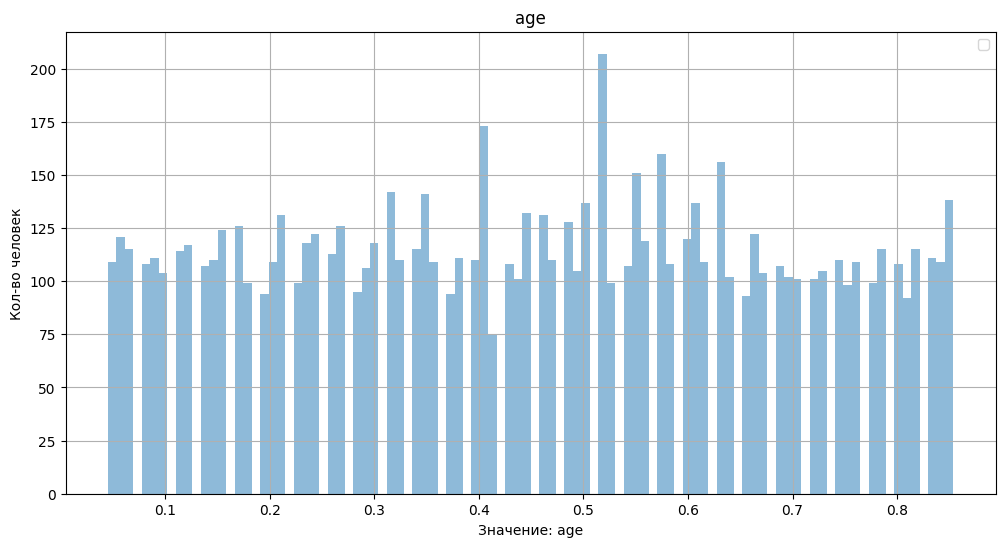

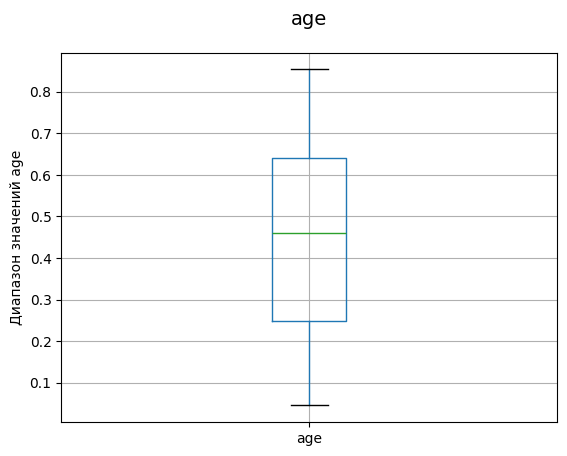

-----------------------------------------------------------
Распределение числовой величины: cholesterol
count    8442.000000
mean        0.501108
std         0.288785
min         0.000000
25%         0.260714
50%         0.496429
75%         0.750000
max         1.000000
Name: cholesterol, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


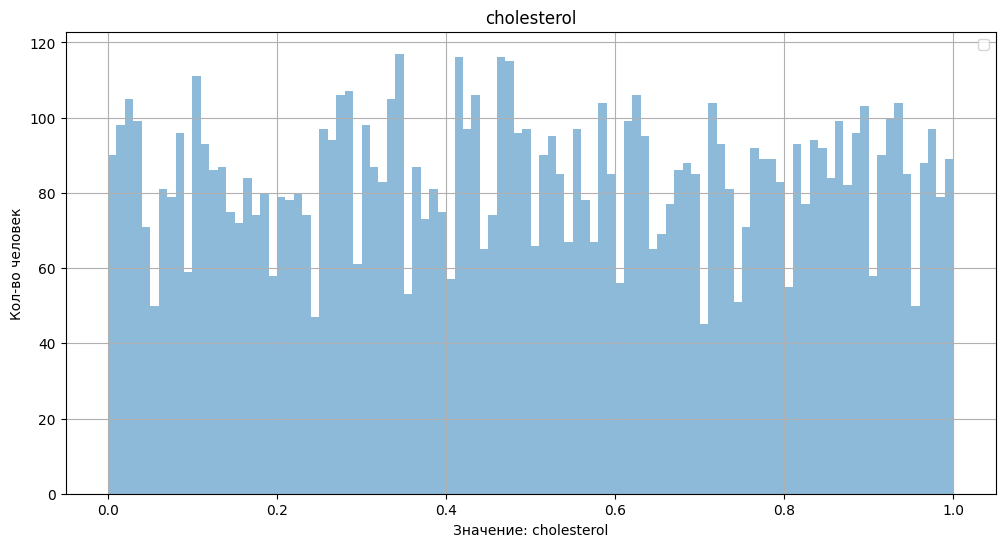

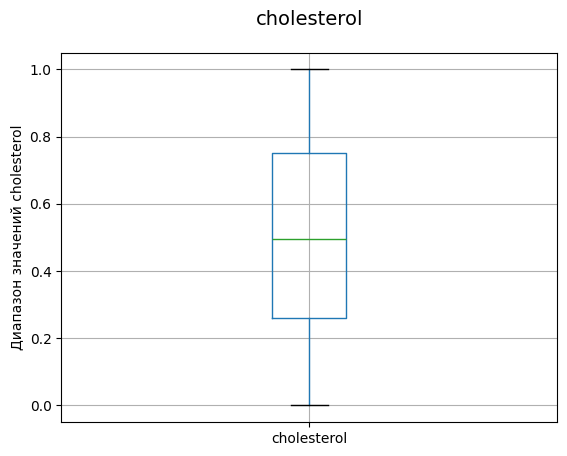

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: heart_rate
count    8442.000000
mean        0.050194
std         0.018442
min         0.018332
25%         0.034830
50%         0.050412
75%         0.065995
max         0.082493
Name: heart_rate, dtype: float64


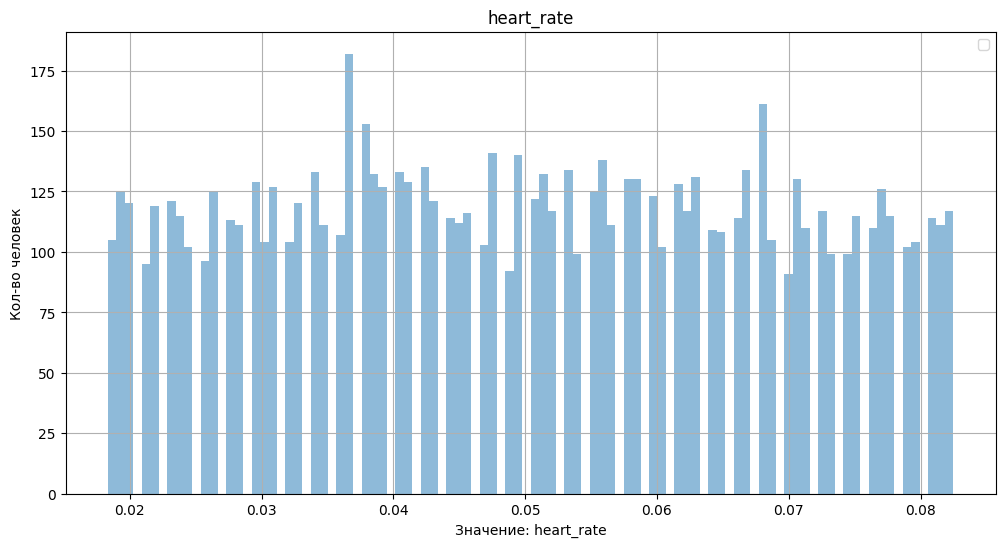

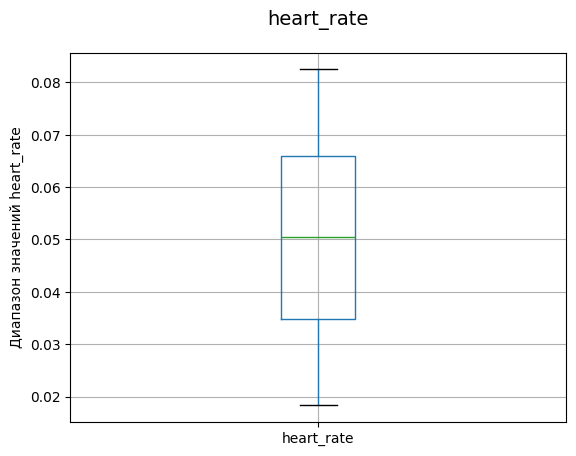

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: diabetes
count    8442.000000
mean        0.652097
std         0.476333
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: diabetes, dtype: float64


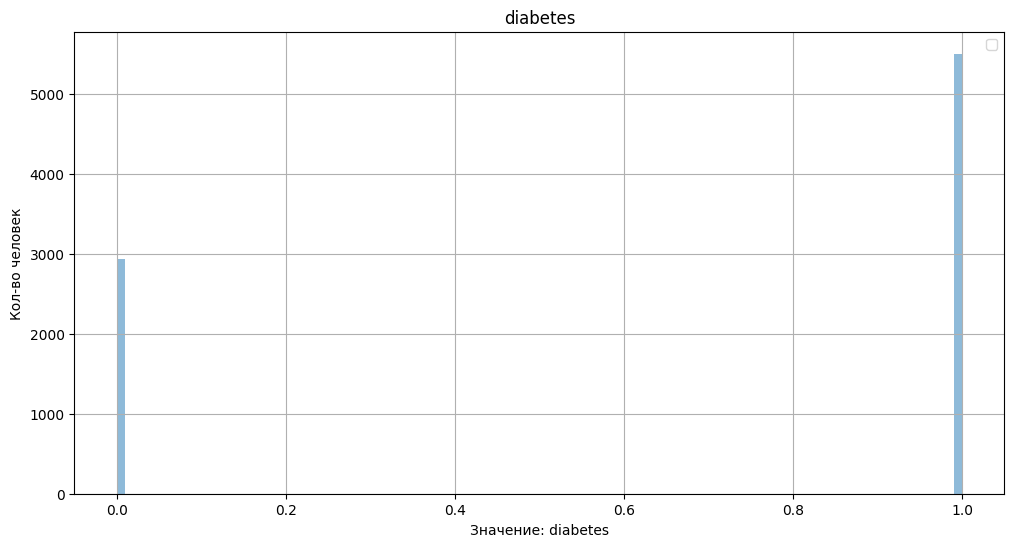

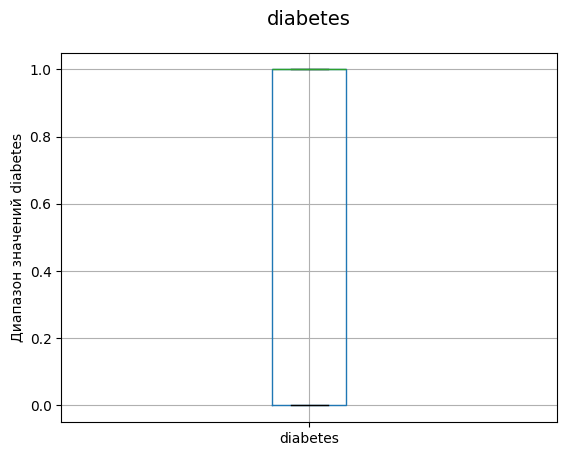

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: family_history
count    8442.000000
mean        0.489576
std         0.499921
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: family_history, dtype: float64


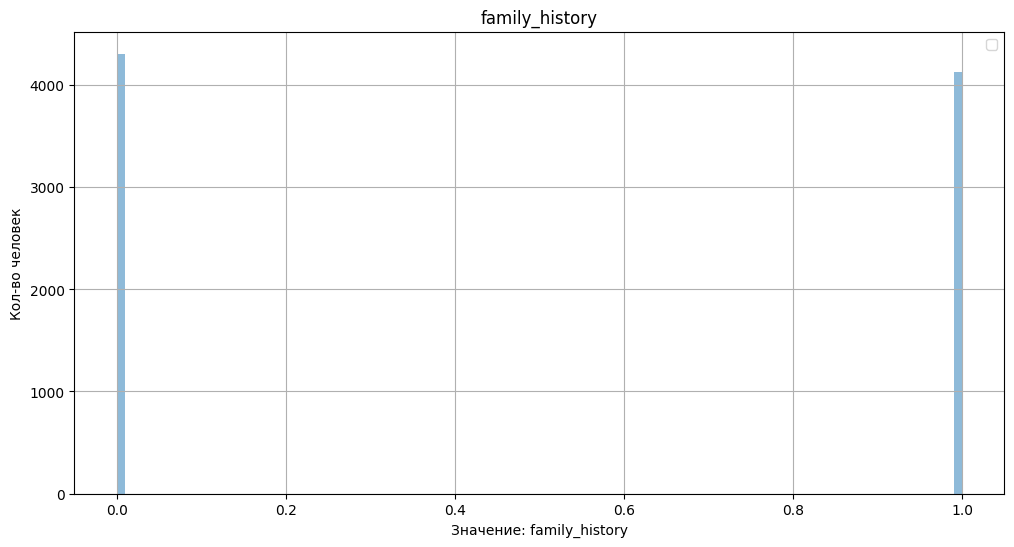

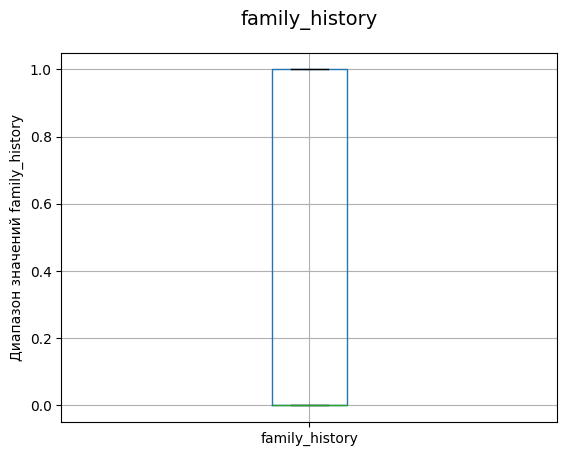

-----------------------------------------------------------
Распределение числовой величины: smoking
count    8442.000000
mean        0.902867
std         0.296157
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: smoking, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


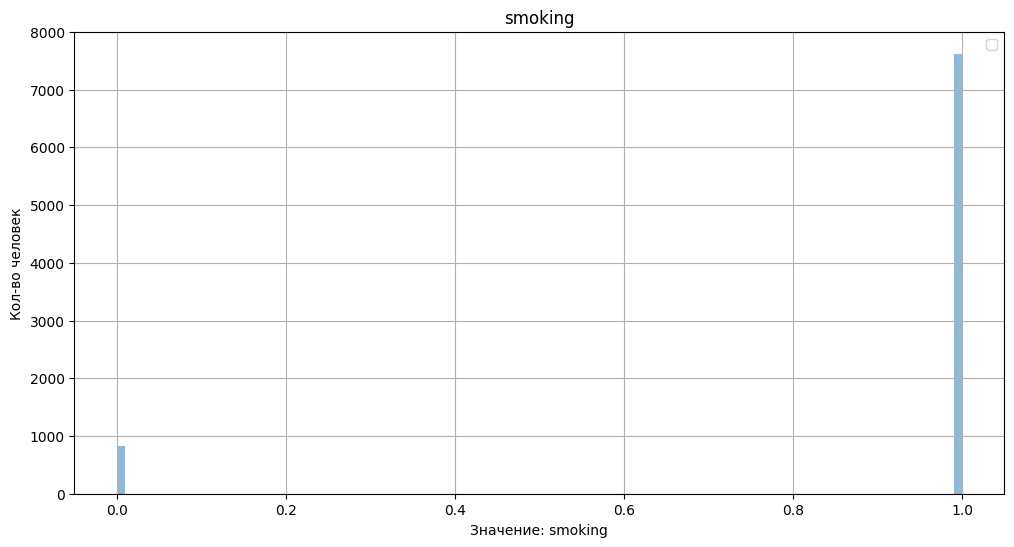

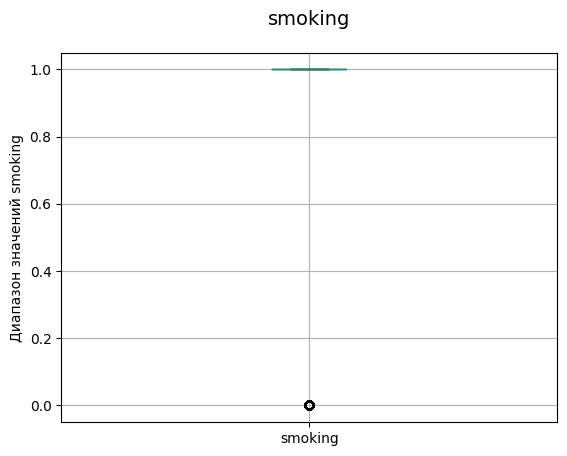

-----------------------------------------------------------
Распределение числовой величины: obesity
count    8442.000000
mean        0.498342
std         0.500027
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: obesity, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


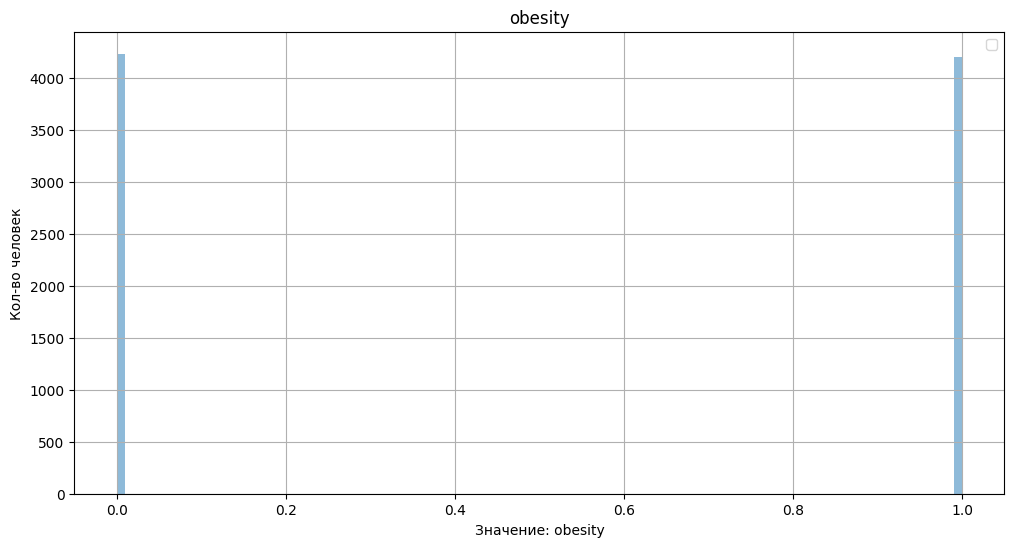

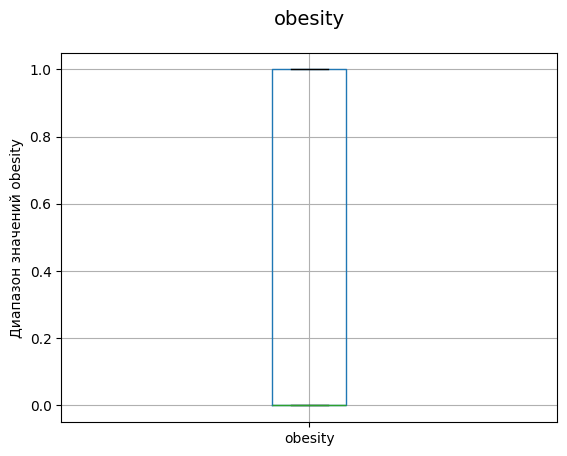

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: alcohol_consumption
count    8442.000000
mean        0.601990
std         0.489517
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: alcohol_consumption, dtype: float64


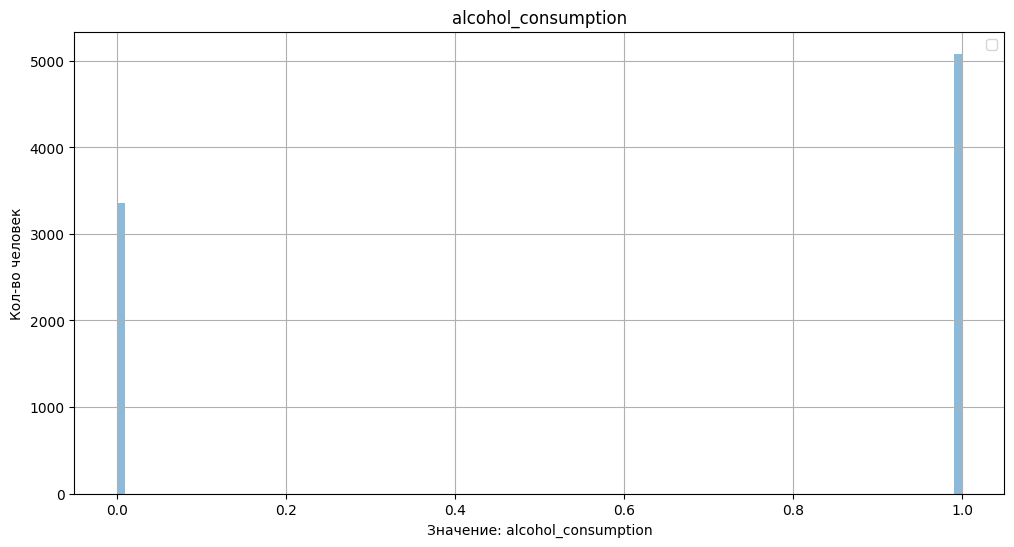

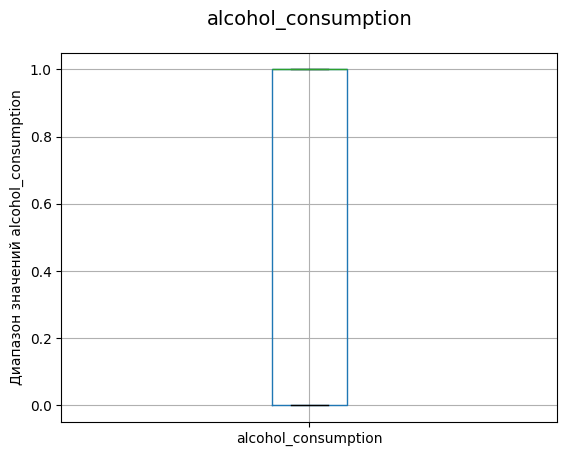

-----------------------------------------------------------
Распределение числовой величины: exercise_hours_per_week
count    8442.000000
mean        0.503415
std         0.288881
min         0.000000
25%         0.253359
50%         0.508244
75%         0.754901
max         1.000000
Name: exercise_hours_per_week, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


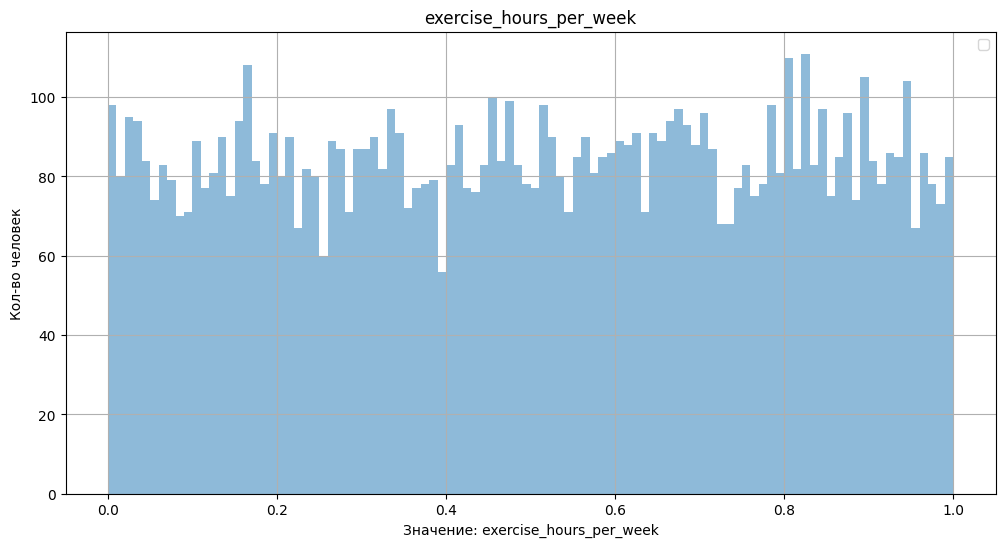

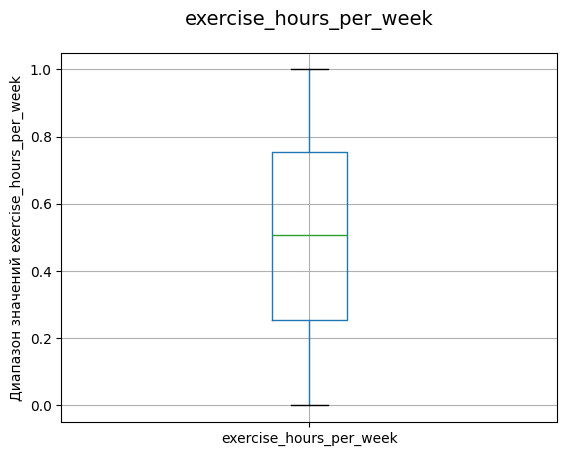

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: diet
count    8442.000000
mean        1.001540
std         0.812981
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: diet, dtype: float64


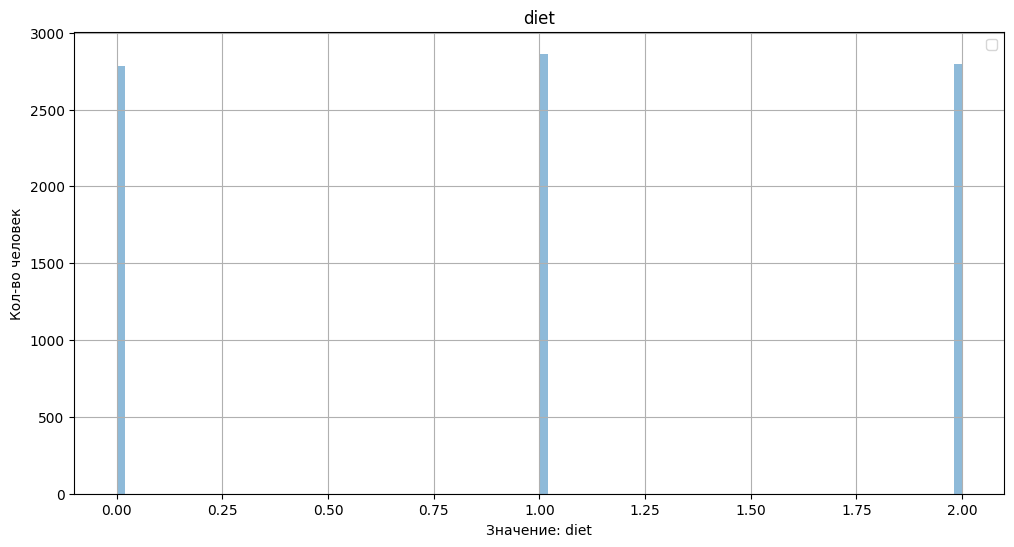

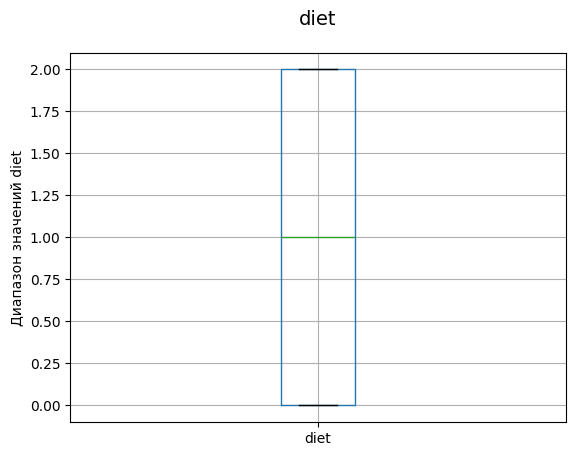

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: previous_heart_problems
count    8442.000000
mean        0.495380
std         0.500008
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: previous_heart_problems, dtype: float64


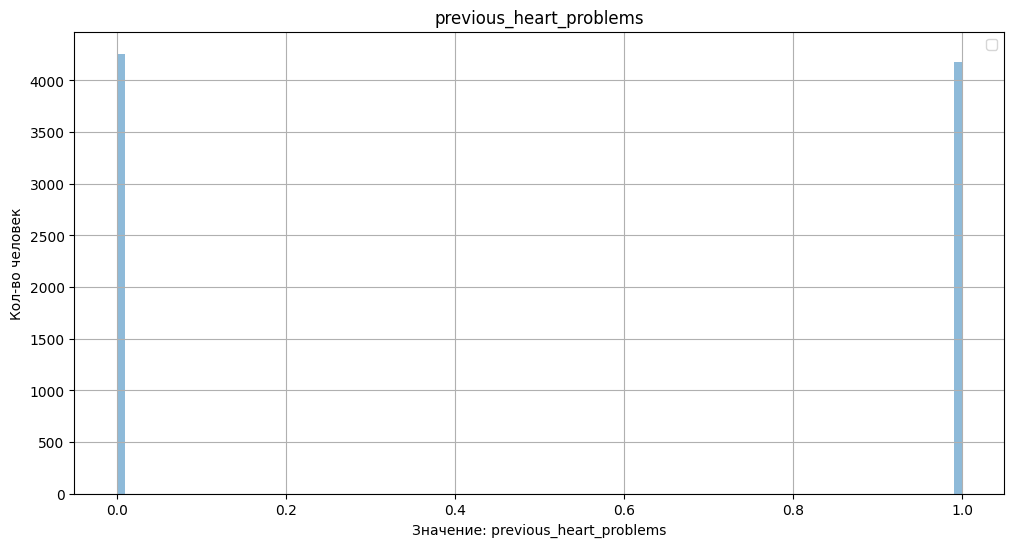

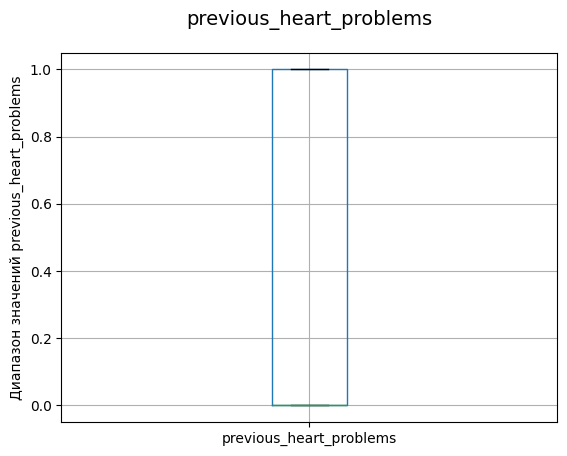

-----------------------------------------------------------
Распределение числовой величины: medication_use
count    8442.000000
mean        0.501185
std         0.500028
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: medication_use, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


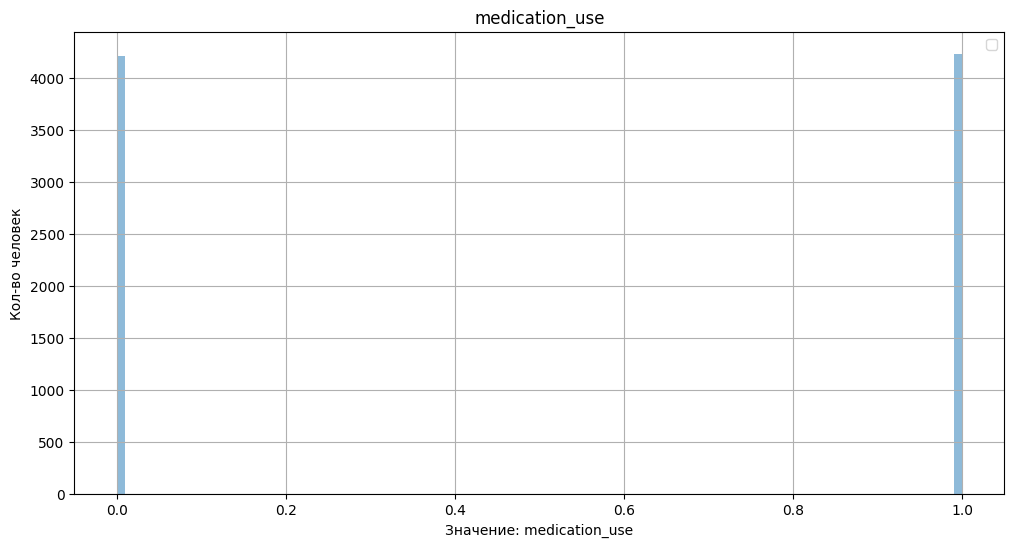

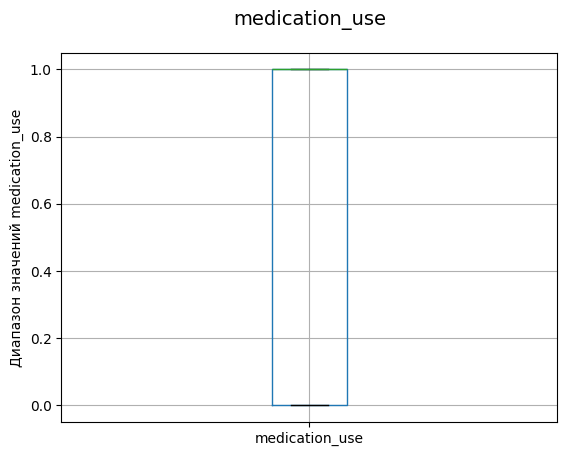

-----------------------------------------------------------
Распределение числовой величины: stress_level
count    8442.000000
mean        5.493367
std         2.867862
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: stress_level, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


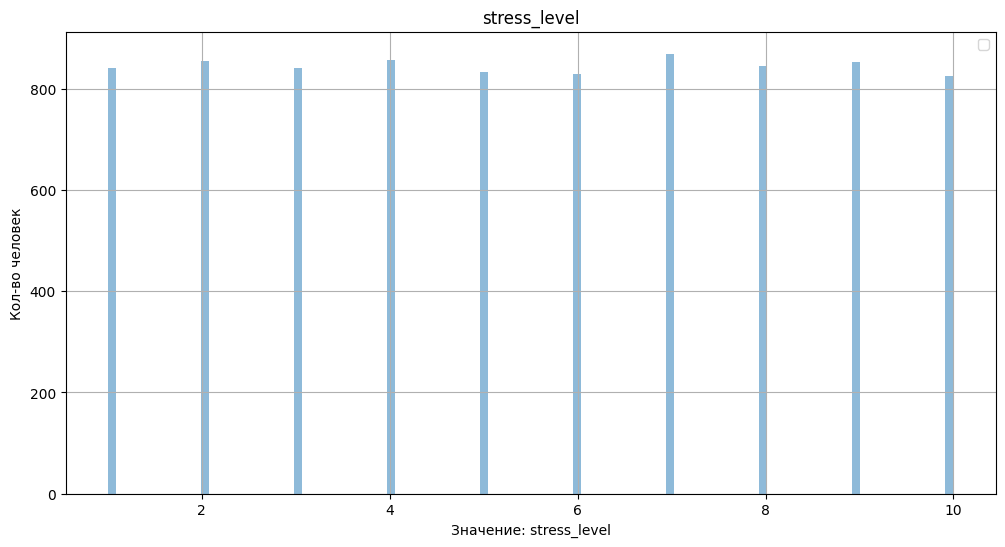

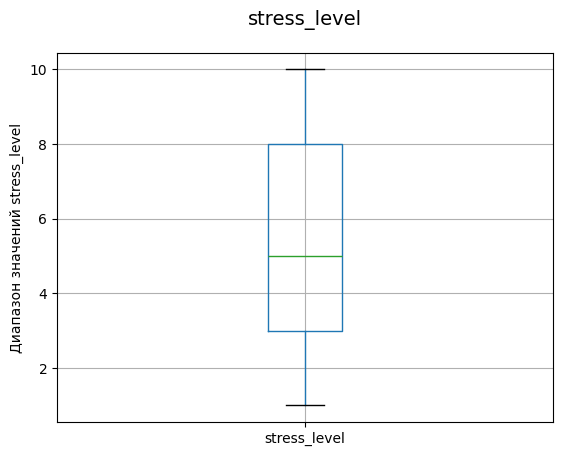

-----------------------------------------------------------
Распределение числовой величины: sedentary_hours_per_day
count    8442.000000
mean        0.499142
std         0.289418
min         0.000000
25%         0.247650
50%         0.492734
75%         0.751047
max         1.000000
Name: sedentary_hours_per_day, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


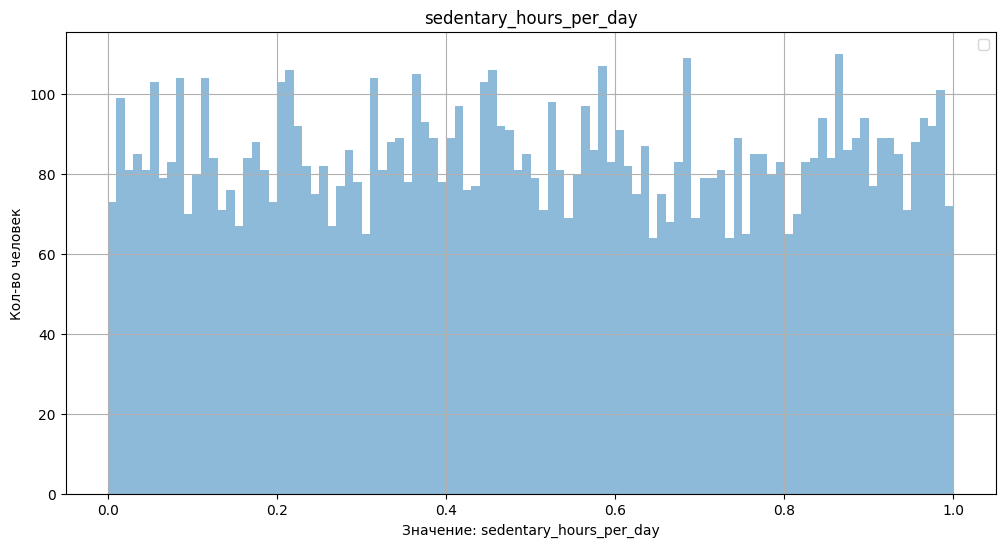

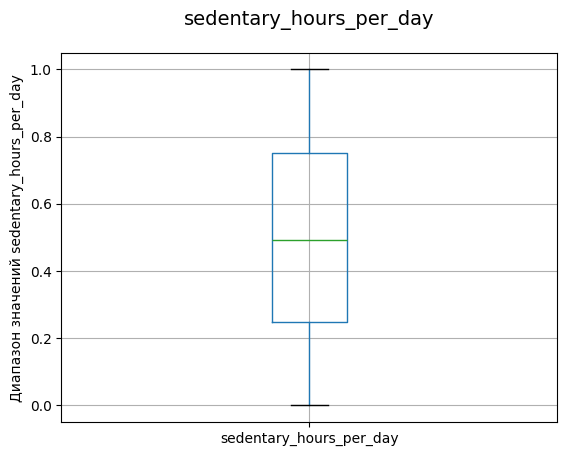

-----------------------------------------------------------
Распределение числовой величины: income
count    8442.000000
mean        0.496089
std         0.288767
min         0.000000
25%         0.244591
50%         0.496052
75%         0.747603
max         1.000000
Name: income, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


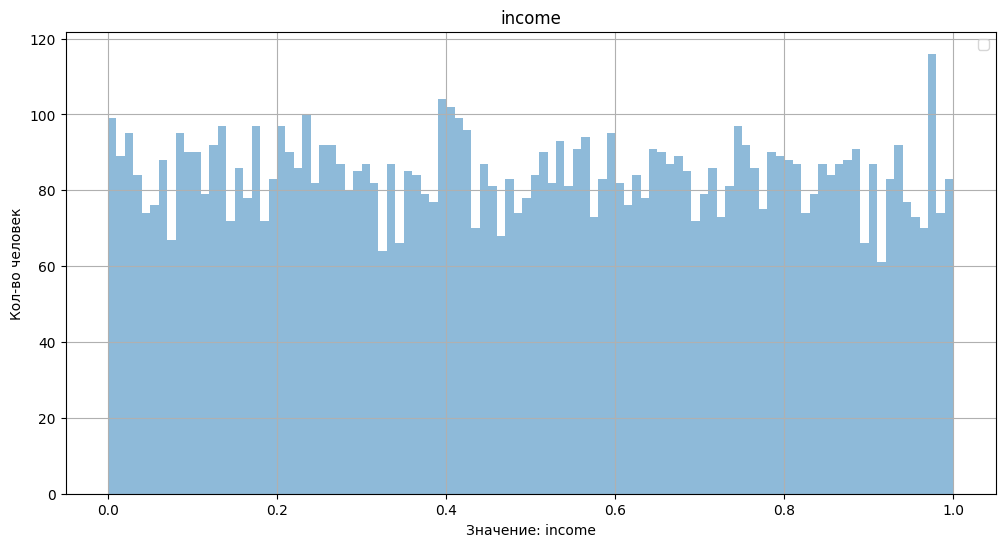

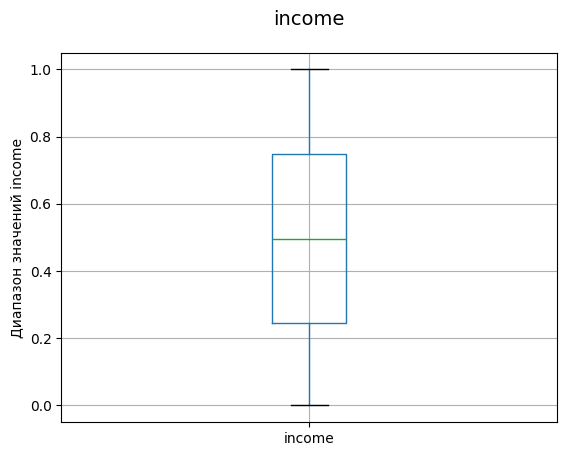

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: bmi
count    8442.000000
mean        0.496831
std         0.286599
min         0.000000
25%         0.247935
50%         0.490801
75%         0.744399
max         1.000000
Name: bmi, dtype: float64


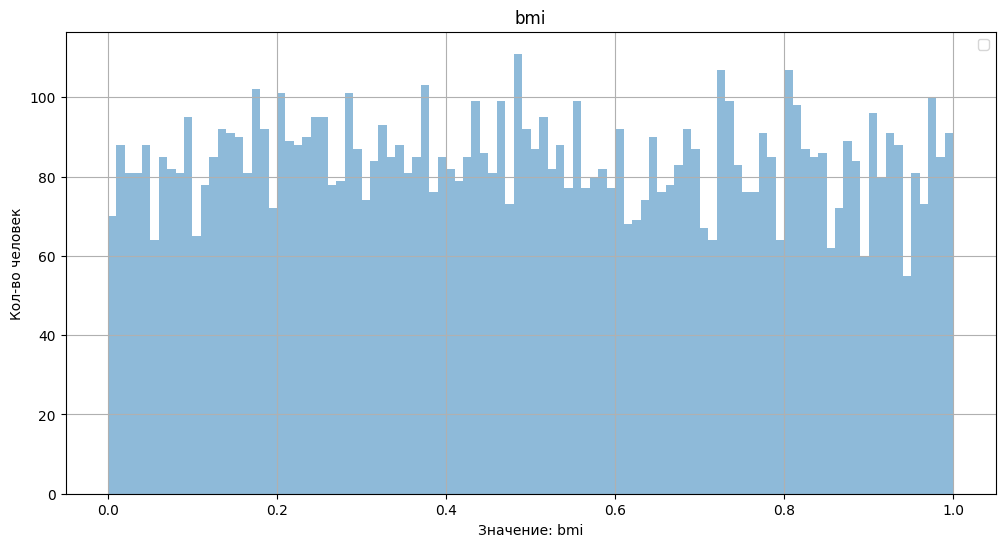

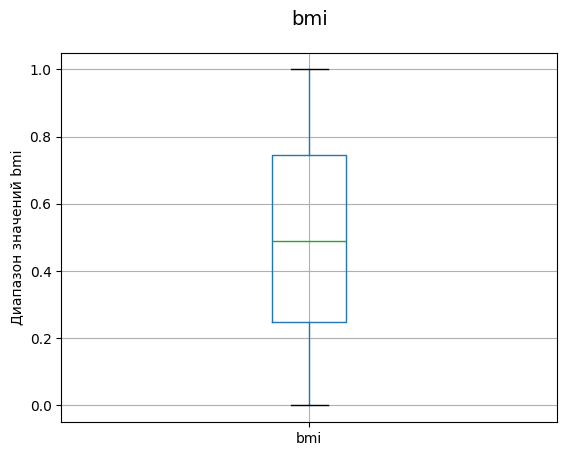

-----------------------------------------------------------
Распределение числовой величины: triglycerides
count    8442.000000
mean        0.505539
std         0.290412
min         0.000000
25%         0.257143
50%         0.507792
75%         0.758442
max         1.000000
Name: triglycerides, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


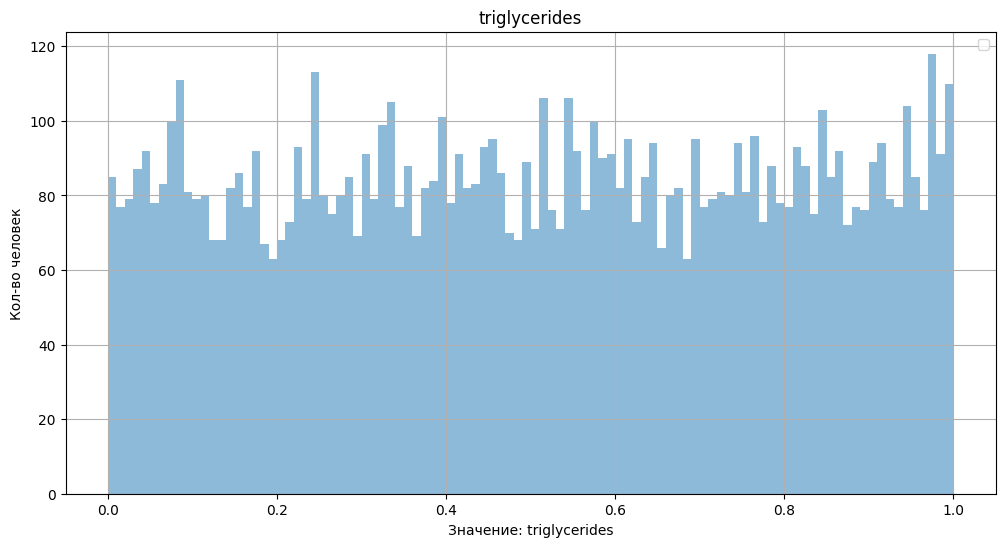

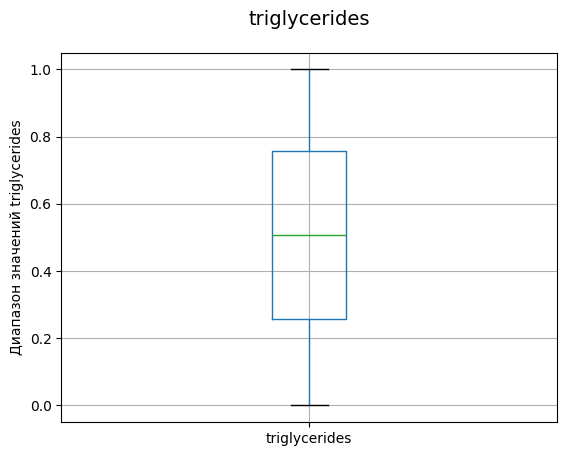

-----------------------------------------------------------
Распределение числовой величины: physical_activity_days_per_week
count    8442.000000
mean        3.508292
std         2.281772
min         0.000000
25%         2.000000
50%         3.000000
75%         6.000000
max         7.000000
Name: physical_activity_days_per_week, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


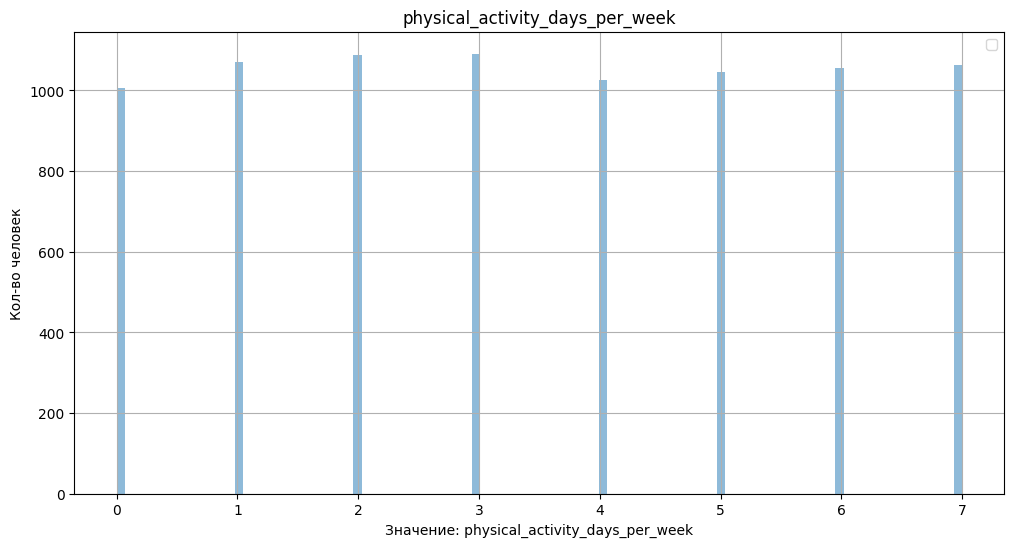

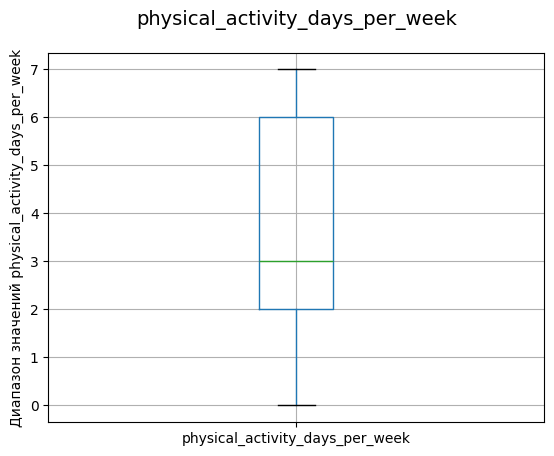

-----------------------------------------------------------
Распределение числовой величины: sleep_hours_per_day
count    8442.000000
mean        0.503712
std         0.332749
min         0.000000
25%         0.166667
50%         0.500000
75%         0.833333
max         1.000000
Name: sleep_hours_per_day, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


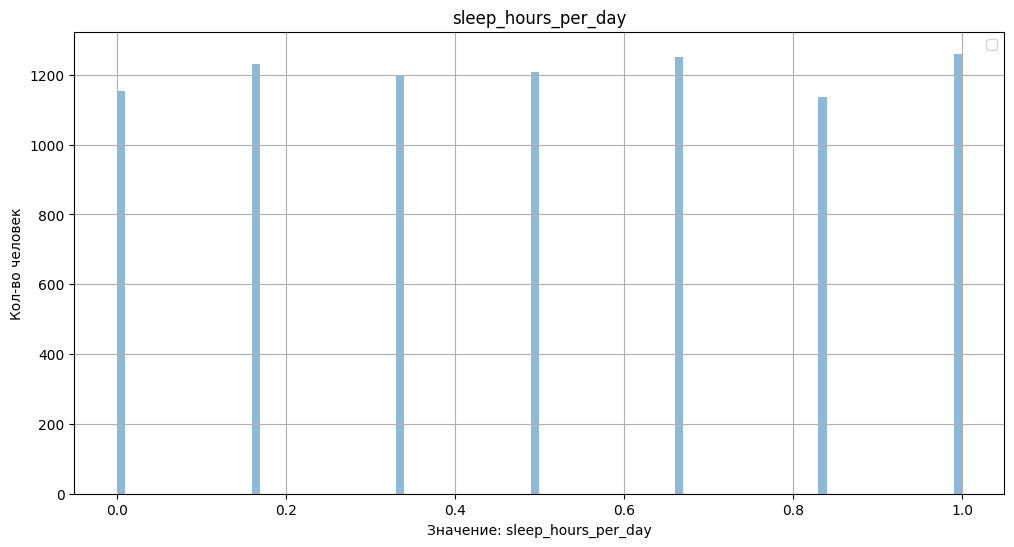

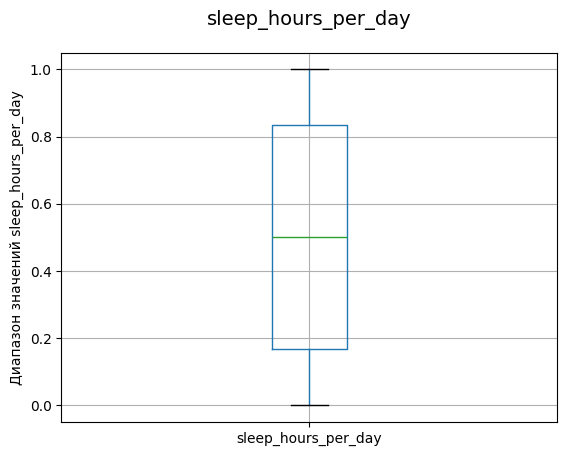

-----------------------------------------------------------
Распределение числовой величины: heart_attack_risk_(binary)
count    8442.000000
mean        0.356906
std         0.479115
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: heart_attack_risk_(binary), dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


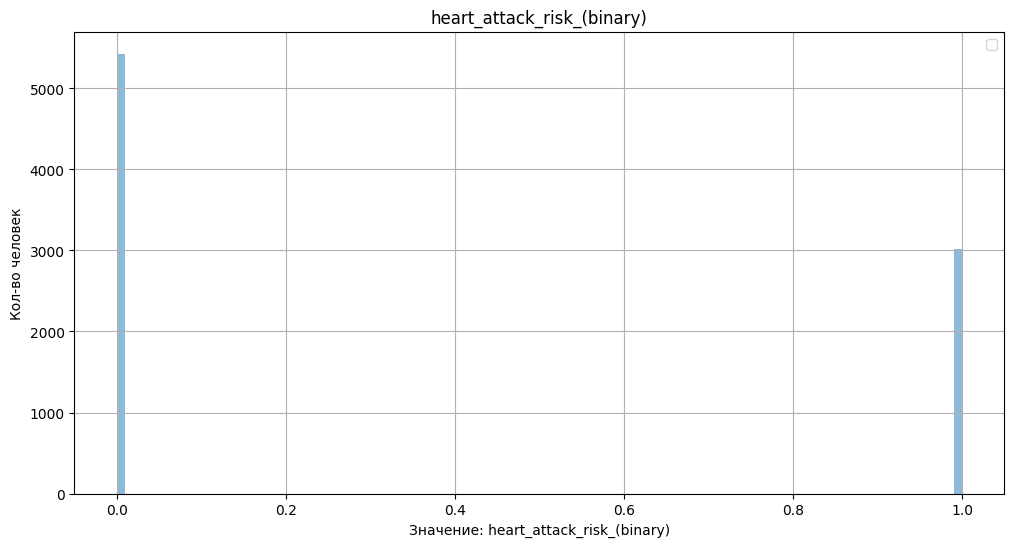

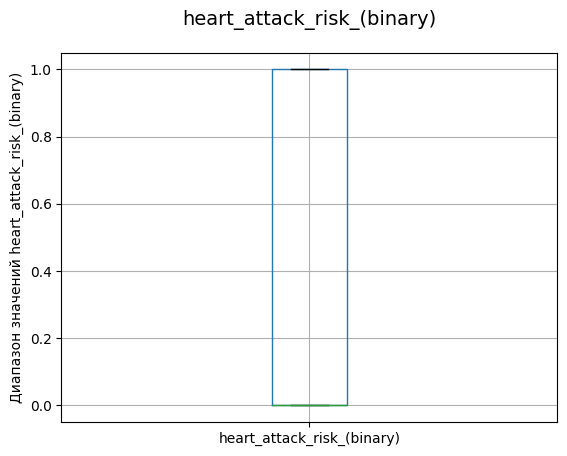

-----------------------------------------------------------
Распределение числовой величины: blood_sugar
count    8442.000000
mean        0.227998
std         0.074623
min         0.000000
25%         0.227018
50%         0.227018
75%         0.227018
max         1.000000
Name: blood_sugar, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


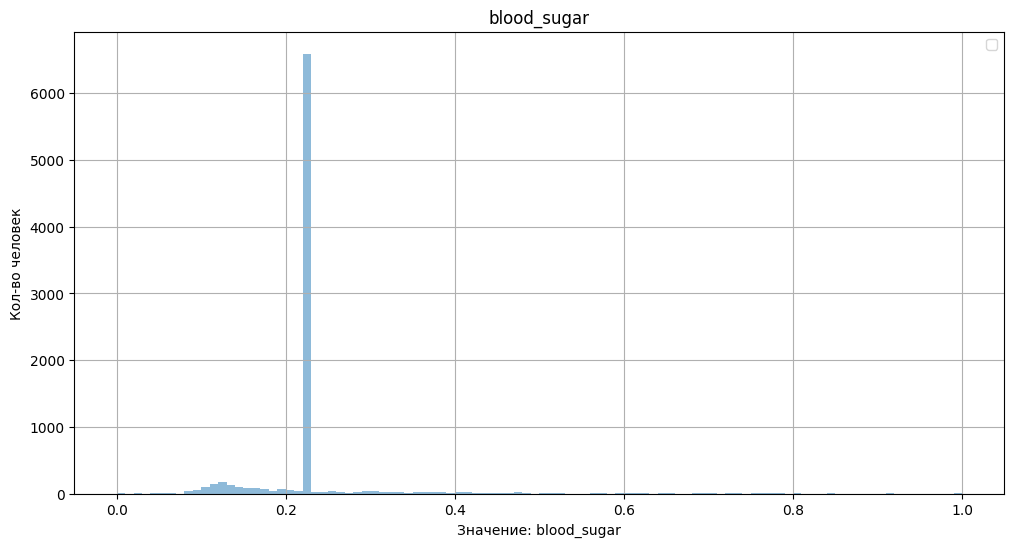

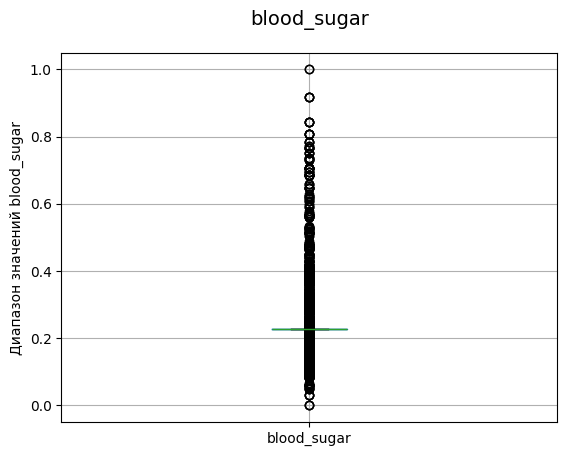

-----------------------------------------------------------
Распределение числовой величины: ck-mb
count    8442.000000
mean        0.047745
std         0.070399
min         0.000000
25%         0.048229
50%         0.048229
75%         0.048229
max         1.000000
Name: ck-mb, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


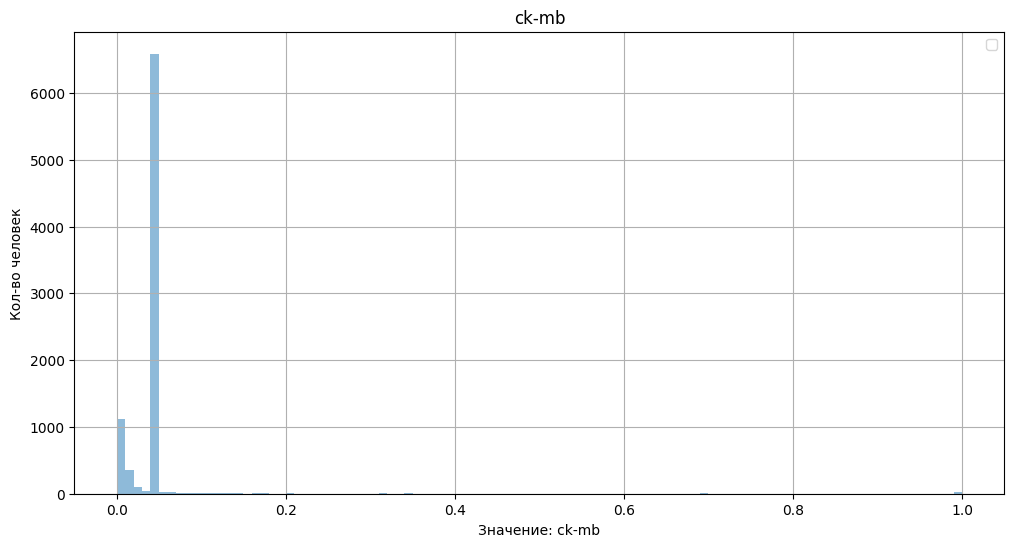

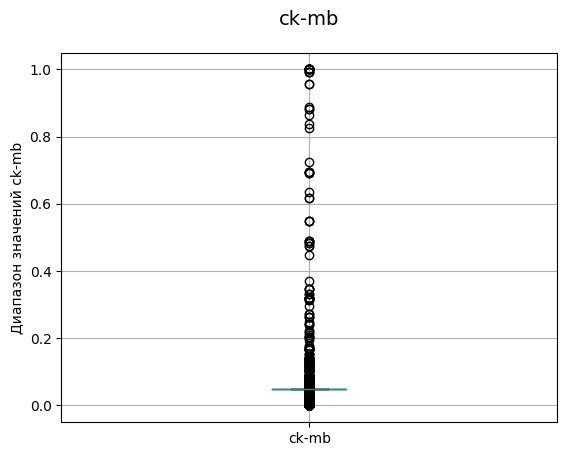

-----------------------------------------------------------
Распределение числовой величины: troponin
count    8442.000000
mean        0.036867
std         0.059284
min         0.000000
25%         0.036512
50%         0.036512
75%         0.036512
max         1.000000
Name: troponin, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


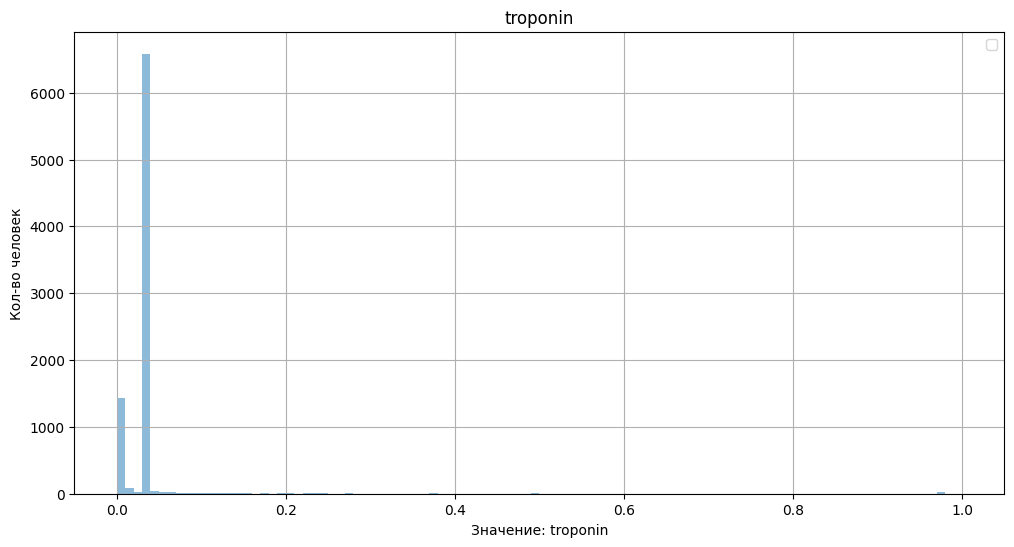

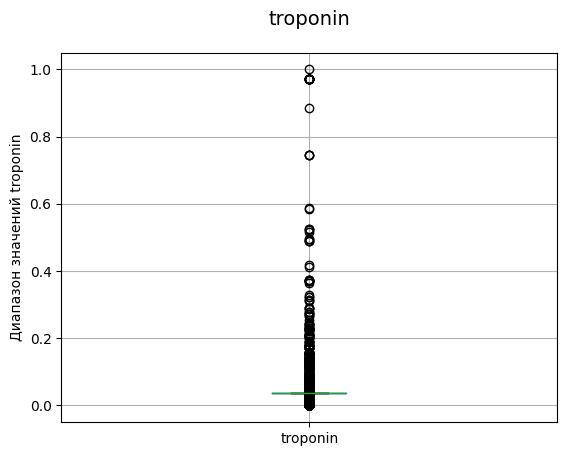

-----------------------------------------------------------
Распределение категориальной величины: gender


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


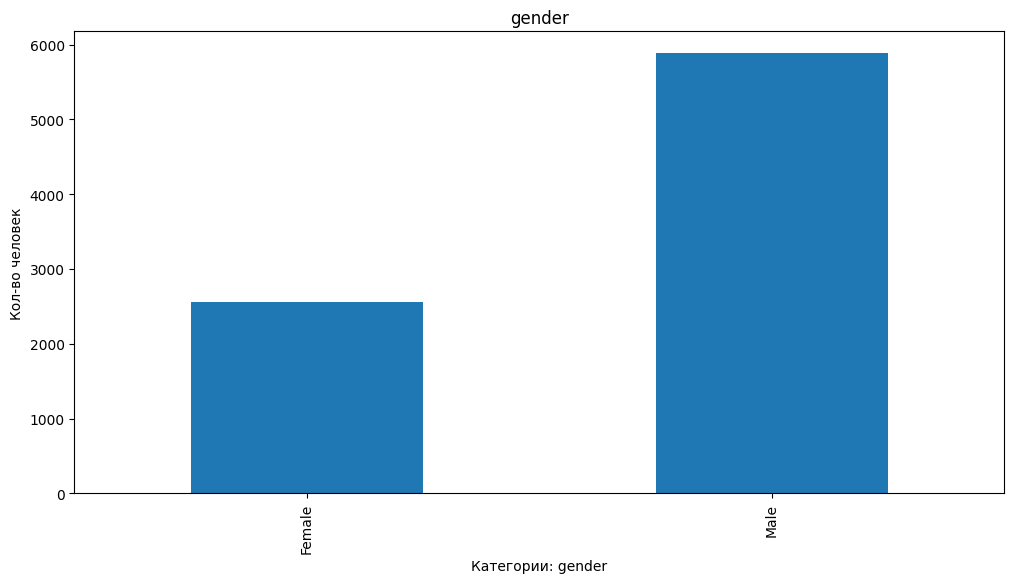

-----------------------------------------------------------
Распределение числовой величины: systolic_blood_pressure
count    8442.000000
mean        0.451955
std         0.170187
min         0.161290
25%         0.303226
50%         0.451613
75%         0.600000
max         0.741935
Name: systolic_blood_pressure, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


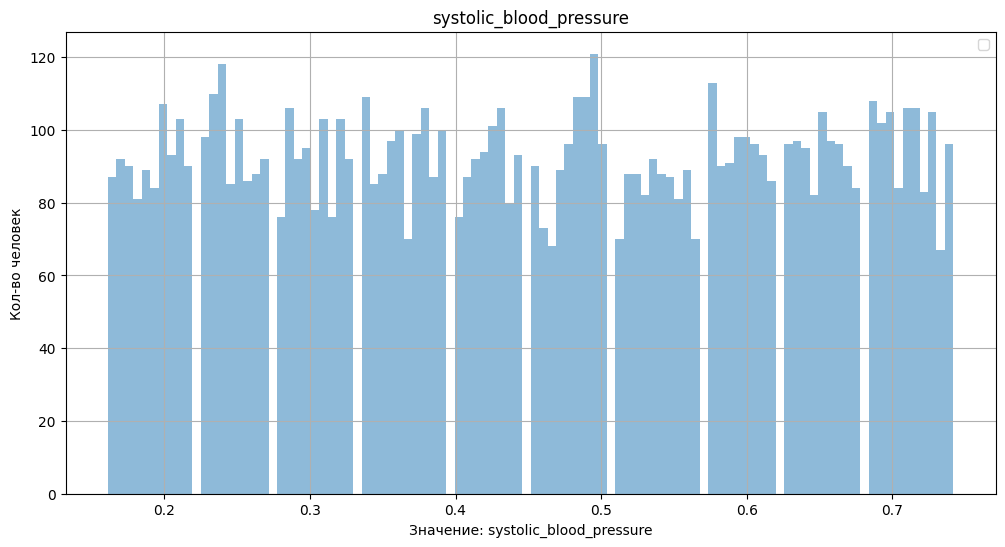

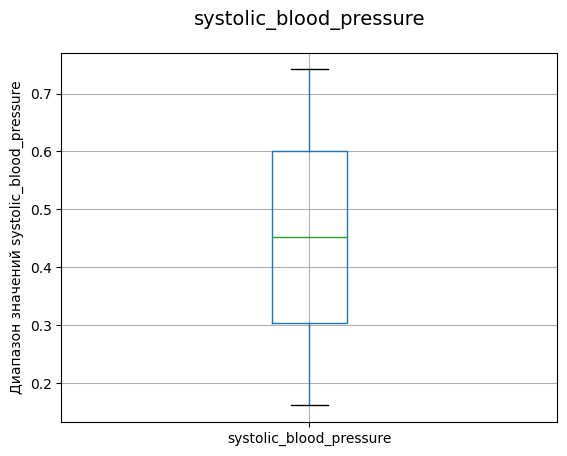

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: diastolic_blood_pressure
count    8442.000000
mean        0.501672
std         0.170302
min         0.209302
25%         0.348837
50%         0.500000
75%         0.651163
max         0.790698
Name: diastolic_blood_pressure, dtype: float64


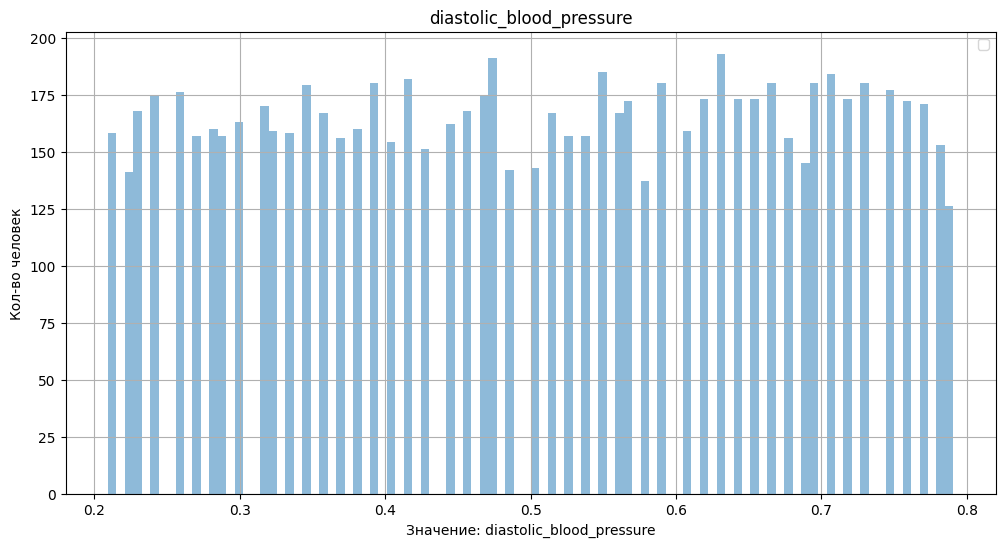

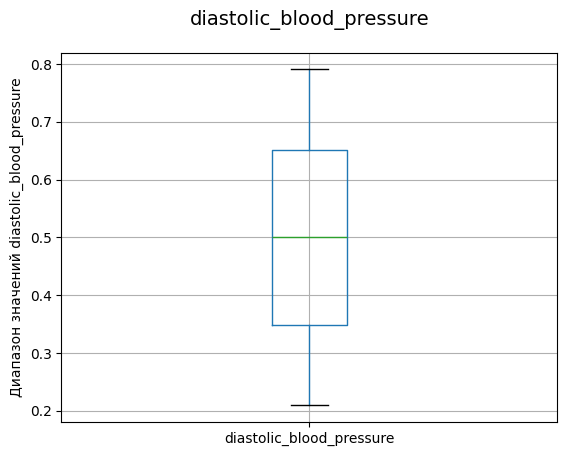

-----------------------------------------------------------
Анализ уникальных идентификаторов: id
Уникальных ID: 8442 из 8442 записей


In [24]:
visualize_stats(df_train_cleaned)

**Заметки**

 | column | type | comment |
 | --- | --- | --- |
 | age | float64 | нормированная величина, нормальное распределение |
 | cholesterol | float64 | нормированная величина, равномерное распределение |
 | heart_rate | float64 | нормированная величина, нормальное распределение, есть выбросы |
 | diabetes | float64 | бинарная классификация |
 | family_history | float64 |  бинарная классификация |
 | smoking | float64 | бинарная классификация |
 | obesity | float64 | бинарная классификация |
 | alcohol_consumption | float64 | бинарная классификация |
 | exercise_hours_per_week | float64 | нормированная величина, равномерное распределение |
 | diet | int64 | категориальный признак |  
 | previous_heart_problems  | float64 | бинарная классификация |
 | medication_use | float64 | бинарная классификация |
 | stress_level | float64 | дискретная величина |
 | sedentary_hours_per_day | float64 | нормированная величина, нормальное распределение |
 | income | float64 | нормированная величина, нормальное распределение |
 | bmi | float64 |  нормированная величина, нормальное распределение |
 | triglycerides | float64 |  нормированная величина, нормальное распределение |
 | physical_activity_days_per_week | float64 | дискретная величина |
 | sleep_hours_per_day | float64 | дискретная величина |
 | heart_attack_risk_(binary) | float64 | **целевой признак** |
 | blood_sugar | float64 | нормированная величина, есть выбросы |
 | ck-mb | float64 | нормированная величина, есть выбросы |
 | troponin | float64 | нормированная величина, есть выбросы |
 | gender | object | бинарная классификация, есть аномалии |
 | systolic_blood_pressure | float64 | нормированная величина, есть кластеры |
 | diastolic_blood_pressure | float64 | нормированная величина, есть кластеры |
 | id | int64 | уникальное значение |  

⚠️ Для `blood_sugar`, `ck-mb`, `troponin` заметно сравнительно большое кол-во одинаковых значений в районе среднего/медианы.

Преобразуем тип данных для бинарных признаков в  int для статистичесого анализа

In [25]:
fatures = df_train_cleaned.columns.tolist()

binary_features = []

for feature in fatures:
    if df_train_cleaned[feature].value_counts().shape[0] == 2:
        binary_features.append(feature)
    else:
      pass

binary_features

['diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'previous_heart_problems',
 'medication_use',
 'heart_attack_risk_(binary)',
 'gender']

In [26]:
df_train_cleaned = df_train_cleaned.copy()

for feature in binary_features:
    if df_train_cleaned[feature].dtype == 'float64':
        df_train_cleaned[feature] = df_train_cleaned[feature].astype(int)
    else:
        pass

In [30]:
# fatures = df_test_cleaned.columns.tolist()

# binary_features = []

# for feature in fatures:
#     if df_test_cleaned[feature].value_counts().shape[0] == 2:
#         binary_features.append(feature)
#     else:
#       pass

# binary_features

In [31]:
# df_test_cleaned = df_test_cleaned.copy()

# for feature in binary_features:
#     if df_test_cleaned[feature].dtype == 'float64':
#         df_test_cleaned[feature] = df_test_cleaned[feature].astype(int)
#     else:
#         pass

-----------------------------------------------------------
Распределение числовой величины: age
count    8442.000000
mean        0.449008
std         0.232809
min         0.044944
25%         0.247191
50%         0.460674
75%         0.640449
max         0.853933
Name: age, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


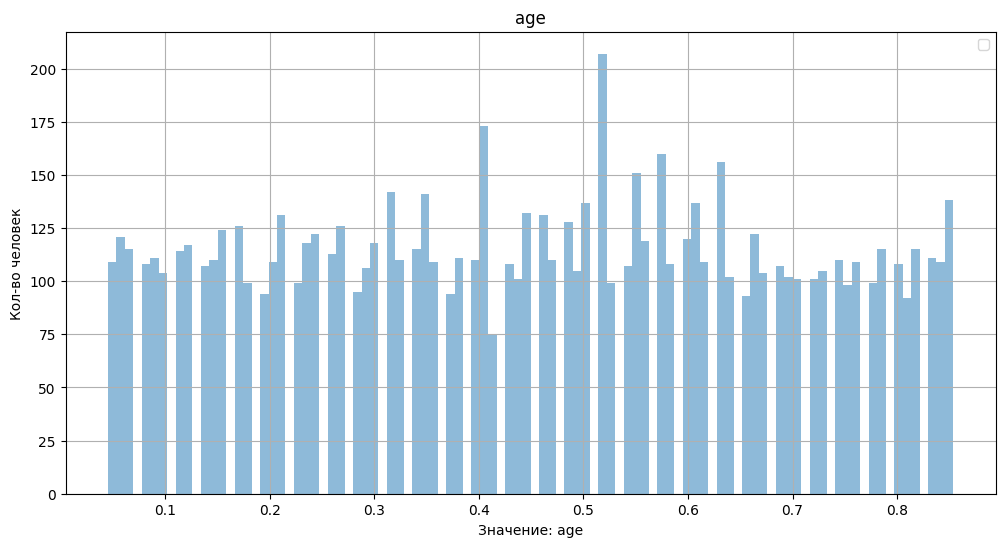

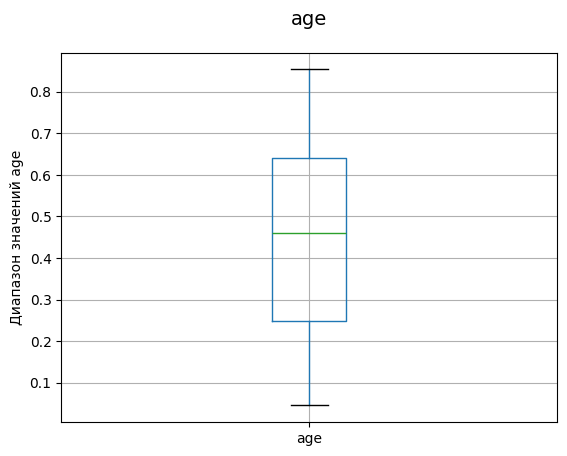

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: cholesterol
count    8442.000000
mean        0.501108
std         0.288785
min         0.000000
25%         0.260714
50%         0.496429
75%         0.750000
max         1.000000
Name: cholesterol, dtype: float64


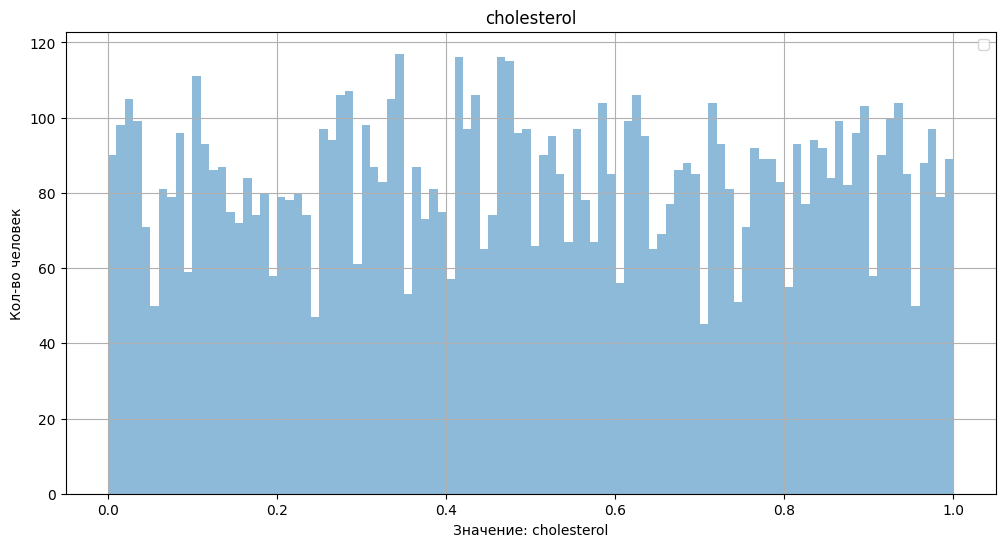

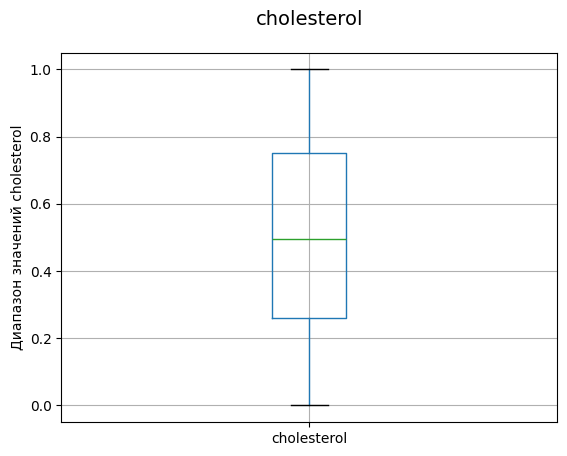

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: heart_rate
count    8442.000000
mean        0.050194
std         0.018442
min         0.018332
25%         0.034830
50%         0.050412
75%         0.065995
max         0.082493
Name: heart_rate, dtype: float64


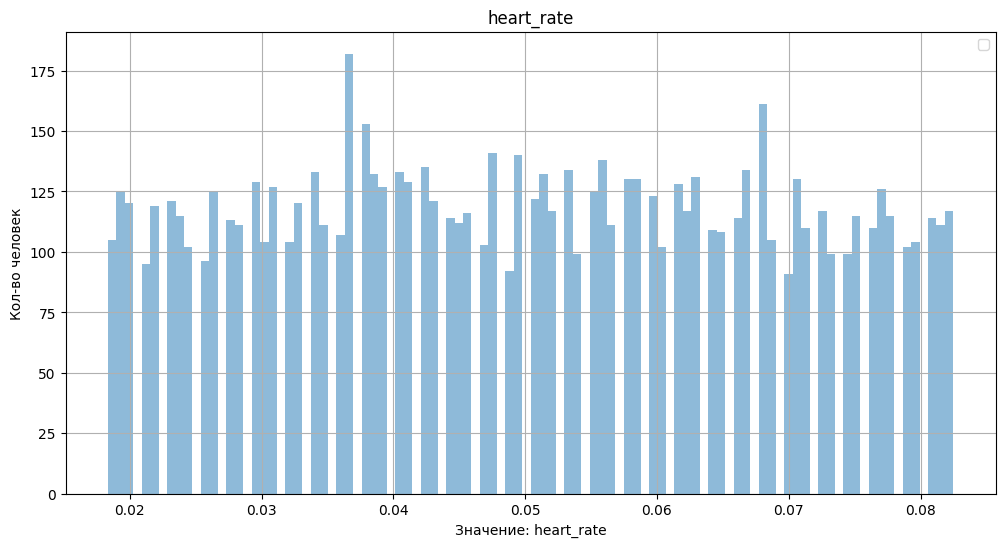

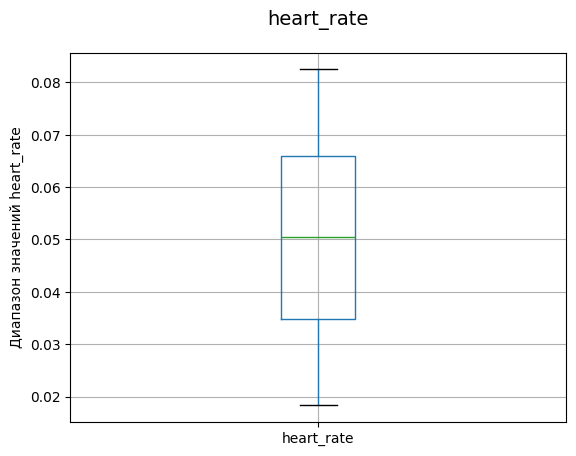

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


-----------------------------------------------------------
Распределение числовой величины: diabetes
count    8442.000000
mean        0.652097
std         0.476333
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: diabetes, dtype: float64


/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


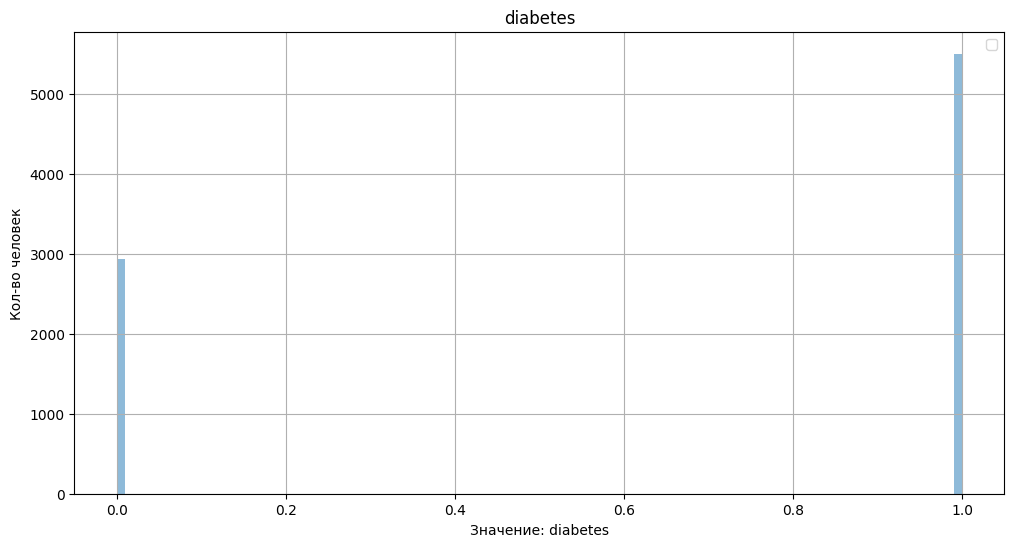

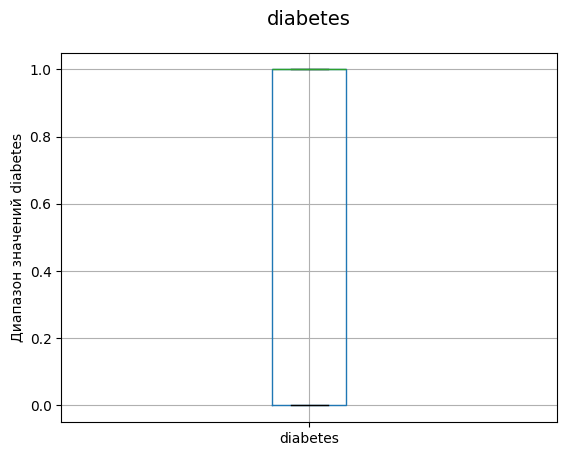

-----------------------------------------------------------
Распределение числовой величины: family_history
count    8442.000000
mean        0.489576
std         0.499921
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: family_history, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


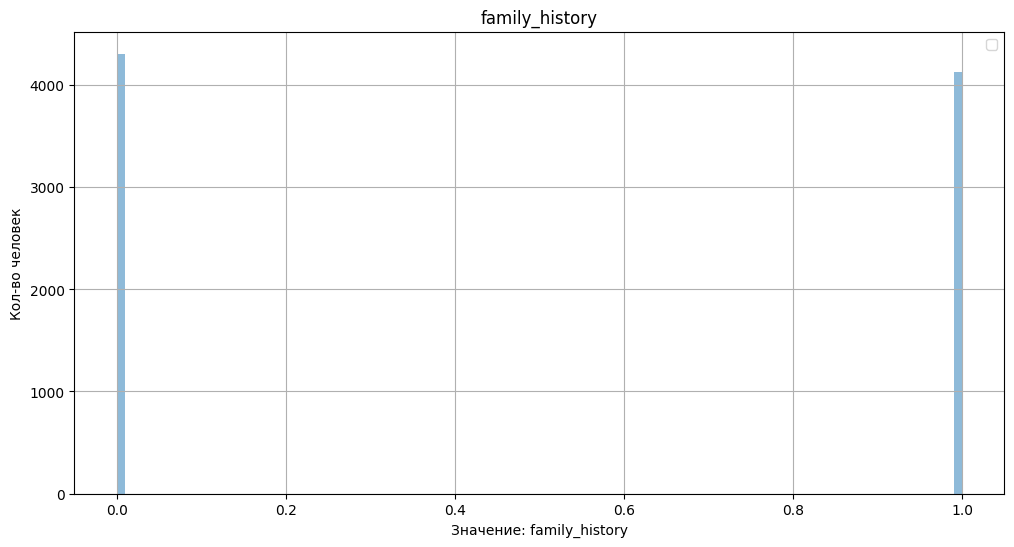

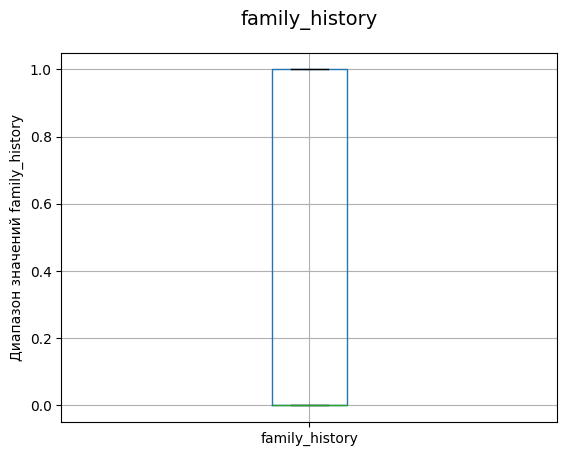

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: smoking
count    8442.000000
mean        0.902867
std         0.296157
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: smoking, dtype: float64


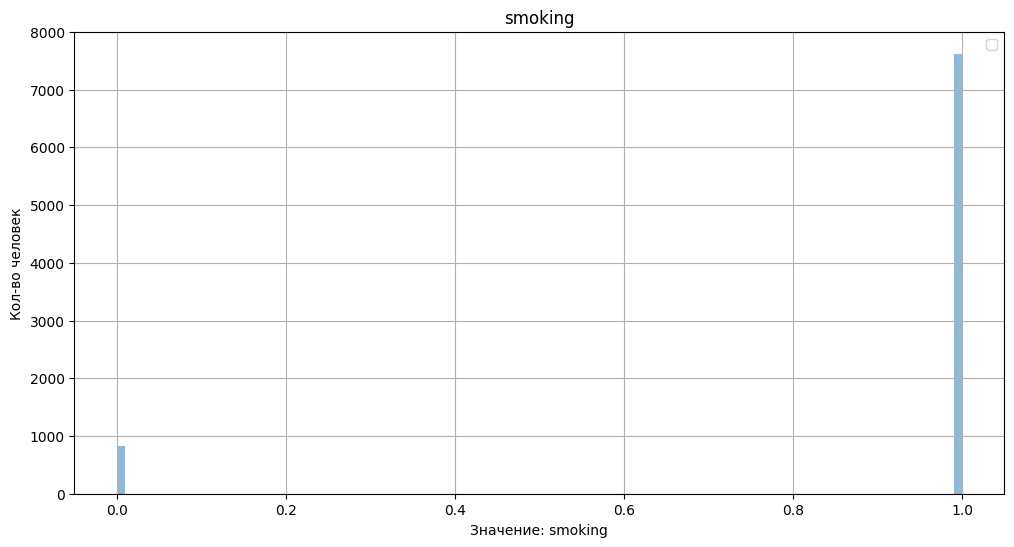

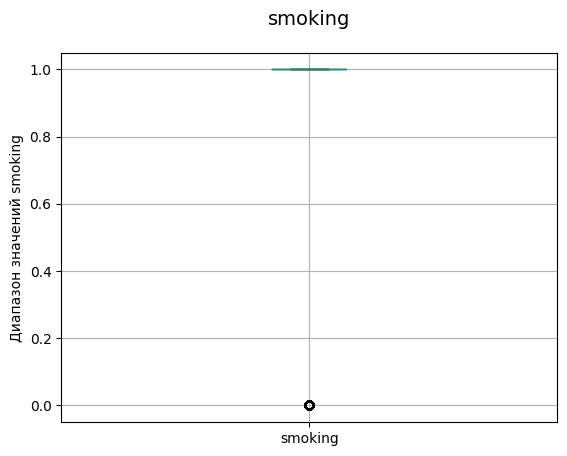

-----------------------------------------------------------
Распределение числовой величины: obesity
count    8442.000000
mean        0.498342
std         0.500027
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: obesity, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


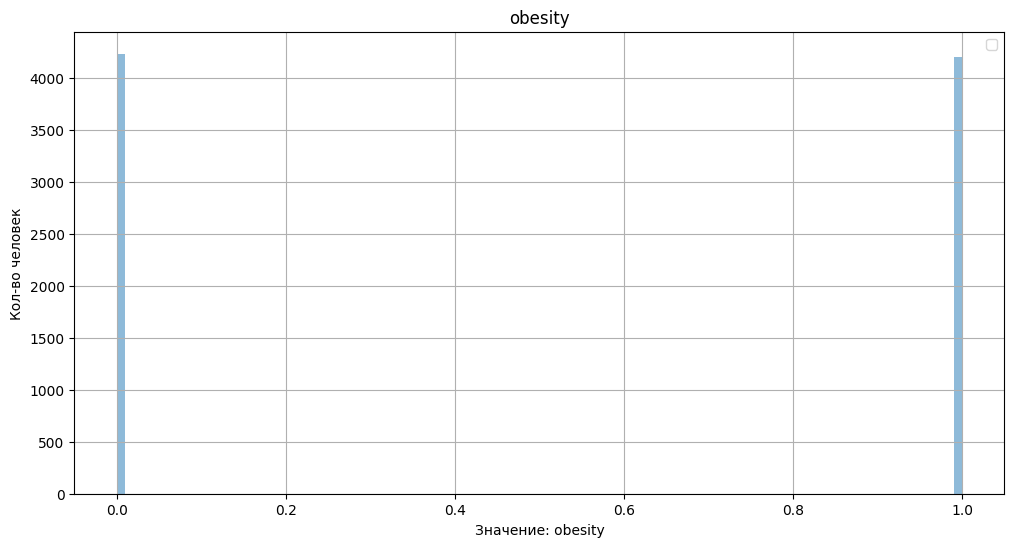

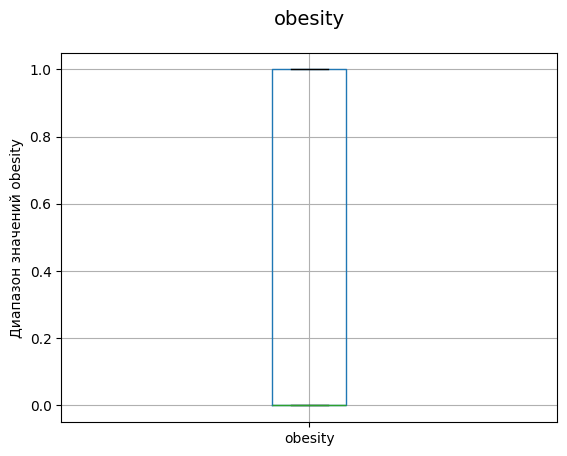

-----------------------------------------------------------
Распределение числовой величины: alcohol_consumption
count    8442.000000
mean        0.601990
std         0.489517
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: alcohol_consumption, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


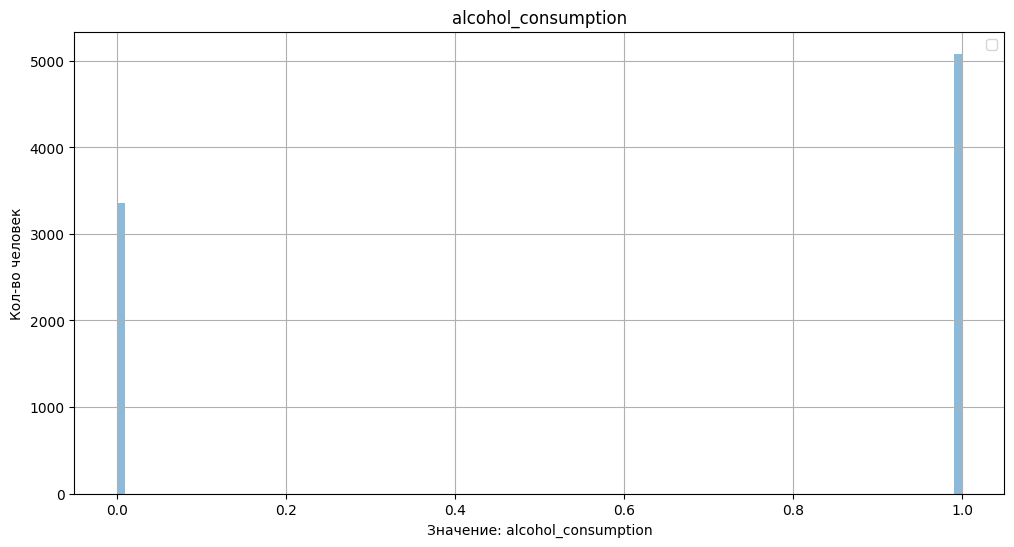

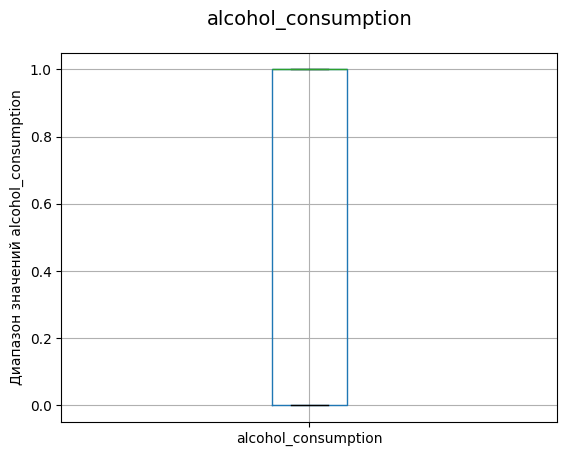

-----------------------------------------------------------
Распределение числовой величины: exercise_hours_per_week
count    8442.000000
mean        0.503415
std         0.288881
min         0.000000
25%         0.253359
50%         0.508244
75%         0.754901
max         1.000000
Name: exercise_hours_per_week, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


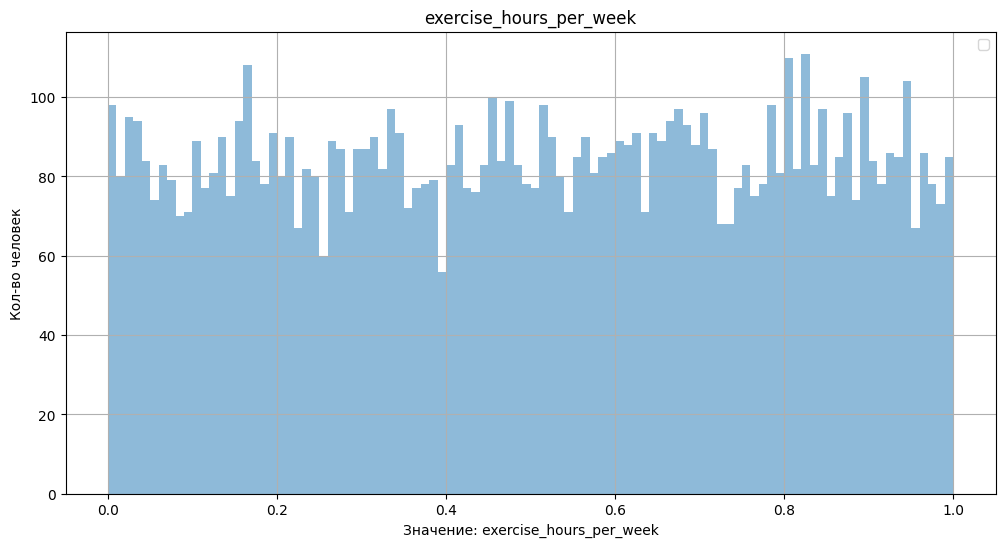

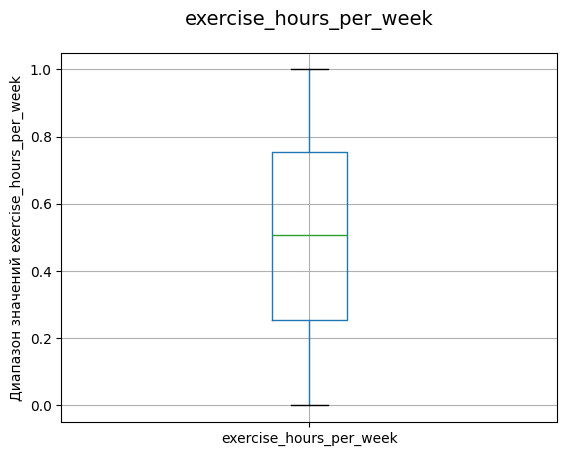

-----------------------------------------------------------
Распределение числовой величины: diet
count    8442.000000
mean        1.001540
std         0.812981
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: diet, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


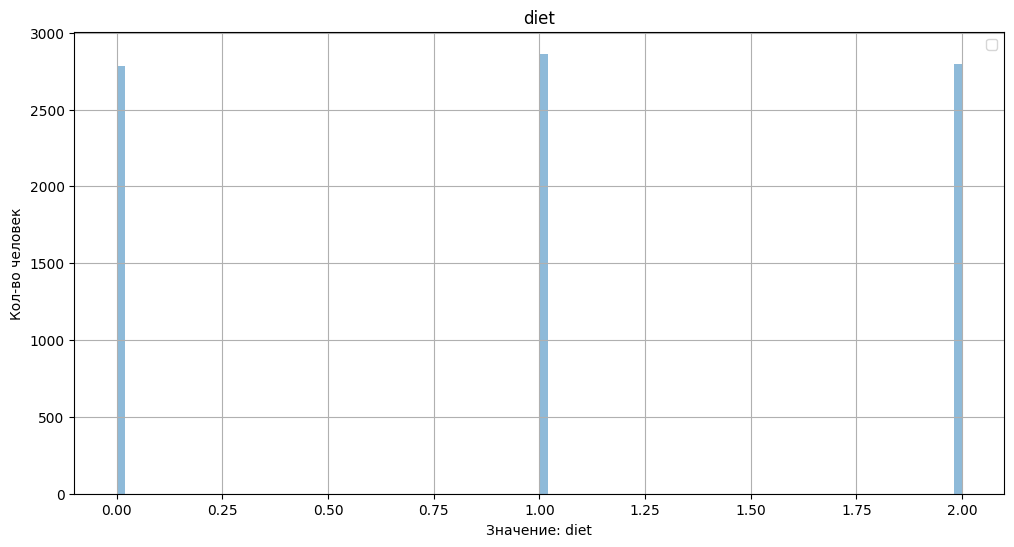

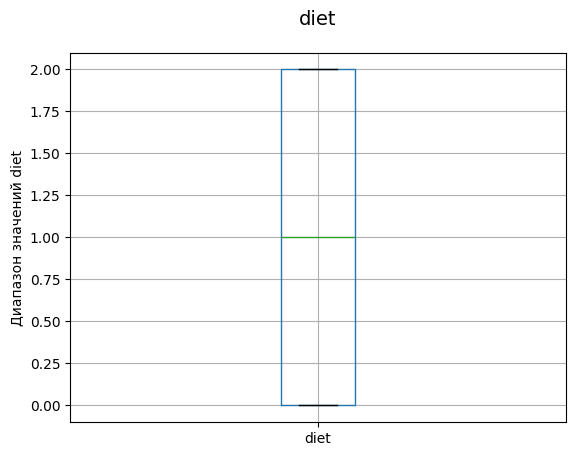

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: previous_heart_problems
count    8442.000000
mean        0.495380
std         0.500008
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: previous_heart_problems, dtype: float64


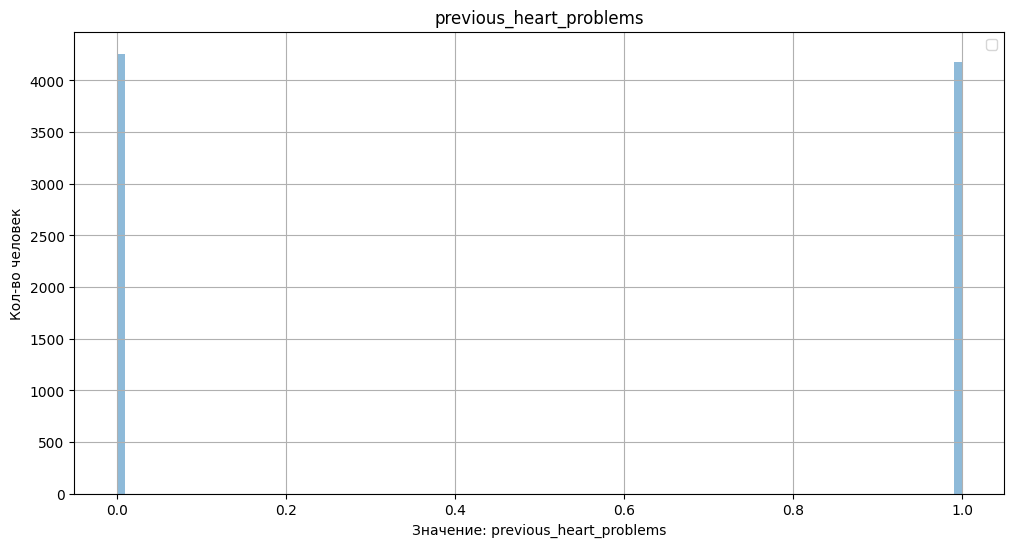

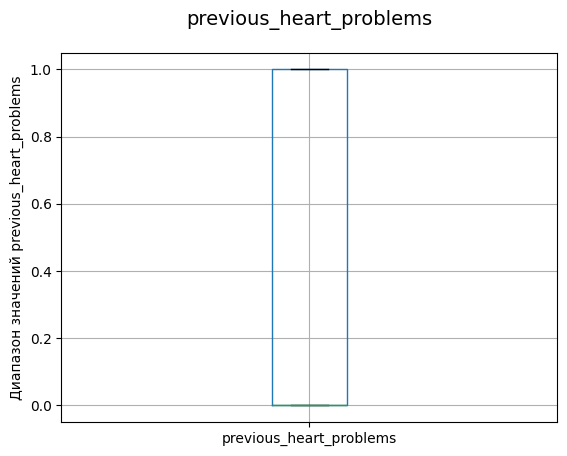

-----------------------------------------------------------
Распределение числовой величины: medication_use
count    8442.000000
mean        0.501185
std         0.500028
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: medication_use, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


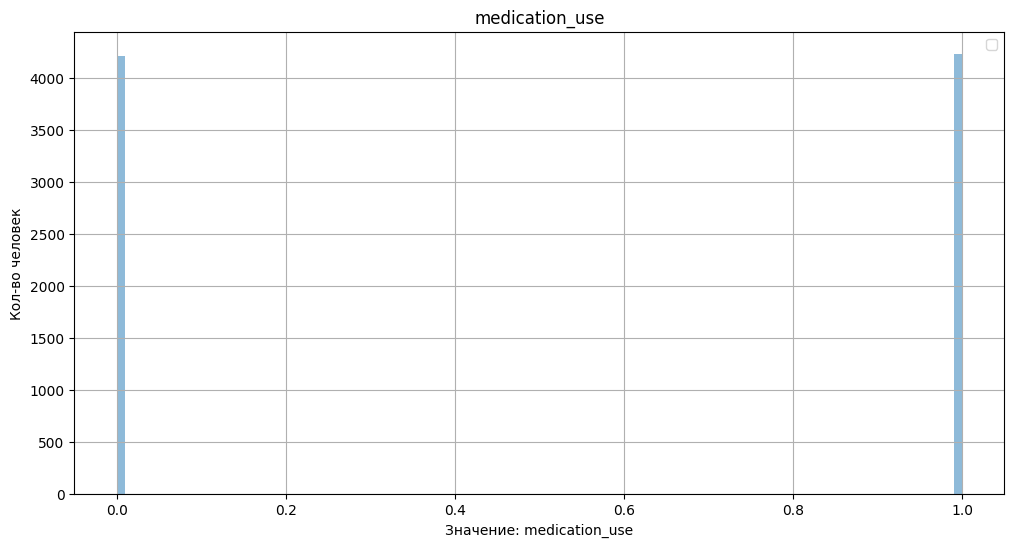

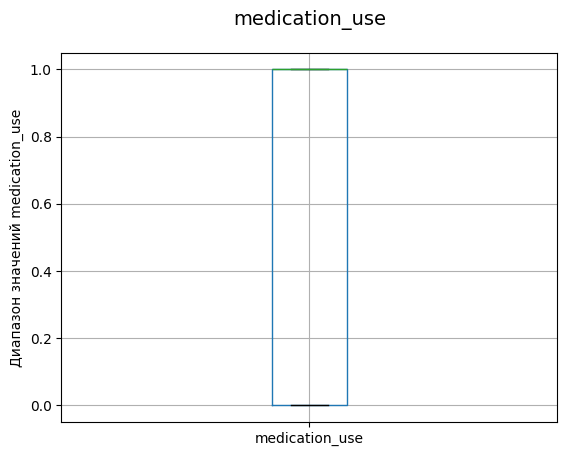

-----------------------------------------------------------
Распределение числовой величины: stress_level
count    8442.000000
mean        5.493367
std         2.867862
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: stress_level, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


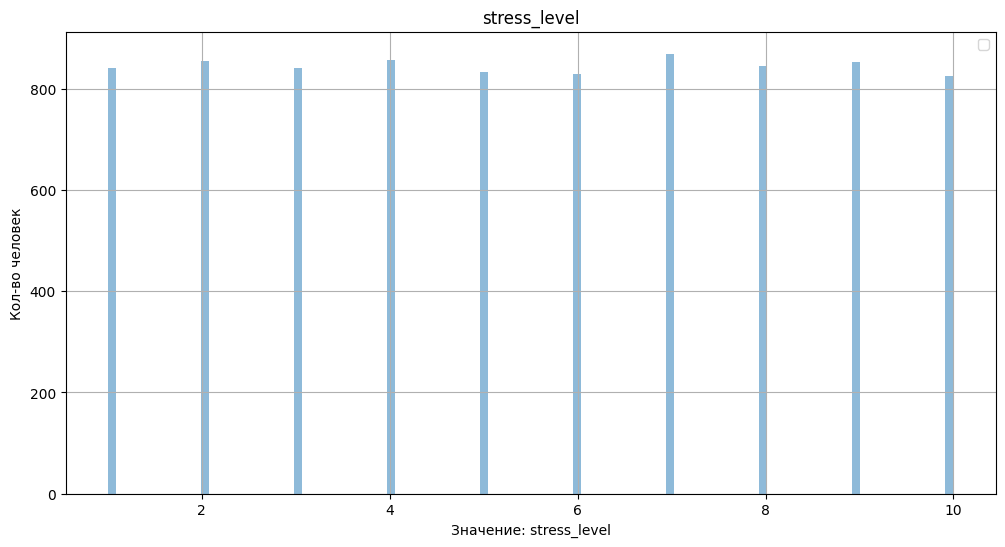

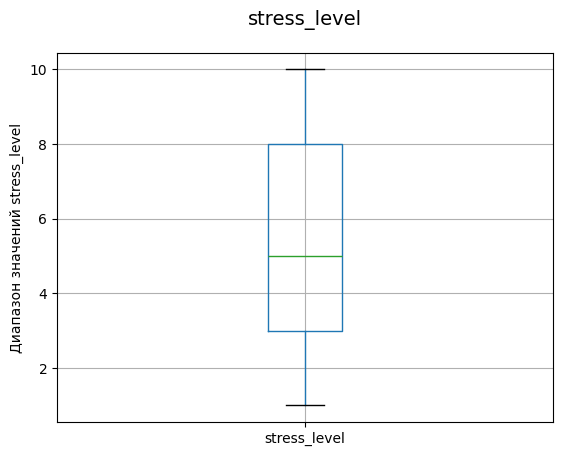

-----------------------------------------------------------
Распределение числовой величины: sedentary_hours_per_day
count    8442.000000
mean        0.499142
std         0.289418
min         0.000000
25%         0.247650
50%         0.492734
75%         0.751047
max         1.000000
Name: sedentary_hours_per_day, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


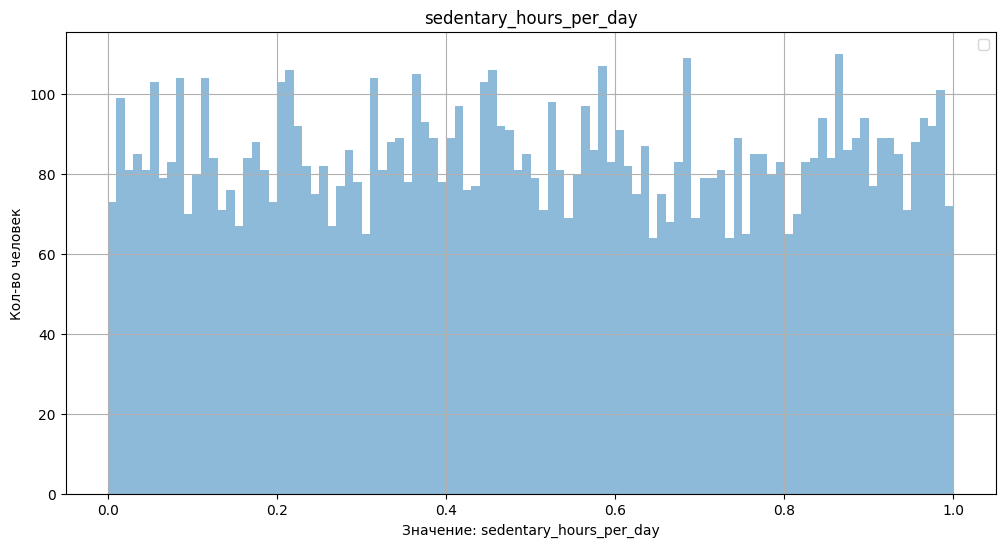

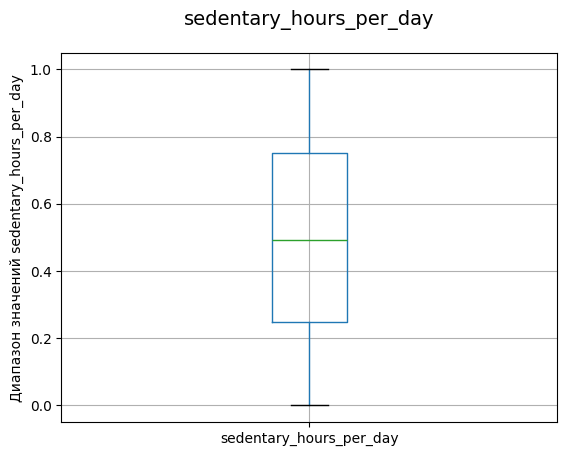

-----------------------------------------------------------
Распределение числовой величины: income
count    8442.000000
mean        0.496089
std         0.288767
min         0.000000
25%         0.244591
50%         0.496052
75%         0.747603
max         1.000000
Name: income, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


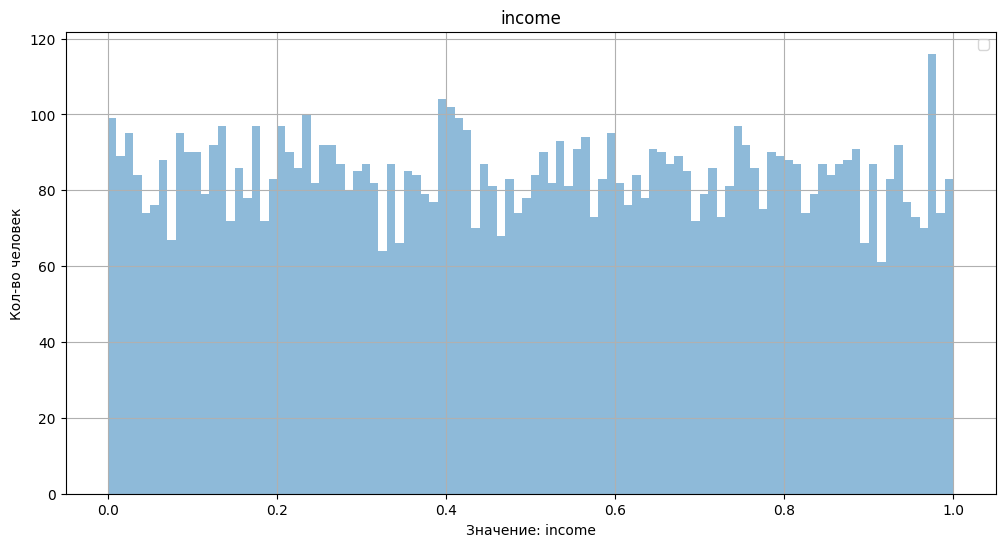

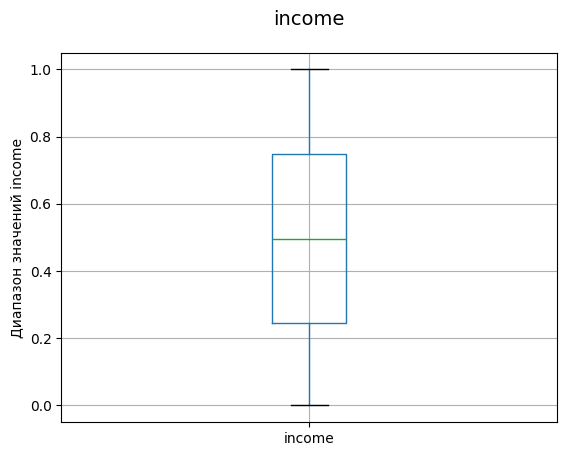

-----------------------------------------------------------
Распределение числовой величины: bmi
count    8442.000000
mean        0.496831
std         0.286599
min         0.000000
25%         0.247935
50%         0.490801
75%         0.744399
max         1.000000
Name: bmi, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


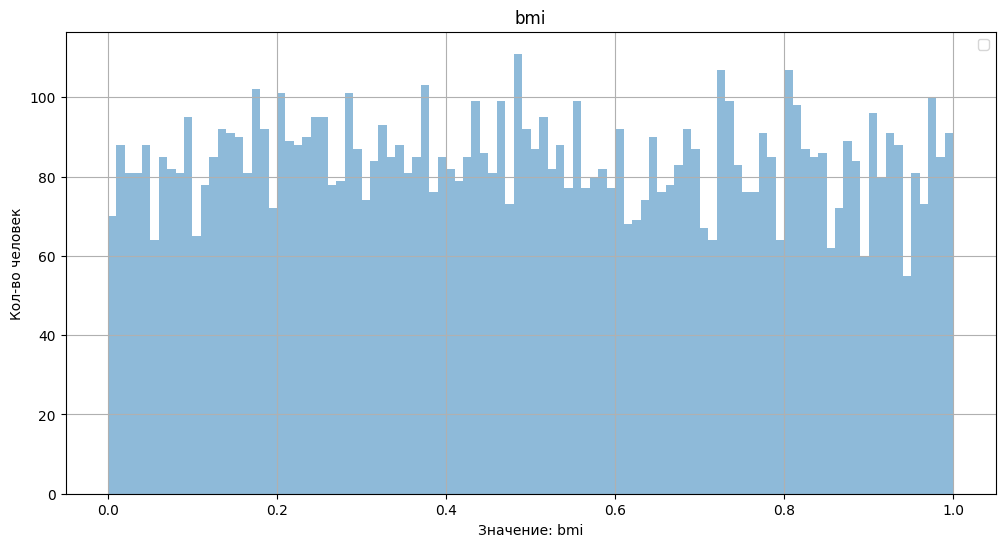

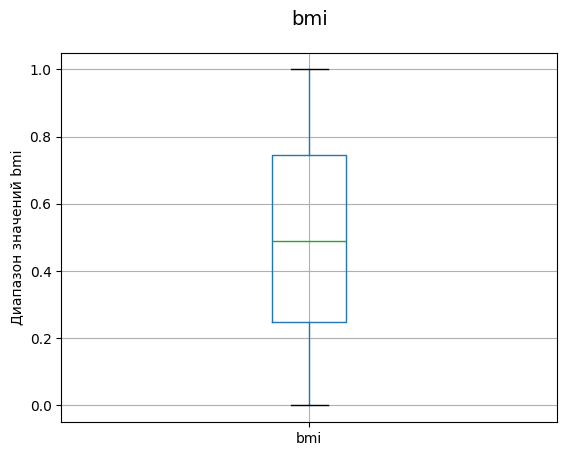

-----------------------------------------------------------
Распределение числовой величины: triglycerides
count    8442.000000
mean        0.505539
std         0.290412
min         0.000000
25%         0.257143
50%         0.507792
75%         0.758442
max         1.000000
Name: triglycerides, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


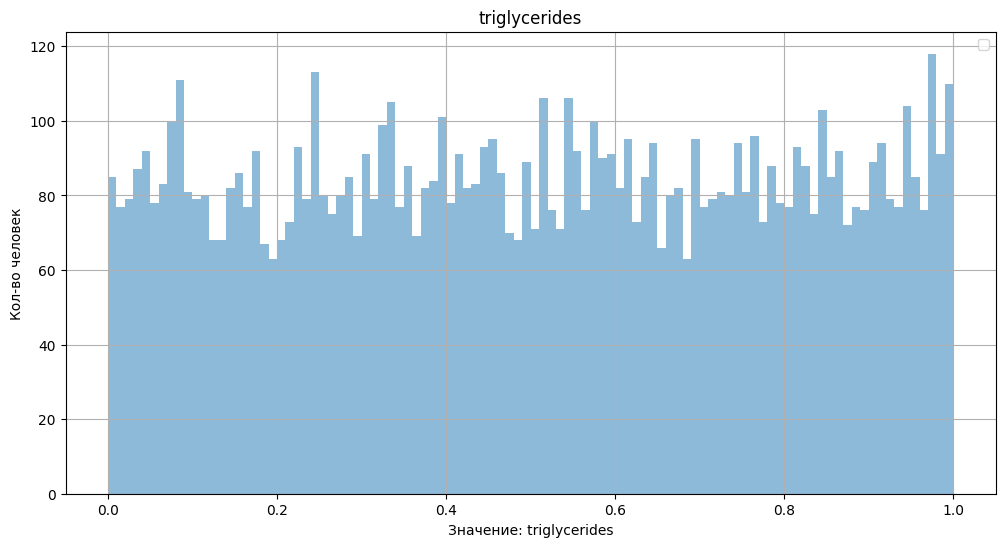

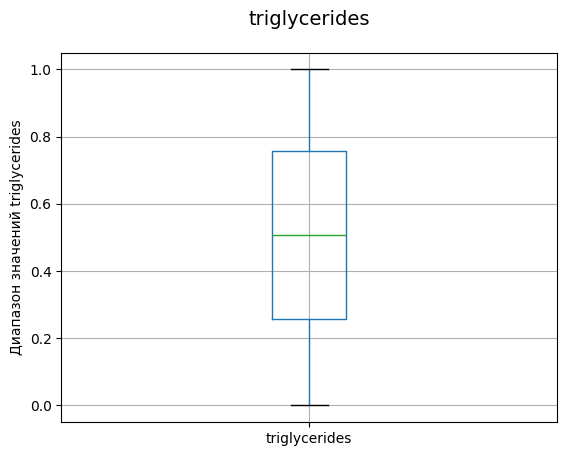

-----------------------------------------------------------
Распределение числовой величины: physical_activity_days_per_week
count    8442.000000
mean        3.508292
std         2.281772
min         0.000000
25%         2.000000
50%         3.000000
75%         6.000000
max         7.000000
Name: physical_activity_days_per_week, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


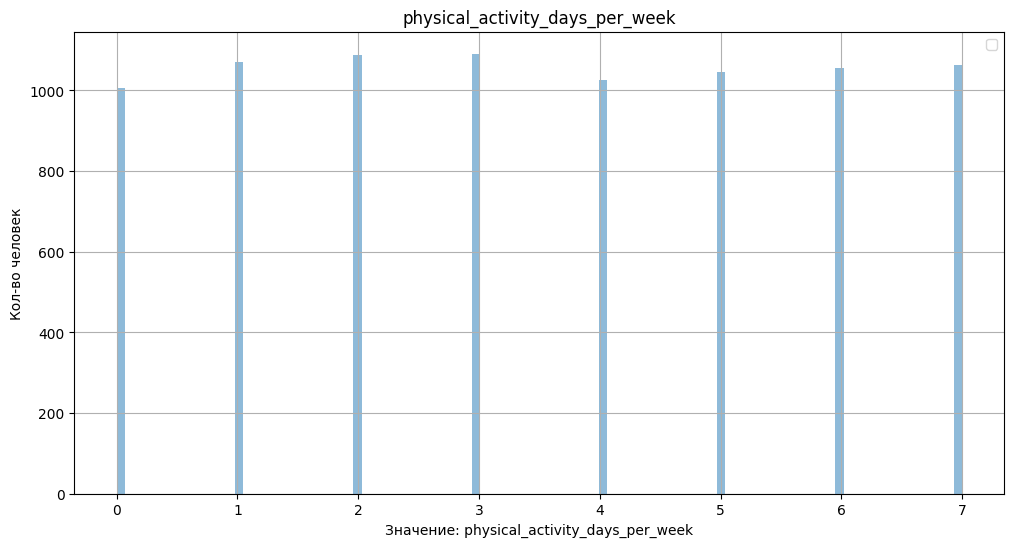

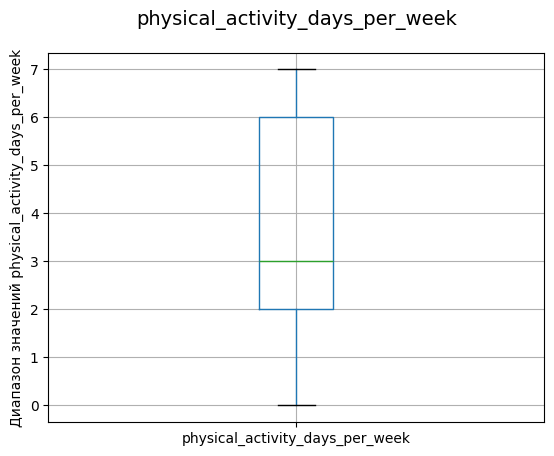

-----------------------------------------------------------
Распределение числовой величины: sleep_hours_per_day
count    8442.000000
mean        0.503712
std         0.332749
min         0.000000
25%         0.166667
50%         0.500000
75%         0.833333
max         1.000000
Name: sleep_hours_per_day, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


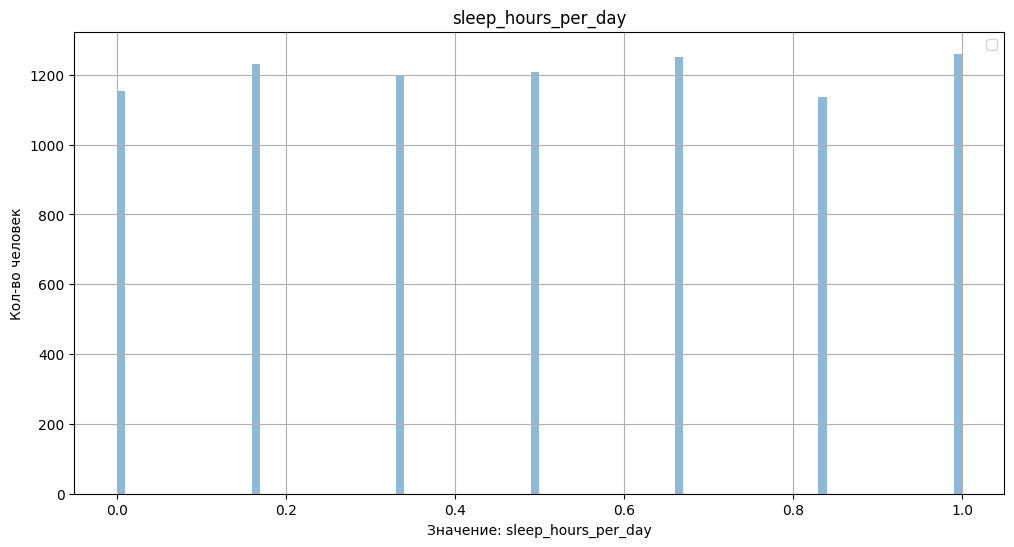

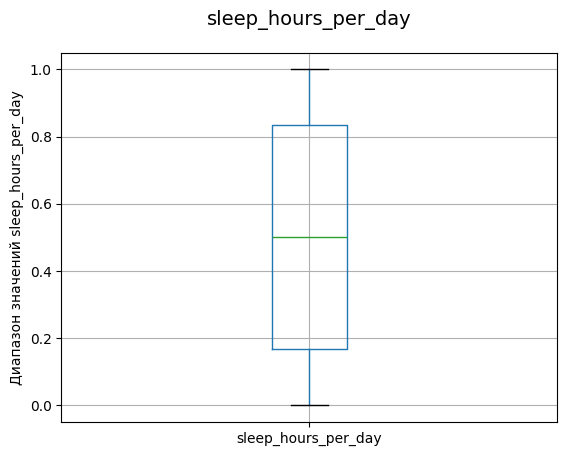

-----------------------------------------------------------
Распределение числовой величины: heart_attack_risk_(binary)
count    8442.000000
mean        0.356906
std         0.479115
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: heart_attack_risk_(binary), dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


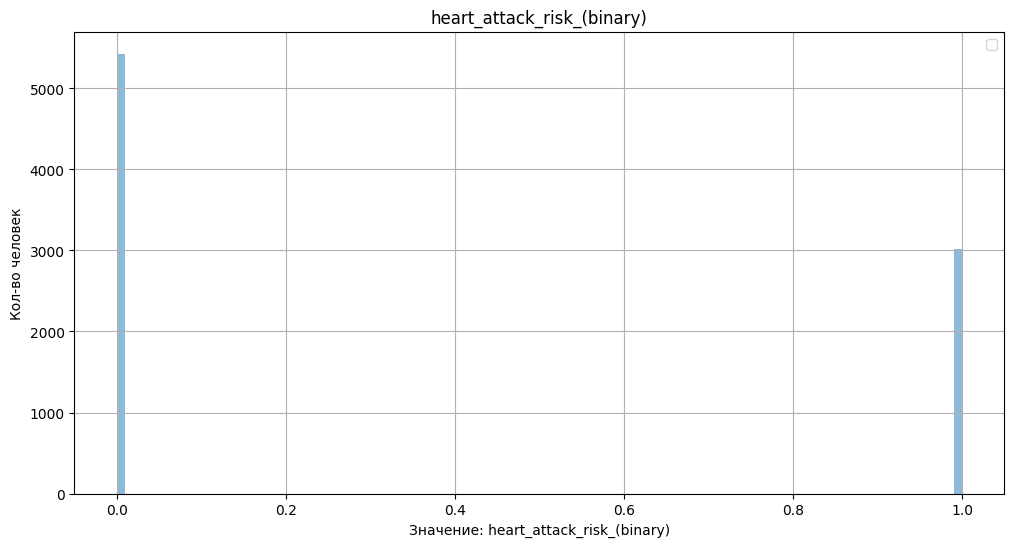

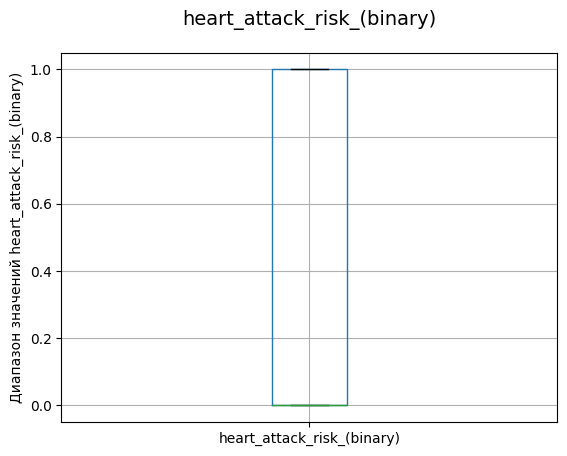

-----------------------------------------------------------
Распределение числовой величины: blood_sugar
count    8442.000000
mean        0.227998
std         0.074623
min         0.000000
25%         0.227018
50%         0.227018
75%         0.227018
max         1.000000
Name: blood_sugar, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


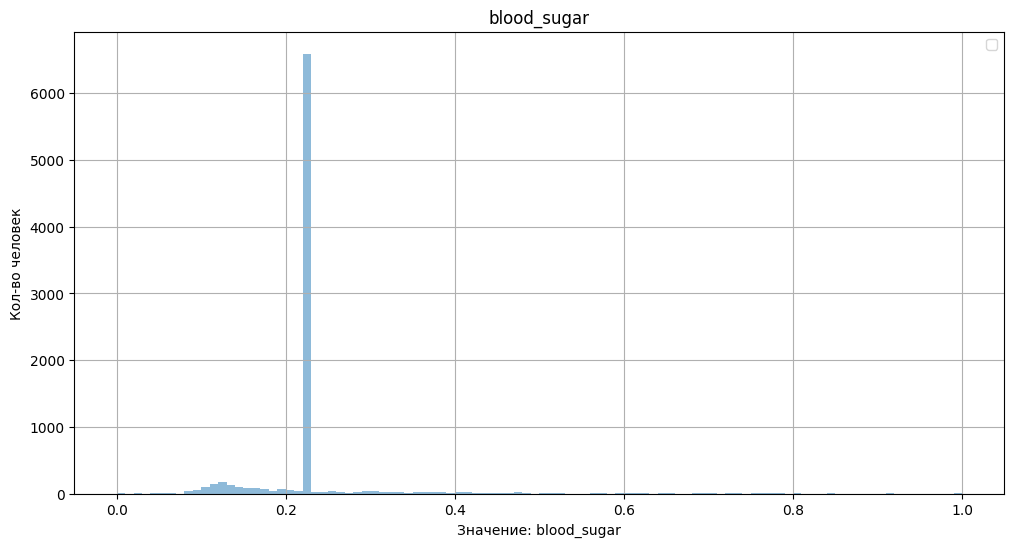

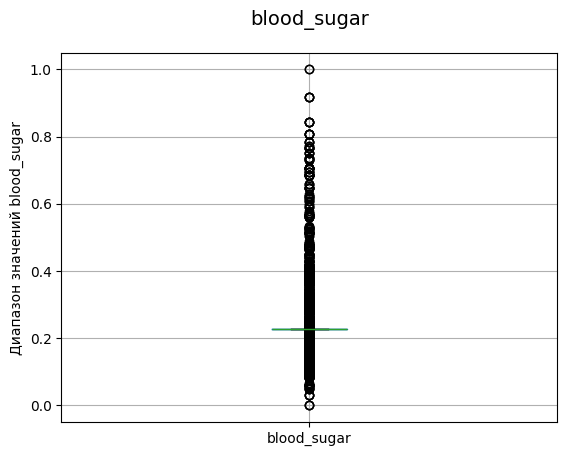

-----------------------------------------------------------
Распределение числовой величины: ck-mb
count    8442.000000
mean        0.047745
std         0.070399
min         0.000000
25%         0.048229
50%         0.048229
75%         0.048229
max         1.000000
Name: ck-mb, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


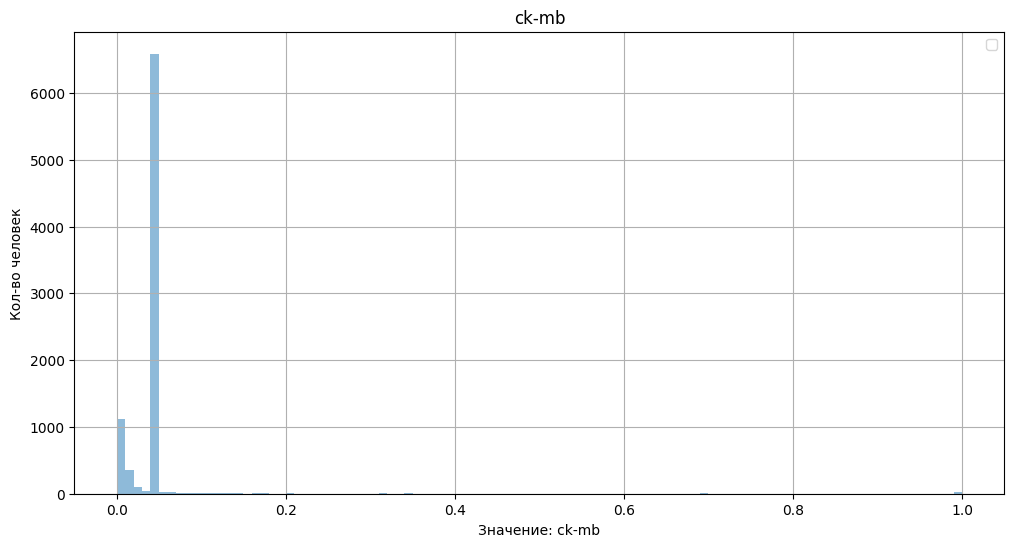

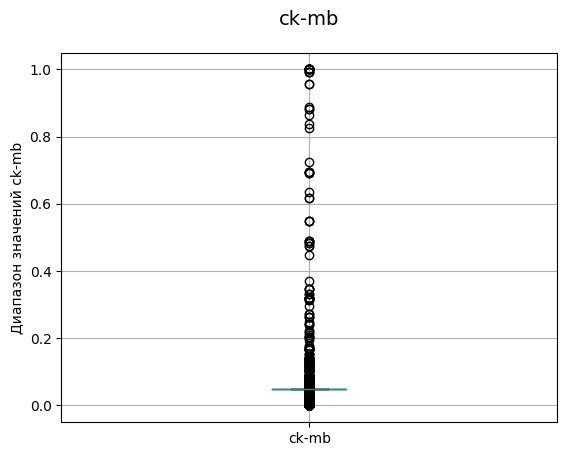

-----------------------------------------------------------
Распределение числовой величины: troponin
count    8442.000000
mean        0.036867
std         0.059284
min         0.000000
25%         0.036512
50%         0.036512
75%         0.036512
max         1.000000
Name: troponin, dtype: float64


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


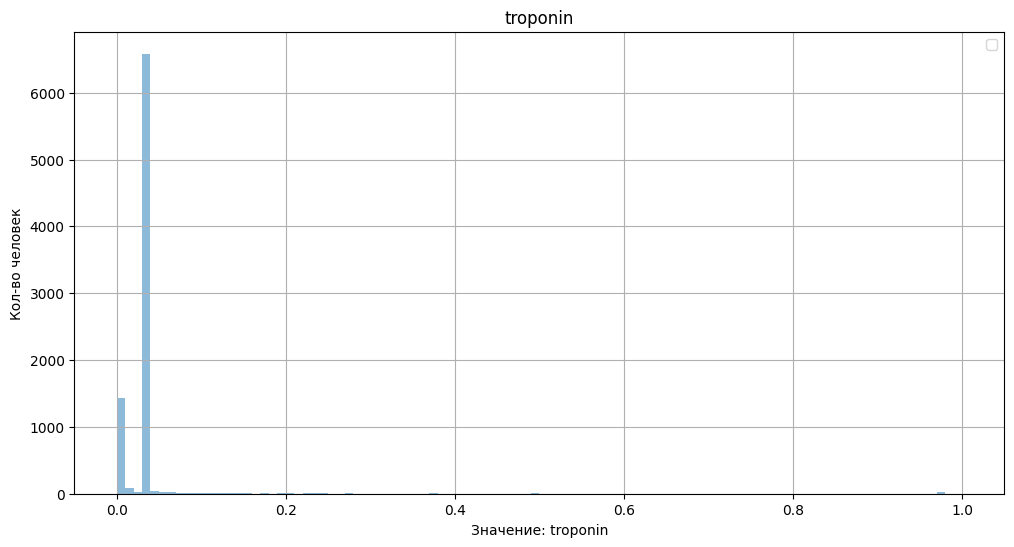

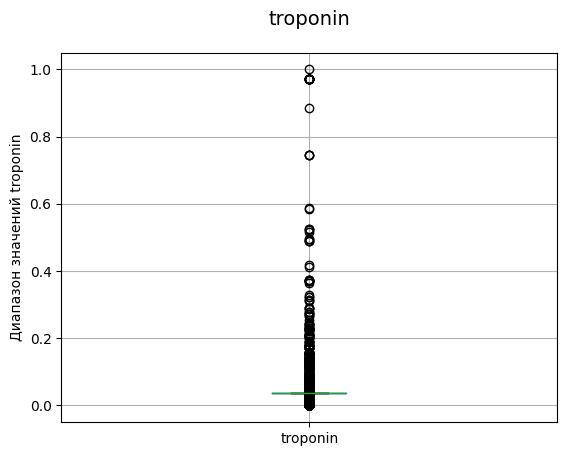

-----------------------------------------------------------
Распределение категориальной величины: gender


/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


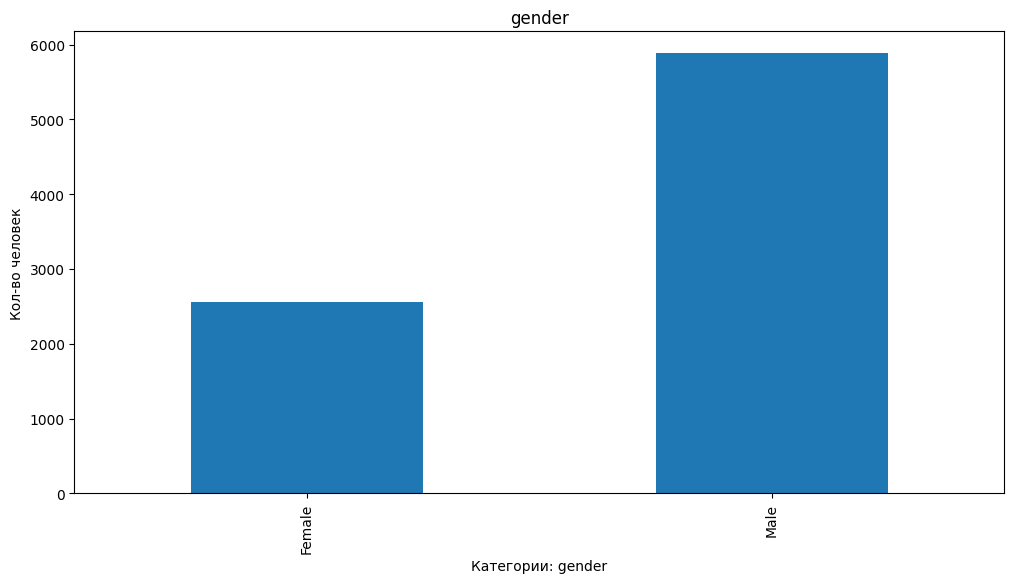

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: systolic_blood_pressure
count    8442.000000
mean        0.451955
std         0.170187
min         0.161290
25%         0.303226
50%         0.451613
75%         0.600000
max         0.741935
Name: systolic_blood_pressure, dtype: float64


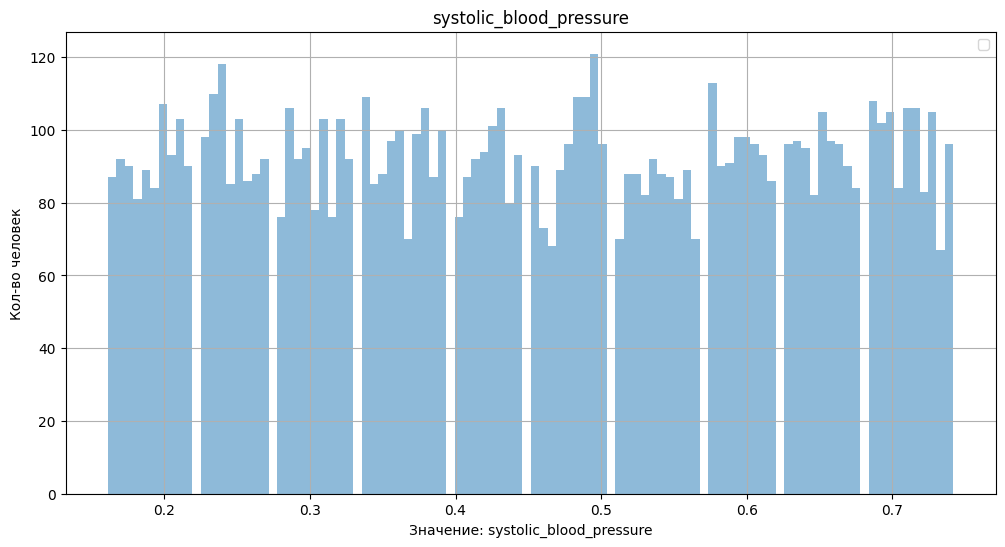

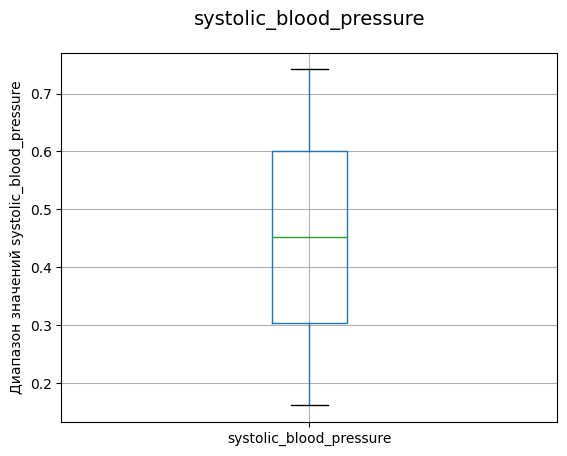

/tmp/ipykernel_4750/1568463818.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
/tmp/ipykernel_4750/1568463818.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-----------------------------------------------------------
Распределение числовой величины: diastolic_blood_pressure
count    8442.000000
mean        0.501672
std         0.170302
min         0.209302
25%         0.348837
50%         0.500000
75%         0.651163
max         0.790698
Name: diastolic_blood_pressure, dtype: float64


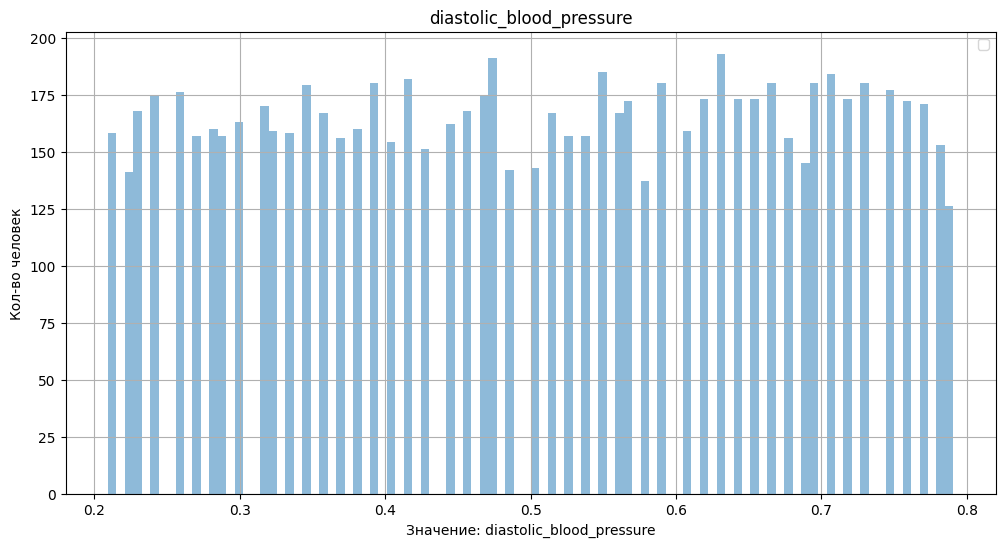

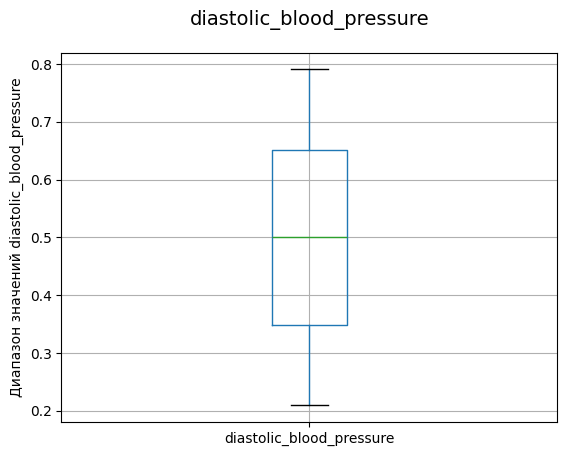

-----------------------------------------------------------
Анализ уникальных идентификаторов: id
Уникальных ID: 8442 из 8442 записей


In [32]:
visualize_stats(df_train_cleaned)

### Проверим корреляцию признаков, форма распределеления которых похожа.

In [33]:
features = df_train_cleaned.columns.tolist()
features

['age',
 'cholesterol',
 'heart_rate',
 'diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'exercise_hours_per_week',
 'diet',
 'previous_heart_problems',
 'medication_use',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'heart_attack_risk_(binary)',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'gender',
 'systolic_blood_pressure',
 'diastolic_blood_pressure',
 'id']

Сформируем категоориальные и числовые признаки по группам

In [34]:
target_feature = 'heart_attack_risk_(binary)'

drop_features = [
    'id',
]

num_features = [
    'age',
    'cholesterol',
    'heart_rate',
    'exercise_hours_per_week',
    'stress_level',
    'sedentary_hours_per_day',
    'income',
    'bmi',
    'triglycerides',
    'blood_sugar',
    'ck-mb',
    'troponin',
    'systolic_blood_pressure',
    'diastolic_blood_pressure'
]

cat_features = [
    'diabetes',
    'family_history',
    'smoking',
    'obesity',
    'alcohol_consumption',
    'previous_heart_problems',
    'medication_use',
    'gender'
]

### Строим матрицу корреляции

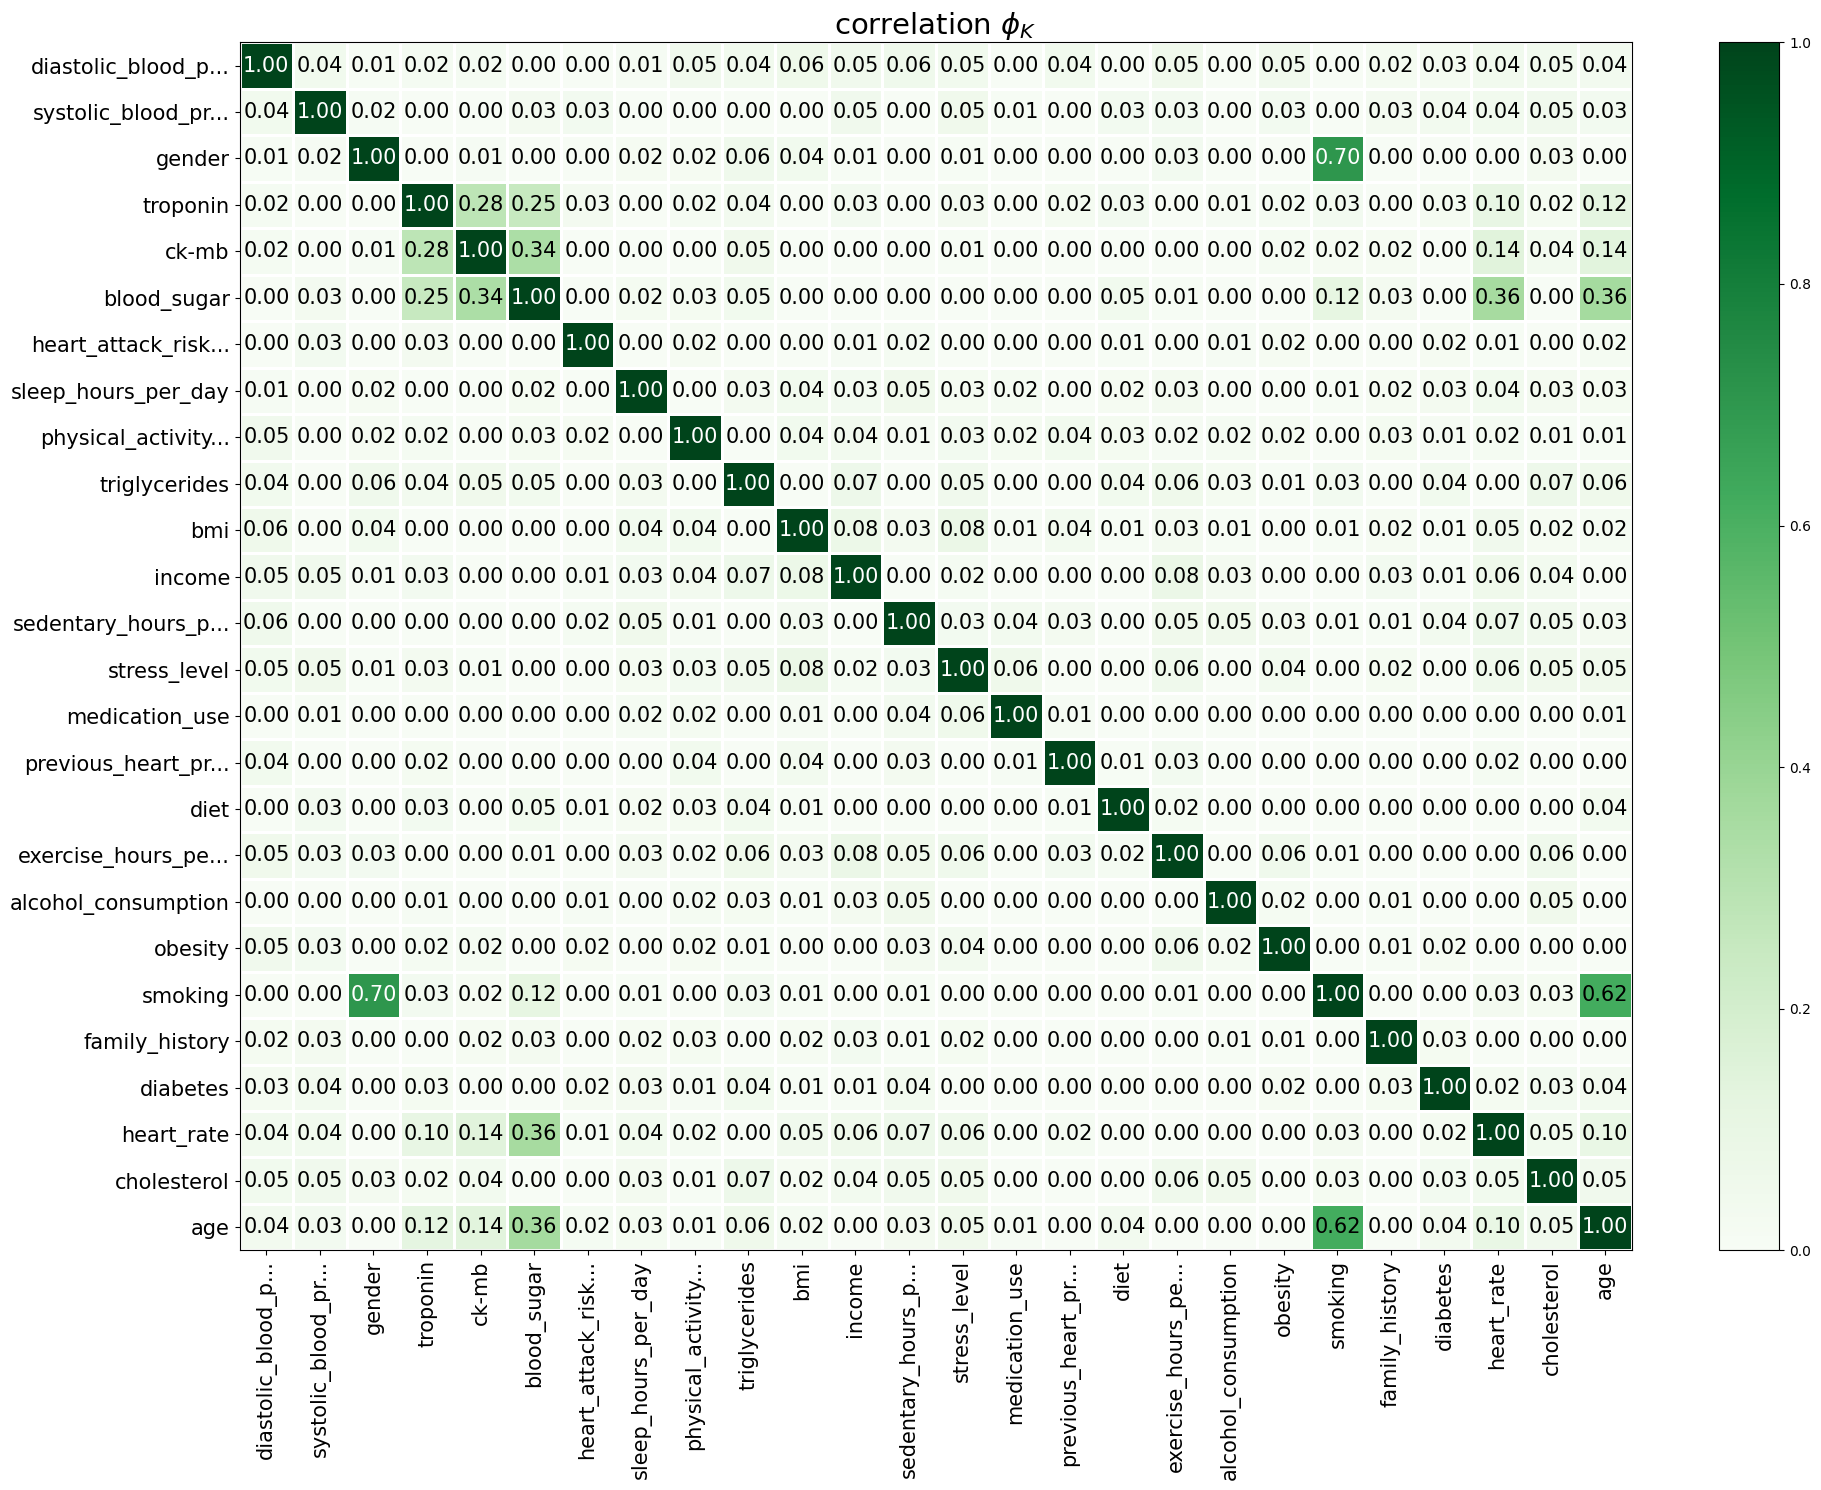

In [35]:
phik_overview = df_train_cleaned\
    .drop(columns=drop_features)\
    .phik_matrix(interval_cols=num_features)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

**Выводы**

 - Большинство признаков подозрительно низко влияют на целевой признак
 - Выделяются пары признаков gender/smoking, smoking/age, blood_sugar/age, blood_sugar/age - рассмотрим подробнее

 Из предыдущего вывода запомнили, что  `blood_sugar`, `ck-mb`, `troponin` есть характерные значения в районе среднего/медианы.

In [36]:
df_train_cleaned

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,...,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk_(binary),blood_sugar,ck-mb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure,id
0,0.359551,0.732143,0.074244,1,1,1,1,1,0.535505,1,...,3.0,0.333333,0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,0.202247,0.325000,0.047663,1,1,0,0,1,0.068690,2,...,3.0,0.833333,0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,0.606742,0.860714,0.055912,1,0,1,1,1,0.944001,2,...,2.0,1.000000,0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,0.730337,0.007143,0.053162,0,0,1,0,1,0.697023,0,...,0.0,0.333333,1,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,0.775281,0.757143,0.021998,0,0,1,0,1,0.412878,1,...,5.0,1.000000,1,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8680,0.359551,0.357143,0.040330,1,0,1,1,1,0.926662,2,...,0.0,0.166667,0,0.136364,0.006771,0.088261,Male,0.632258,0.511628,5734
8681,0.516854,0.832143,0.036664,1,1,1,1,1,0.455572,2,...,6.0,0.833333,0,0.195652,0.008339,0.000777,Male,0.561290,0.511628,5191
8682,0.471910,0.067857,0.023831,1,0,1,0,1,0.076336,2,...,1.0,0.833333,0,0.227018,0.048229,0.036512,Male,0.374194,0.558140,5390
8683,0.595506,0.000000,0.075160,0,1,1,0,1,0.371759,2,...,4.0,0.500000,0,0.227018,0.048229,0.036512,Male,0.477419,0.744186,860


Для `blood_sugar` относительно большое кол-во значений сосредоточено вокруг ~0.22. Опытным путем найдет точное значение. В первой строке датафрейма (id=2664) имеем значение похожее на целевое, посмотрим на него ближе

In [37]:
rows = df_train_cleaned['id'] == 2664

df_train_cleaned[rows][['blood_sugar', 'ck-mb', 'troponin']]

,blood_sugar,ck-mb,troponin
0,0.227018,0.048229,0.036512


Отфильтруем записи по 0.227018.
Поскольку тип значения float64, то 0.227018 это неполное представление, для фильтра будем искать  разницу полного представления и видимого (0.227018), так что бы разница была относительно мала (менее 0.0001). Найденные значения будем считать целевыми.

In [38]:
rows = (abs(df_train_cleaned['blood_sugar'] - 0.227018) < 0.0001) & (abs(df_train_cleaned['ck-mb'] - 0.048229) < 0.0001) & (abs(df_train_cleaned['troponin'] - 0.036512) < 0.0001)

In [39]:
temp_df = df_train_cleaned[rows]

temp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6551 entries, 0 to 8684
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              6551 non-null   float64
 1   cholesterol                      6551 non-null   float64
 2   heart_rate                       6551 non-null   float64
 3   diabetes                         6551 non-null   int64  
 4   family_history                   6551 non-null   int64  
 5   smoking                          6551 non-null   int64  
 6   obesity                          6551 non-null   int64  
 7   alcohol_consumption              6551 non-null   int64  
 8   exercise_hours_per_week          6551 non-null   float64
 9   diet                             6551 non-null   int64  
 10  previous_heart_problems          6551 non-null   int64  
 11  medication_use                   6551 non-null   int64  
 12  stress_level             

Найдено 6551 записей из 8684.

Отфильтруем подозрительные и посмотрим на распределение значений признаков ближе.

<Axes: >

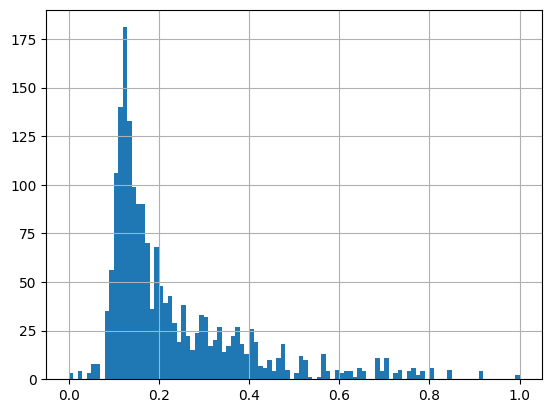

In [40]:
rows = (abs(df_train_cleaned['blood_sugar'] - 0.227018) >= 0.0001)

temp_df = df_train_cleaned[rows]

temp_df['blood_sugar'].hist(bins=100)

<Axes: >

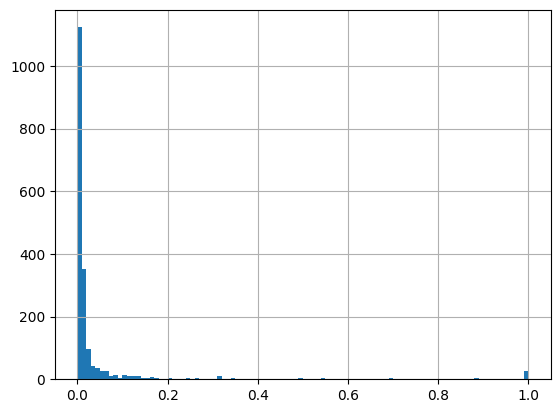

In [41]:
temp_df['ck-mb'].hist(bins=100)

<Axes: >

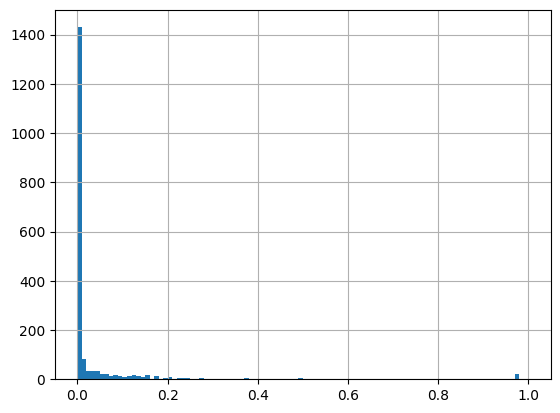

In [42]:
temp_df['troponin'].hist(bins=100)

Распределение `blood_sugar` теперь выглядит как нормальное.

⚠️ **Скорее всего в датасете были пропуски и их заполнили медианой**, проверим это

In [43]:
temp_df['blood_sugar'].mean()

np.float64(0.23139617033462015)

In [44]:
temp_df['ck-mb'].mean()

np.float64(0.04606837477567589)

In [45]:
temp_df['troponin'].mean()

np.float64(0.03809635012029779)

Да, будем считать что пропуски заполнили медианой.

Проверим почему так сильно связано курение и гендер

In [46]:
rows = (df_train_cleaned['gender'] == 'Male') & (df_train_cleaned['smoking'] == 0)

In [47]:
df_train_cleaned[rows]

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,...,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk_(binary),blood_sugar,ck-mb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure,id


In [48]:
df_train_cleaned['smoking'].value_counts()

smoking
1    7622
0     820
Name: count, dtype: int64

⚠️ Оказывается что все мужчины из датасета курят

**Вывод**

 - ⚠️ Для признаков `blood_sugar`, `ck-mb`, `troponin` 6551 записи из 8684 содержали пропуски, пропуски были заменены медианой. Такое подход может негативно отразиться на обучении и предсказании модели.
 - ⚠️ Все мужчины из датасета курят, что скорее всего вызвано какой-то ошибкой.

 Рассмотрим варианты:
  - Удалить записи из датасета там, где пропуски в признаках `blood_sugar`, `ck-mb`, `troponin` были заменены медианой 6551 записи из 8684
  - Удалить сами признаки `blood_sugar`, `ck-mb`, `troponin`
  - Для `smoking == 1 && gender == Male` требуется уточнение со стороны заказчкиа, сами по себе признаки важные, удалить записи или сами признаки на данном этапе считаю нецелесообразным. В результатах предсказаний надо учитывать необъективное значение при условии `smoking == 1 && gender == Male`.

# Проверим влияние признаков на целевой признак

In [49]:
features = df_train_cleaned.columns.tolist()

drop_features = [
    'id'
]

target_feature = 'heart_attack_risk_(binary)'

cat_features = [
    'diabetes',
    'family_history',
    'obesity',
    'alcohol_consumption',
    'diet',
    'gender',
    'smoking',
    'medication_use'
]

num_features = [
    f for f in features if f not in cat_features + [target_feature] + drop_features
]

num_features

['age',
 'cholesterol',
 'heart_rate',
 'exercise_hours_per_week',
 'previous_heart_problems',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

В качестве модели будем использовать RandomForestClassifier

                            feature  importance
8                               bmi    0.080737
6           sedentary_hours_per_day    0.079292
7                            income    0.077821
3           exercise_hours_per_week    0.077280
9                     triglycerides    0.075223
1                       cholesterol    0.074865
15          systolic_blood_pressure    0.066468
2                        heart_rate    0.066213
0                               age    0.066067
16         diastolic_blood_pressure    0.063962
5                      stress_level    0.041021
10  physical_activity_days_per_week    0.038674
11              sleep_hours_per_day    0.035117
13                            ck-mb    0.019047
12                      blood_sugar    0.018791
14                         troponin    0.017349
25                 medication_use_1    0.011799
20            alcohol_consumption_1    0.011167
18                 family_history_1    0.011164
17                       diabetes_1    0

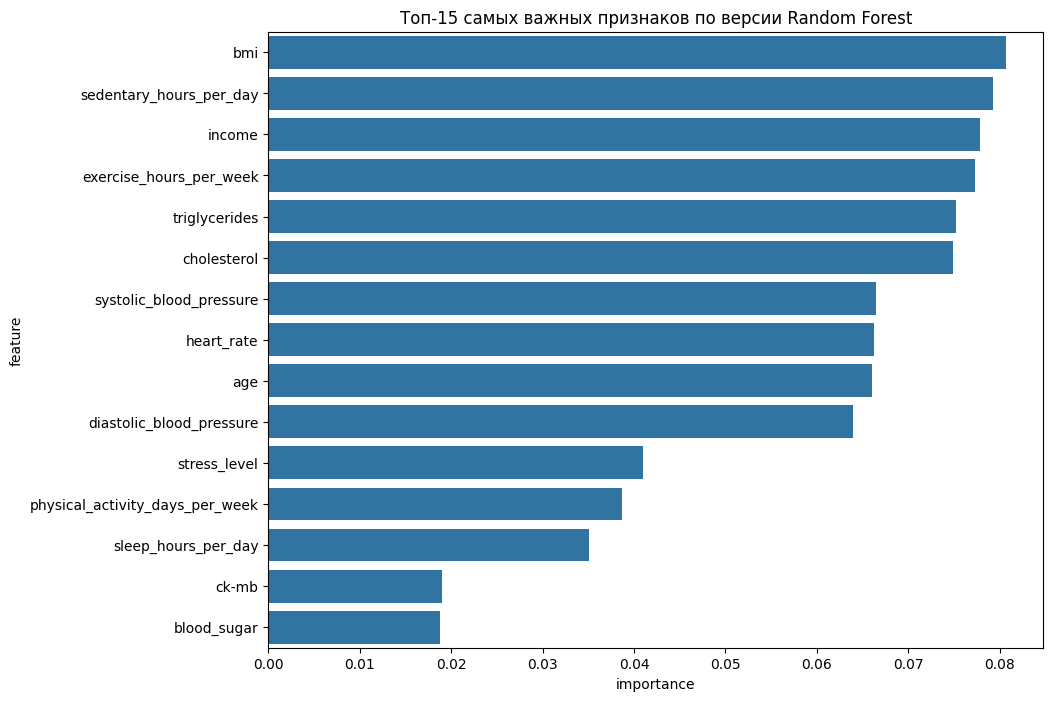

In [50]:
df_encoded = pd.get_dummies(df_train_cleaned, columns=cat_features, drop_first=True)

X = df_encoded.drop([target_feature]+drop_features, axis=1)
y = df_encoded[target_feature]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importances)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances.head(15), x='importance', y='feature')
plt.title('Топ-15 самых важных признаков по версии Random Forest')
plt.show()

In [51]:
# для RandomForest используем TreeExplainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train[:300])

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


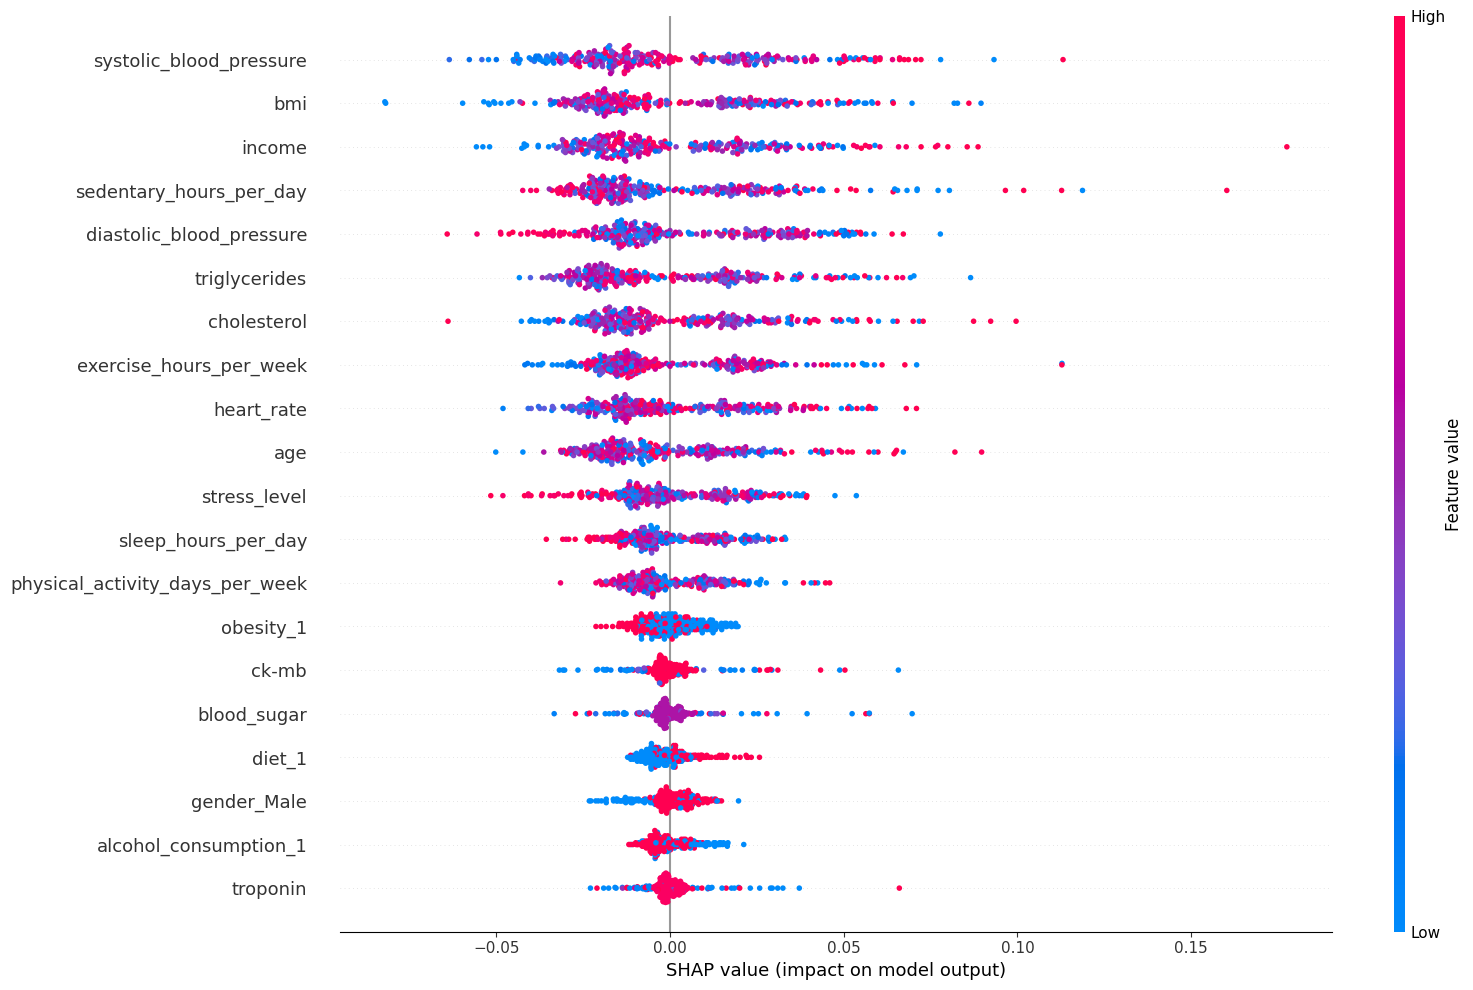

<Figure size 640x480 with 0 Axes>

In [52]:
# Создаем summary plot
shap.summary_plot(shap_values[:,:,1], X_train[:300], feature_names=X_train.columns.tolist(), plot_size=(16, 10))
plt.tight_layout()
plt.show()

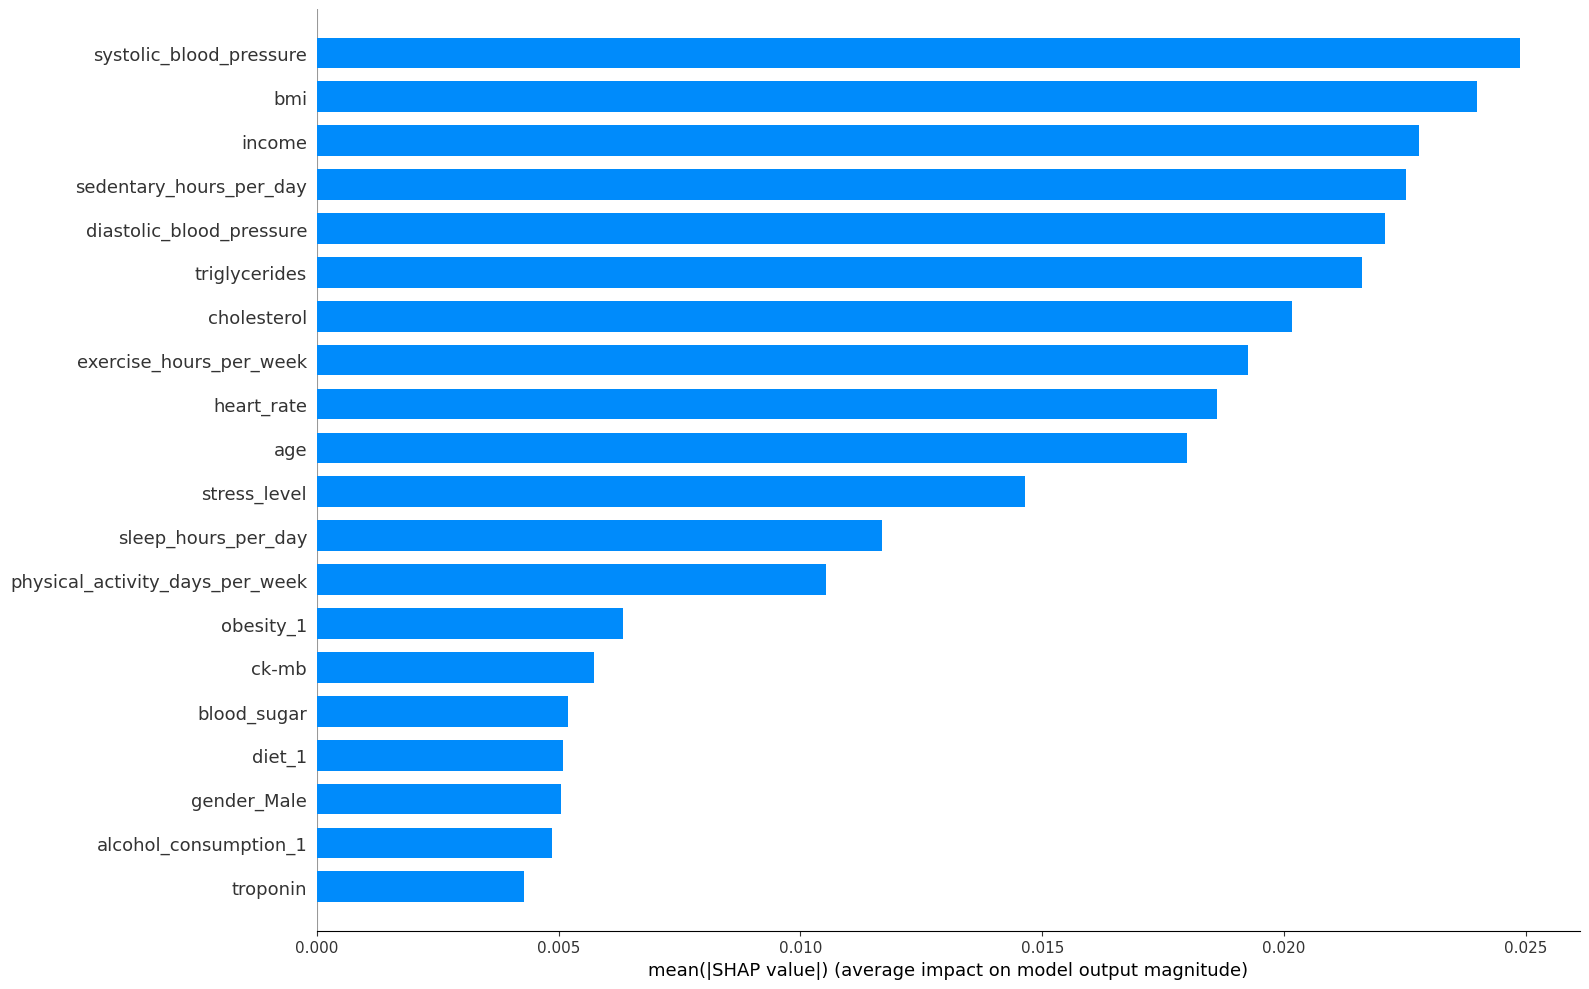

In [53]:
# добавил plot_type='bar'
shap.summary_plot(
    shap_values[:,:,1],
    X_train[:300],
    feature_names=X_train.columns.tolist(),
    plot_size=(16, 10),
    plot_type='bar'
)


--- cholesterol ---
Доля положительных SHAP: 0.08
Доля отрицательных SHAP: 0.92


<Figure size 1000x600 with 0 Axes>

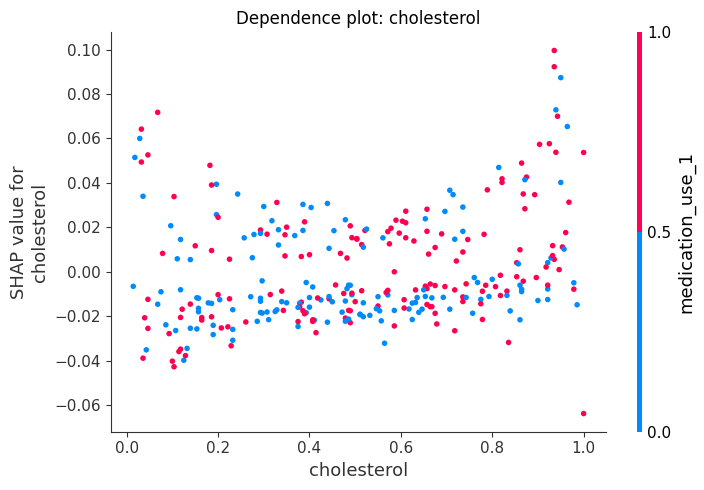


--- heart_rate ---
Доля положительных SHAP: 0.08
Доля отрицательных SHAP: 0.92


<Figure size 1000x600 with 0 Axes>

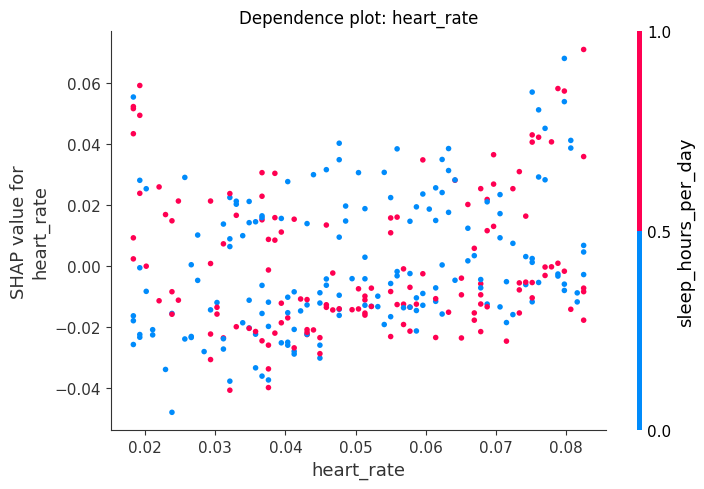


--- exercise_hours_per_week ---
Доля положительных SHAP: 0.15
Доля отрицательных SHAP: 0.85


<Figure size 1000x600 with 0 Axes>

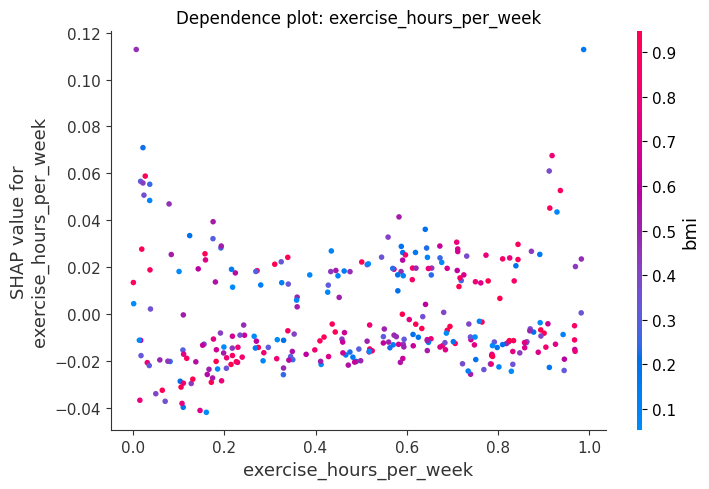


--- previous_heart_problems ---
Доля положительных SHAP: 0.12
Доля отрицательных SHAP: 0.88


<Figure size 1000x600 with 0 Axes>

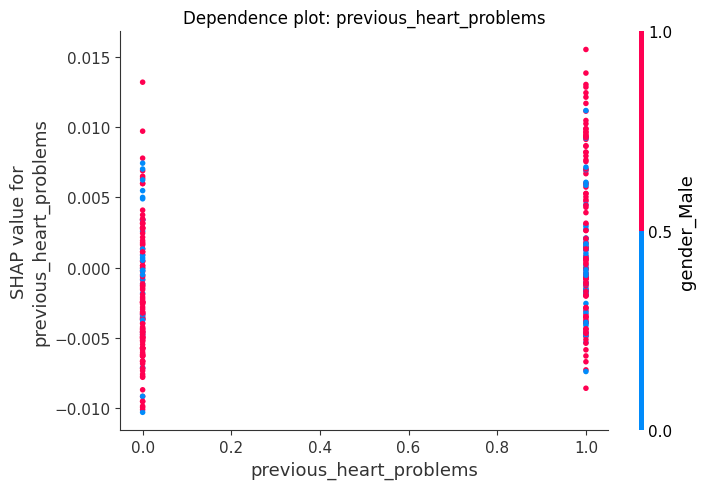


--- stress_level ---
Доля положительных SHAP: 0.92
Доля отрицательных SHAP: 0.08


<Figure size 1000x600 with 0 Axes>

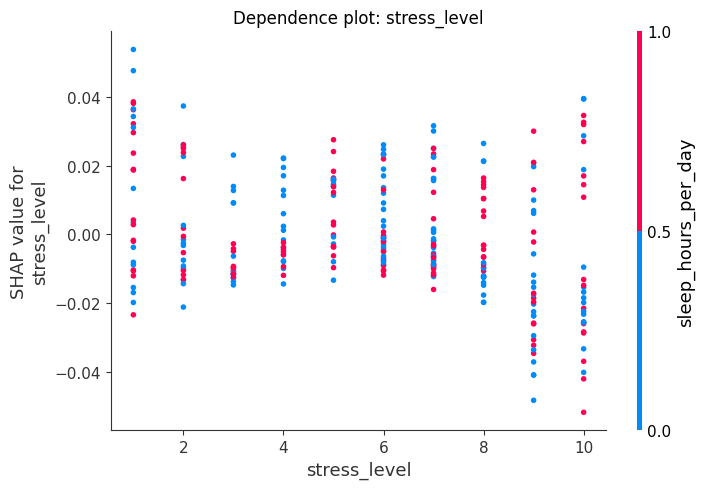


--- sedentary_hours_per_day ---
Доля положительных SHAP: 0.85
Доля отрицательных SHAP: 0.15


<Figure size 1000x600 with 0 Axes>

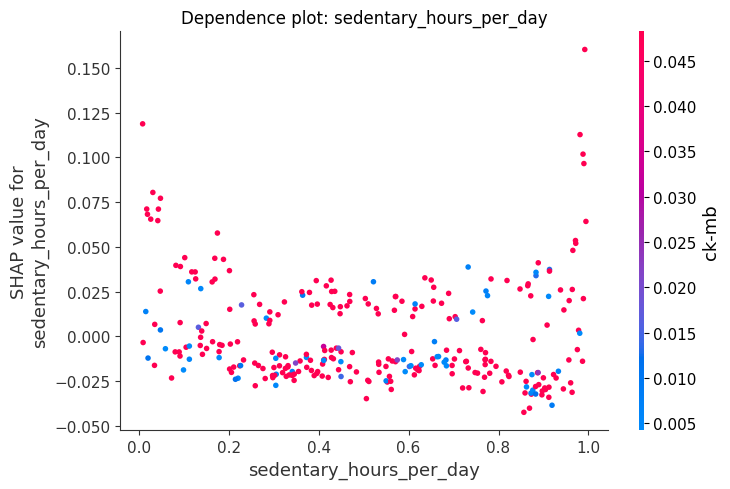


--- income ---
Доля положительных SHAP: 0.19
Доля отрицательных SHAP: 0.81


<Figure size 1000x600 with 0 Axes>

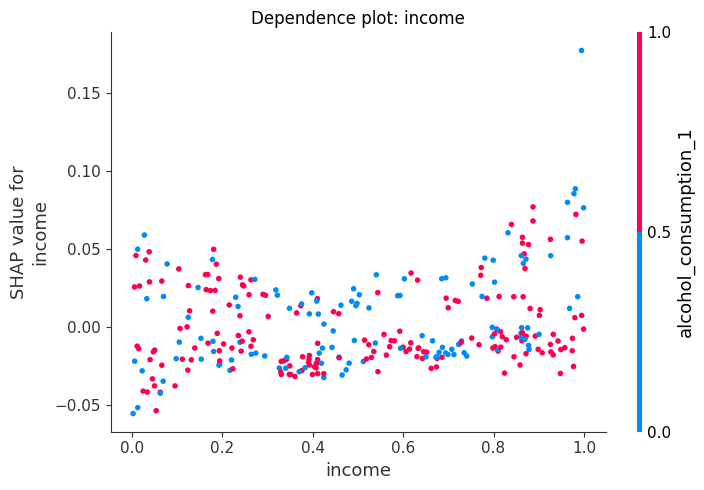


--- bmi ---
Доля положительных SHAP: 0.96
Доля отрицательных SHAP: 0.04


<Figure size 1000x600 with 0 Axes>

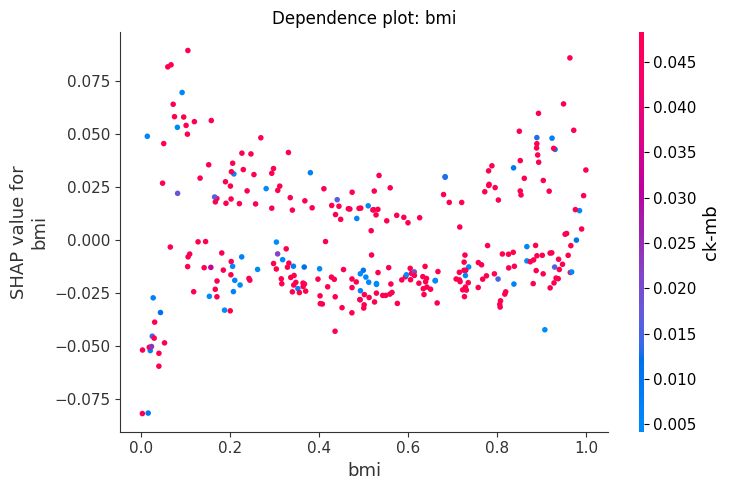


--- physical_activity_days_per_week ---
Доля положительных SHAP: 0.12
Доля отрицательных SHAP: 0.88


<Figure size 1000x600 with 0 Axes>

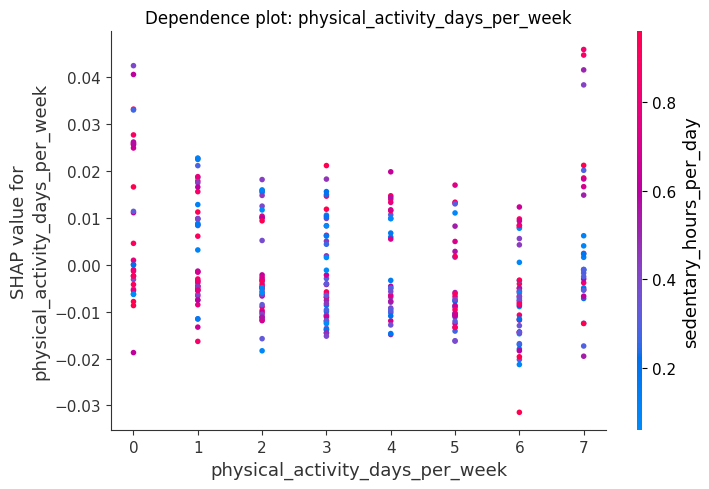


--- sleep_hours_per_day ---
Доля положительных SHAP: 0.96
Доля отрицательных SHAP: 0.04


<Figure size 1000x600 with 0 Axes>

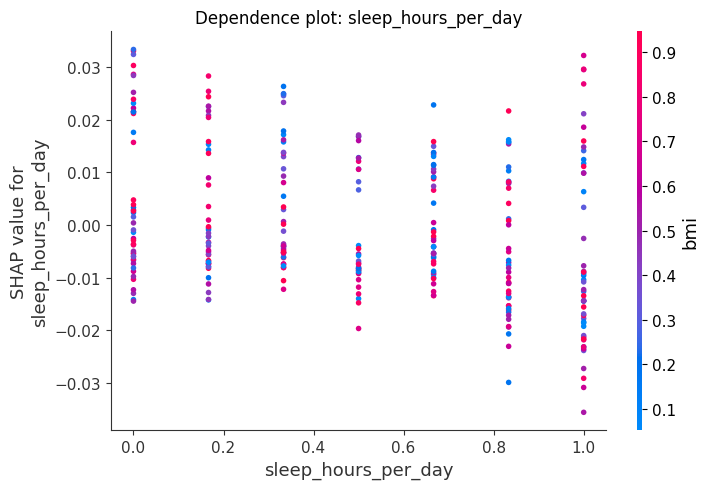


--- blood_sugar ---
Доля положительных SHAP: 0.19
Доля отрицательных SHAP: 0.81


<Figure size 1000x600 with 0 Axes>

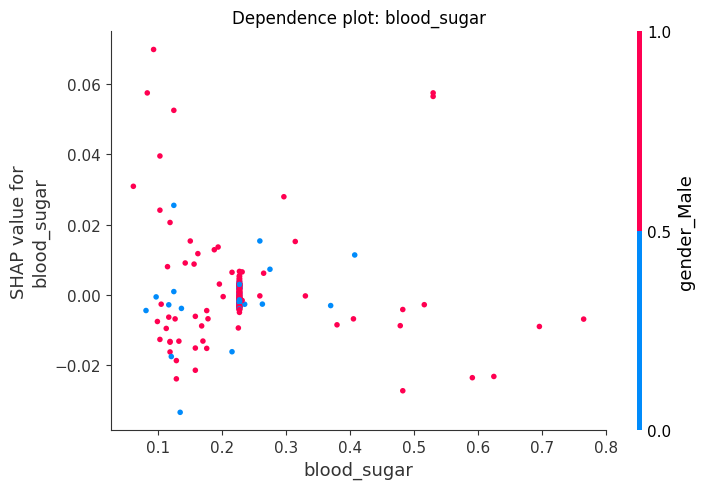


--- ck-mb ---
Доля положительных SHAP: 1.00
Доля отрицательных SHAP: 0.00


<Figure size 1000x600 with 0 Axes>

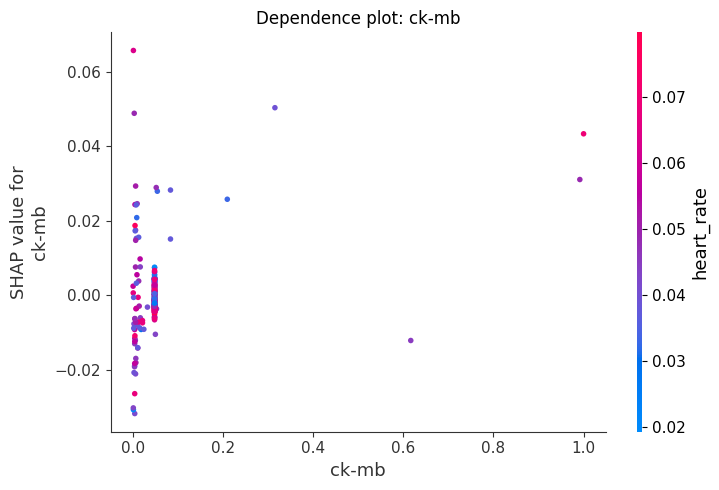


--- troponin ---
Доля положительных SHAP: 0.08
Доля отрицательных SHAP: 0.92


<Figure size 1000x600 with 0 Axes>

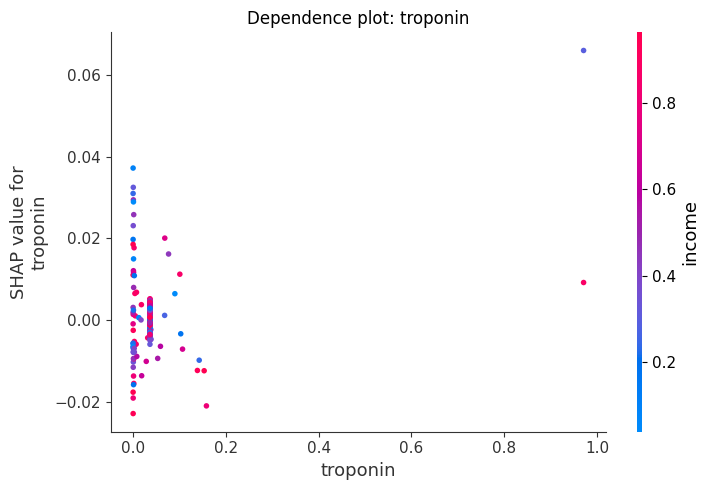


--- systolic_blood_pressure ---
Доля положительных SHAP: 0.92
Доля отрицательных SHAP: 0.08


<Figure size 1000x600 with 0 Axes>

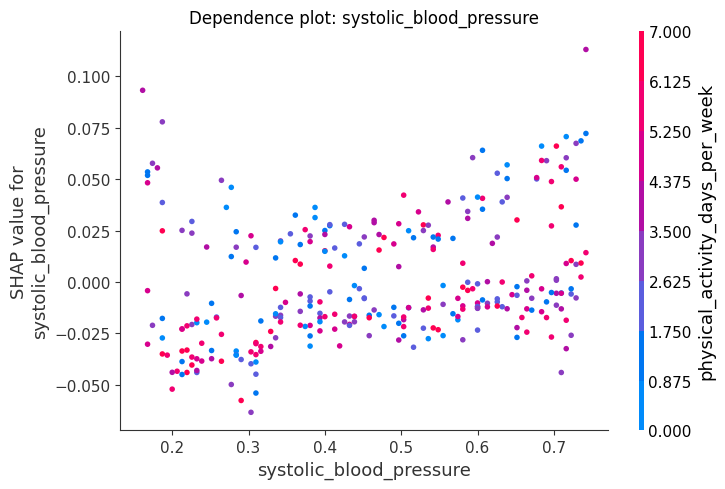


--- diabetes_1 ---
Доля положительных SHAP: 0.12
Доля отрицательных SHAP: 0.88


<Figure size 1000x600 with 0 Axes>

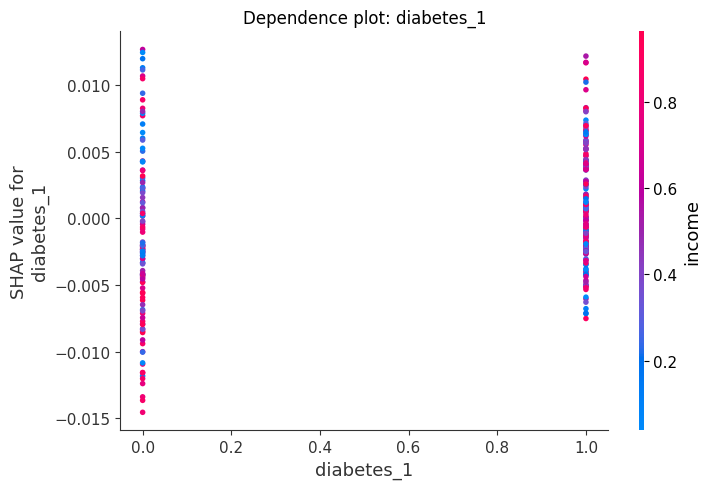


--- family_history_1 ---
Доля положительных SHAP: 0.15
Доля отрицательных SHAP: 0.85


<Figure size 1000x600 with 0 Axes>

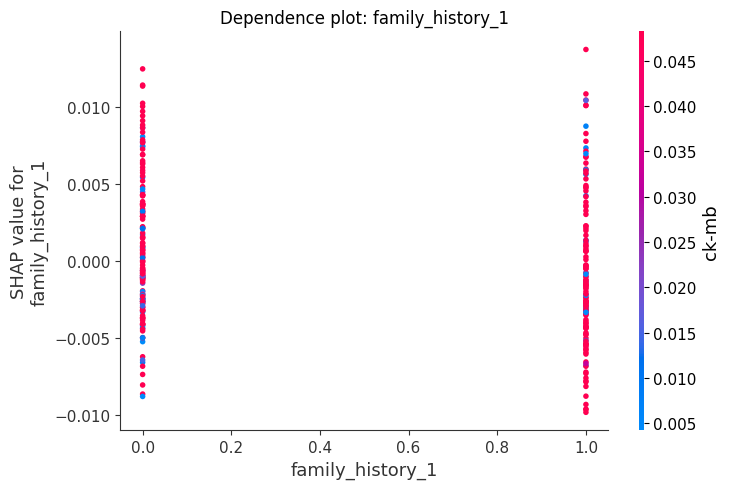


--- obesity_1 ---
Доля положительных SHAP: 1.00
Доля отрицательных SHAP: 0.00


<Figure size 1000x600 with 0 Axes>

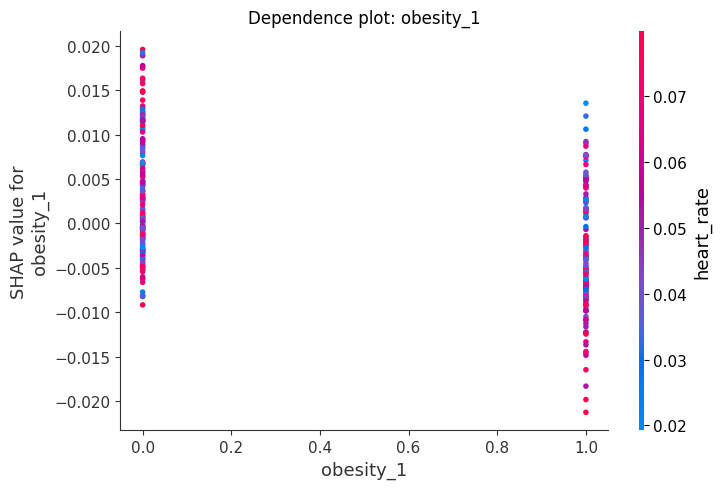


--- alcohol_consumption_1 ---
Доля положительных SHAP: 0.88
Доля отрицательных SHAP: 0.12


<Figure size 1000x600 with 0 Axes>

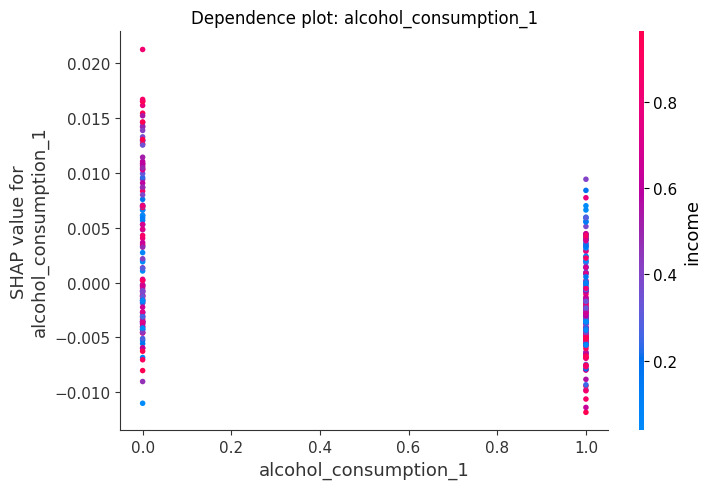


--- diet_1 ---
Доля положительных SHAP: 0.96
Доля отрицательных SHAP: 0.04


<Figure size 1000x600 with 0 Axes>

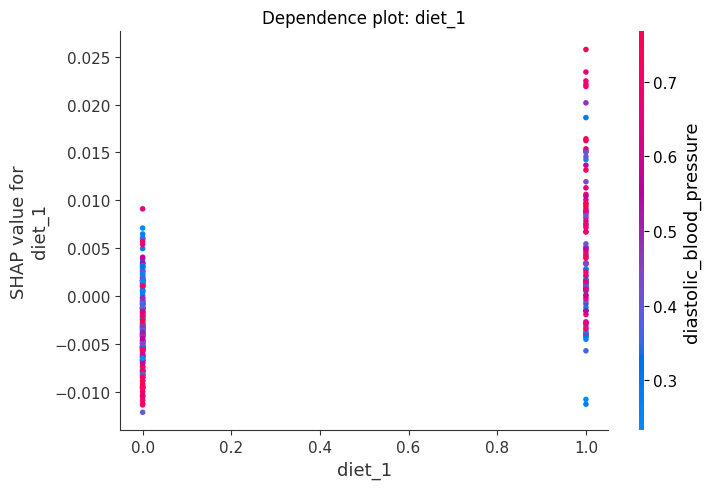


--- diet_2 ---
Доля положительных SHAP: 1.00
Доля отрицательных SHAP: 0.00


<Figure size 1000x600 with 0 Axes>

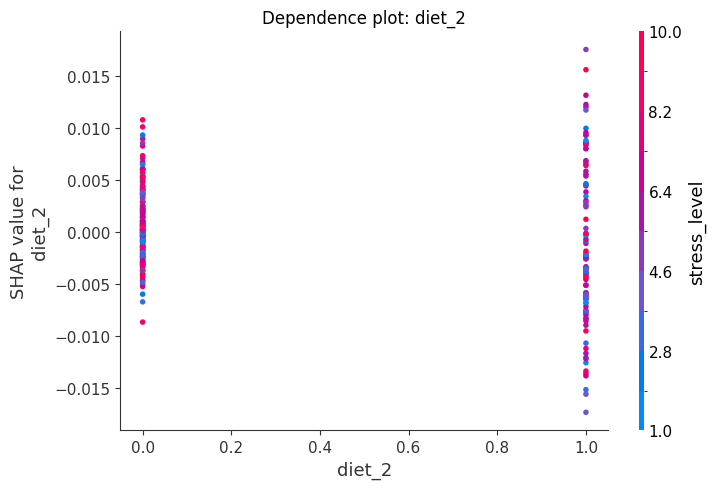


--- gender_Male ---
Доля положительных SHAP: 1.00
Доля отрицательных SHAP: 0.00


<Figure size 1000x600 with 0 Axes>

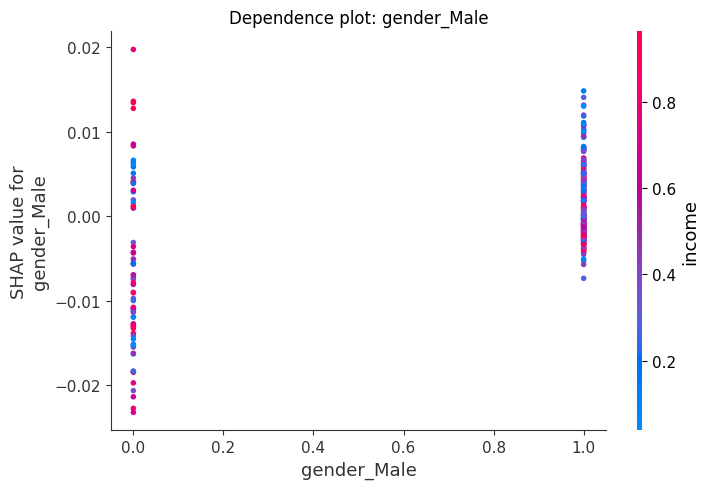


--- smoking_1 ---
Доля положительных SHAP: 0.04
Доля отрицательных SHAP: 0.96


<Figure size 1000x600 with 0 Axes>

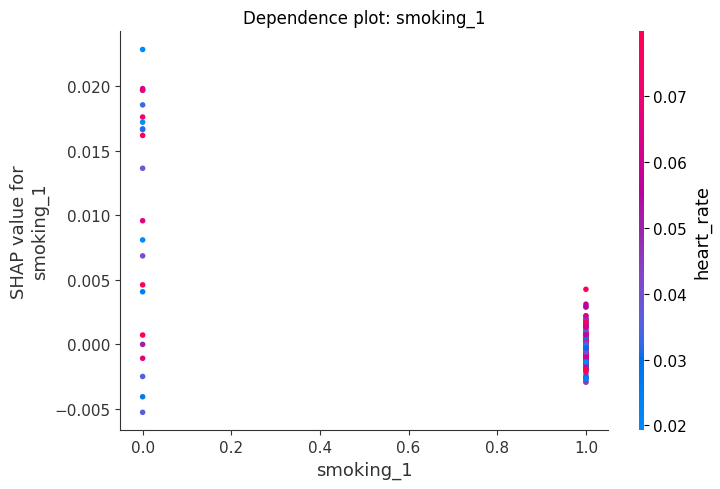


--- medication_use_1 ---
Доля положительных SHAP: 0.88
Доля отрицательных SHAP: 0.12


<Figure size 1000x600 with 0 Axes>

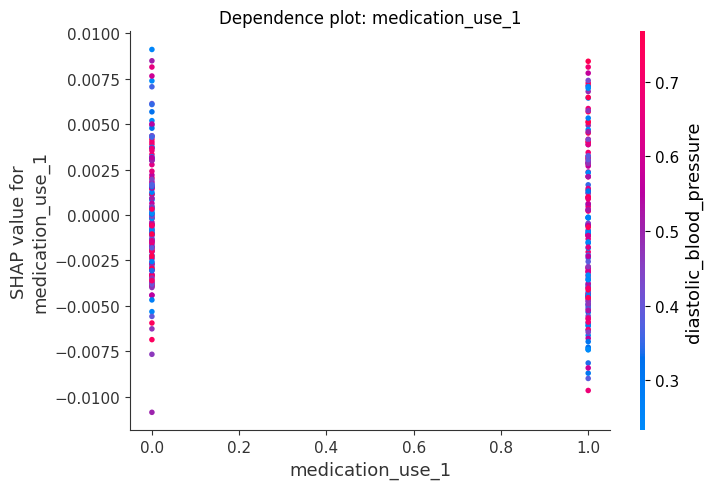

In [54]:
# Проанализируем такие признаки более детально
problematic_features = []  # соберем признаки с таким поведением

for i, feature in enumerate(X_train.columns):
    # Проверим распределение SHAP значений
    shap_for_feature = shap_values[:,:,1][i]

    # Если >80% значений по одну сторону от нуля
    if np.mean(shap_for_feature > 0) > 0.8 or np.mean(shap_for_feature < 0) > 0.8:
        print(f"\n--- {feature} ---")
        print(f"Доля положительных SHAP: {np.mean(shap_for_feature > 0):.2f}")
        print(f"Доля отрицательных SHAP: {np.mean(shap_for_feature < 0):.2f}")

        # Создаем dependence plot для анализа
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(feature, shap_values[:,:,1], X_train[:300],
                           feature_names=X_train.columns, show=False)
        plt.title(f'Dependence plot: {feature}')
        plt.tight_layout()
        plt.show()

        problematic_features.append(feature)

По характеру SHAP распределений можно отметить нелинейную зависимость:
 - слева и справа от нуля есть равномерные группы (признак одинаково влияет как на положительное, так и на отрицательное предсказание)
 - группы содержат одинаковое кол-во красных (высокие значения) и синих (низкие значения) элементов

# Пробуем более сложную модель

In [55]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [56]:
# для RandomForest используем TreeExplainer
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_train[:300])

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [57]:
shap_values

array([[-6.74536097e-03, -1.36000651e-02,  1.43701254e-02, ...,
         7.26599022e-03, -2.45106111e-04,  4.04962496e-05],
       [ 3.08215426e-02,  2.17652357e-03,  1.98828741e-03, ...,
        -2.32621394e-02, -2.45106111e-04, -2.02481248e-05],
       [-6.68536209e-02, -1.81615110e-02,  1.39288043e-02, ...,
         1.00153446e-02, -2.45106111e-04,  4.04962496e-05],
       ...,
       [-2.00876826e-02,  7.23833022e-04, -2.37730148e-02, ...,
         2.12033060e-02, -2.45106111e-04,  4.04962496e-05],
       [ 1.27259060e-02, -6.94585312e-03,  1.89539607e-02, ...,
         2.41439349e-02, -2.45106111e-04, -9.44912491e-05],
       [-2.76549224e-03, -1.17276376e-02,  1.35315904e-02, ...,
         1.00154438e-02, -2.45106111e-04, -2.02481248e-05]],
      shape=(300, 26))

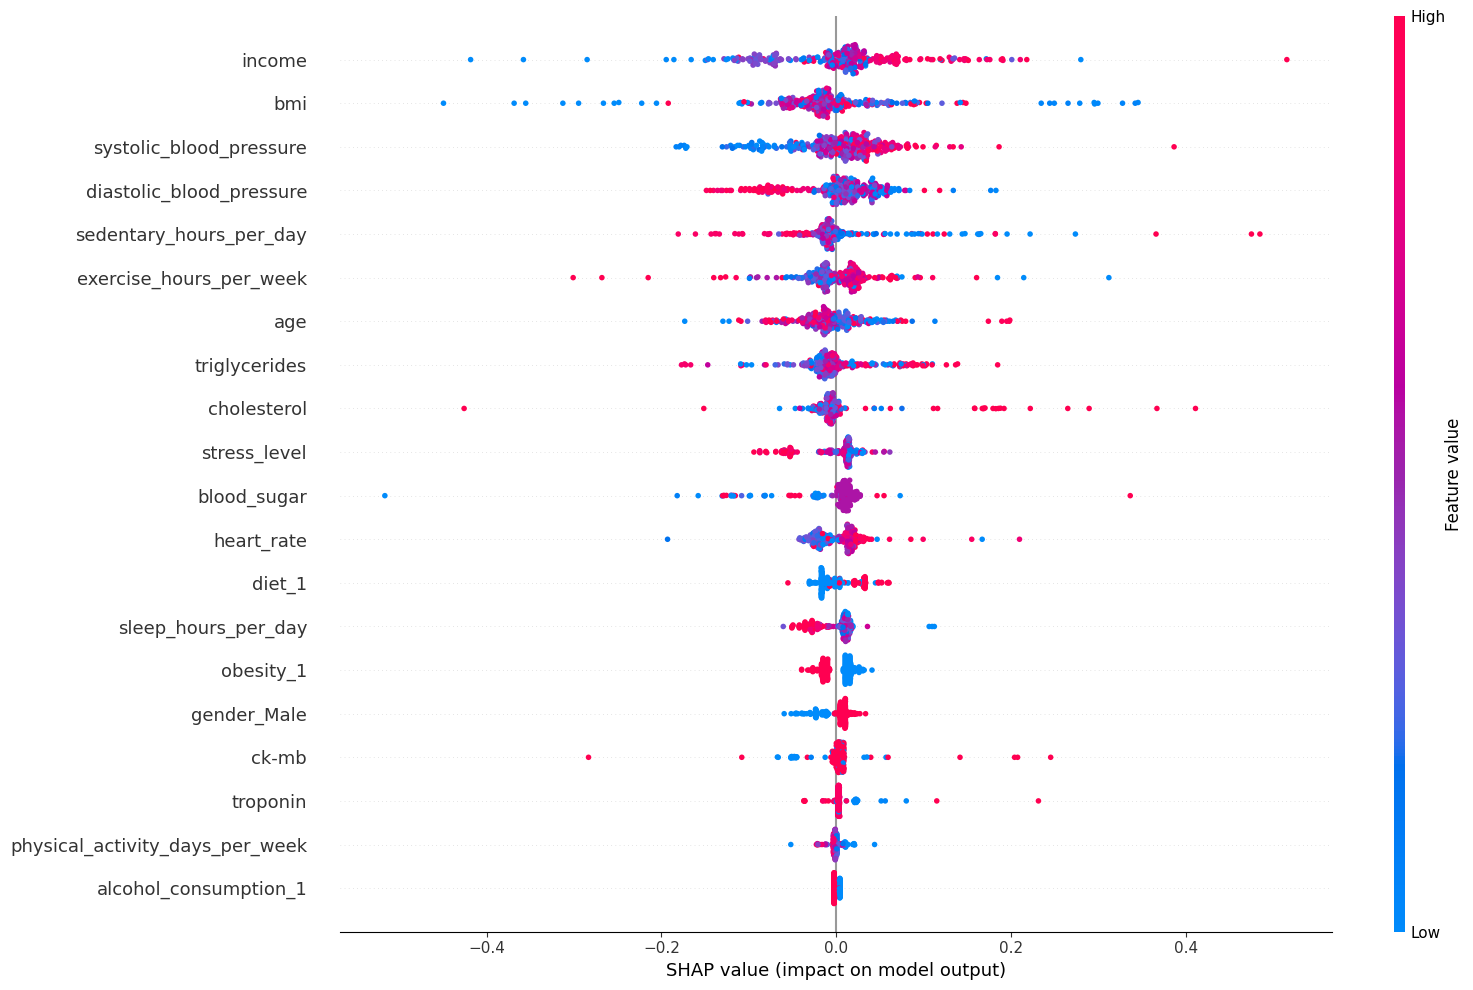

<Figure size 640x480 with 0 Axes>

In [58]:
# Создаем summary plot
shap.summary_plot(shap_values, X_train[:300], feature_names=X_train.columns.tolist(), plot_size=(16, 10))
plt.tight_layout()
plt.show()

**Вывод**

По сравнению с предыдущей моделью картина почти не изменилась. Выделить признаки, которые явно влияют на целевой признак сложно.

## Проверим баланс классов бинарного целевого признака

In [59]:
y.value_counts(normalize=True)

heart_attack_risk_(binary)
0    0.643094
1    0.356906
Name: proportion, dtype: float64

Умеренный дисбаланс классов, метрика roc_auc устойчива к дисбалансу

## Попробуем удалить зашумленные значения (там где пропуски заменили средним значением)

In [60]:
rows = abs(df_train_cleaned['blood_sugar'] - 0.227018) >= 0.0001

df_train_cleaned_no_abnormal_entries = df_train_cleaned[rows]

df_train_cleaned_no_abnormal_entries.shape

(1891, 27)

In [61]:
features = df_train_cleaned_no_abnormal_entries.columns.tolist()

drop_features = [
    'id'
]

target_feature = 'heart_attack_risk_(binary)'

cat_features = [
    'diabetes',
    'family_history',
    'obesity',
    'alcohol_consumption',
    'diet',
    'gender',
    'smoking',
    'medication_use'
]

num_features = [
    f for f in features if f not in cat_features + [target_feature] + drop_features
]

num_features

['age',
 'cholesterol',
 'heart_rate',
 'exercise_hours_per_week',
 'previous_heart_problems',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

                            feature  importance
15          systolic_blood_pressure    0.076981
7                            income    0.071368
1                       cholesterol    0.067979
9                     triglycerides    0.067455
6           sedentary_hours_per_day    0.065666
3           exercise_hours_per_week    0.065644
8                               bmi    0.065040
0                               age    0.057816
16         diastolic_blood_pressure    0.057194
2                        heart_rate    0.056976
13                            ck-mb    0.051876
12                      blood_sugar    0.050600
14                         troponin    0.044292
5                      stress_level    0.042169
10  physical_activity_days_per_week    0.035031
11              sleep_hours_per_day    0.033251
19                        obesity_1    0.010422
25                 medication_use_1    0.010312
4           previous_heart_problems    0.010086
18                 family_history_1    0

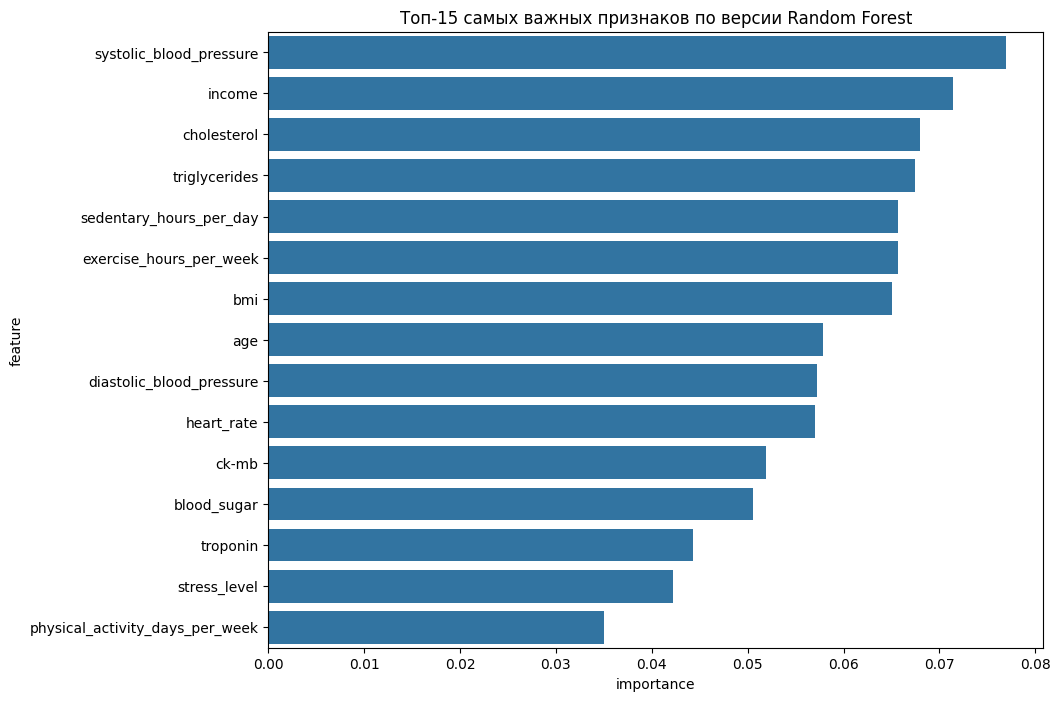

In [62]:
df_encoded_2 = pd.get_dummies(df_train_cleaned_no_abnormal_entries, columns=cat_features, drop_first=True)

X = df_encoded_2.drop([target_feature]+drop_features, axis=1)
y = df_encoded_2[target_feature]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

rf_model_2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model_2.fit(X_train, y_train)

feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model_2.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importances)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances.head(15), x='importance', y='feature')
plt.title('Топ-15 самых важных признаков по версии Random Forest')
plt.show()

In [63]:
# для RandomForest используем TreeExplainer
explainer = shap.TreeExplainer(rf_model_2)
shap_values = explainer.shap_values(X_train[:300])

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


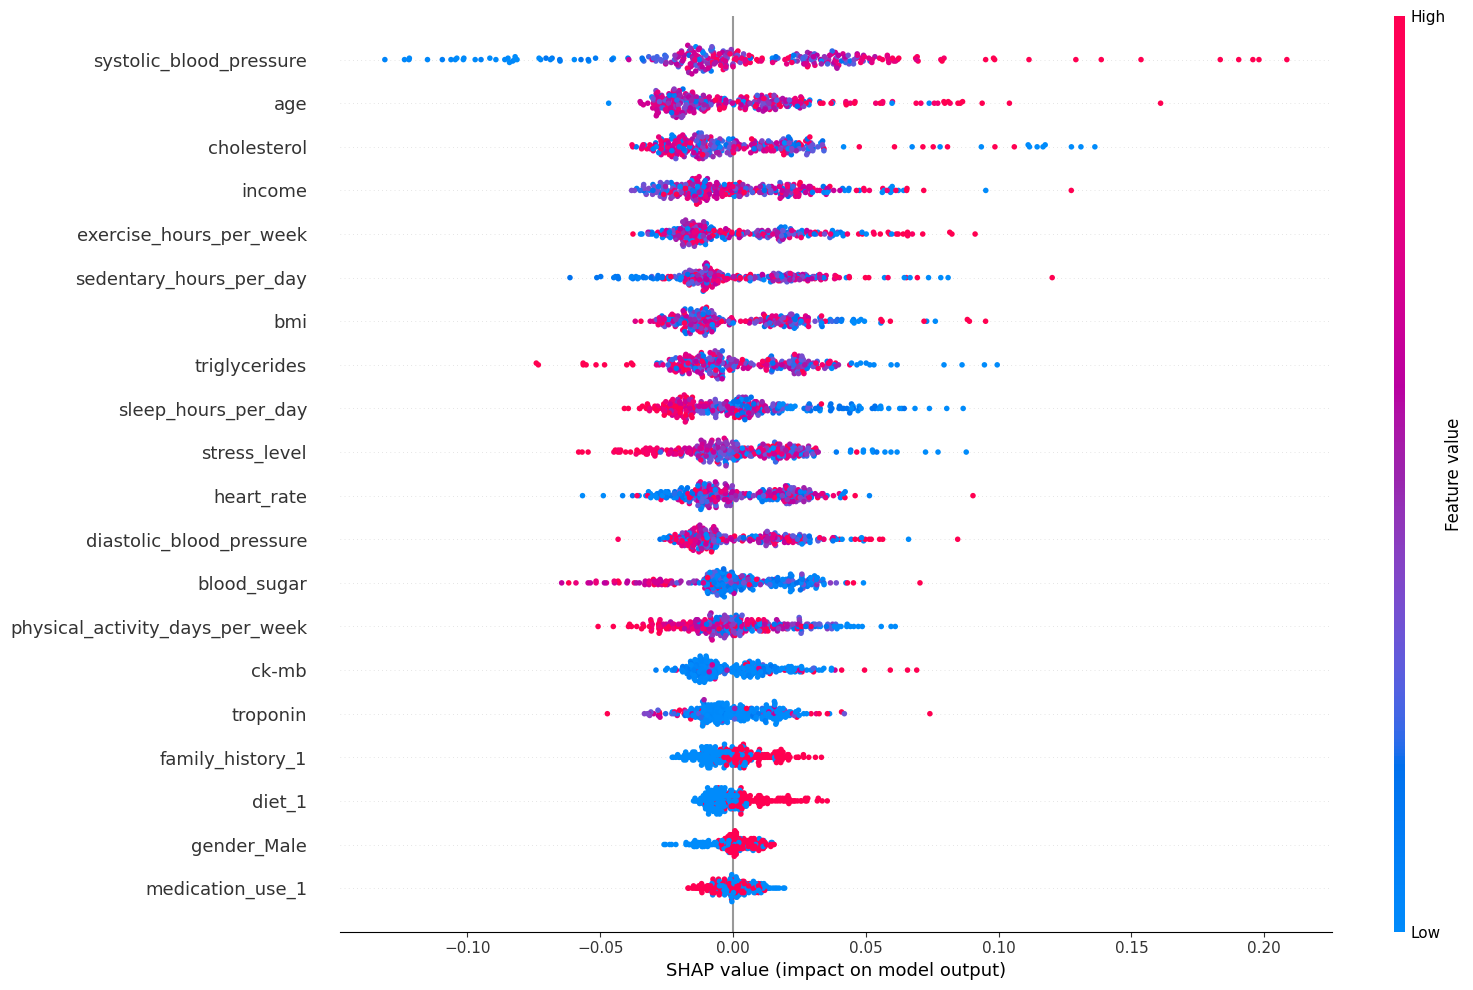

<Figure size 640x480 with 0 Axes>

In [64]:
# Создаем summary plot
shap.summary_plot(shap_values[:,:,1], X_train[:300], feature_names=X_train.columns.tolist(), plot_size=(16, 10))
plt.tight_layout()
plt.show()

In [65]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

gb_model_2 = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb_model_2.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [66]:
# для RandomForest используем TreeExplainer
explainer = shap.TreeExplainer(gb_model_2)
shap_values = explainer.shap_values(X_train[:300])

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


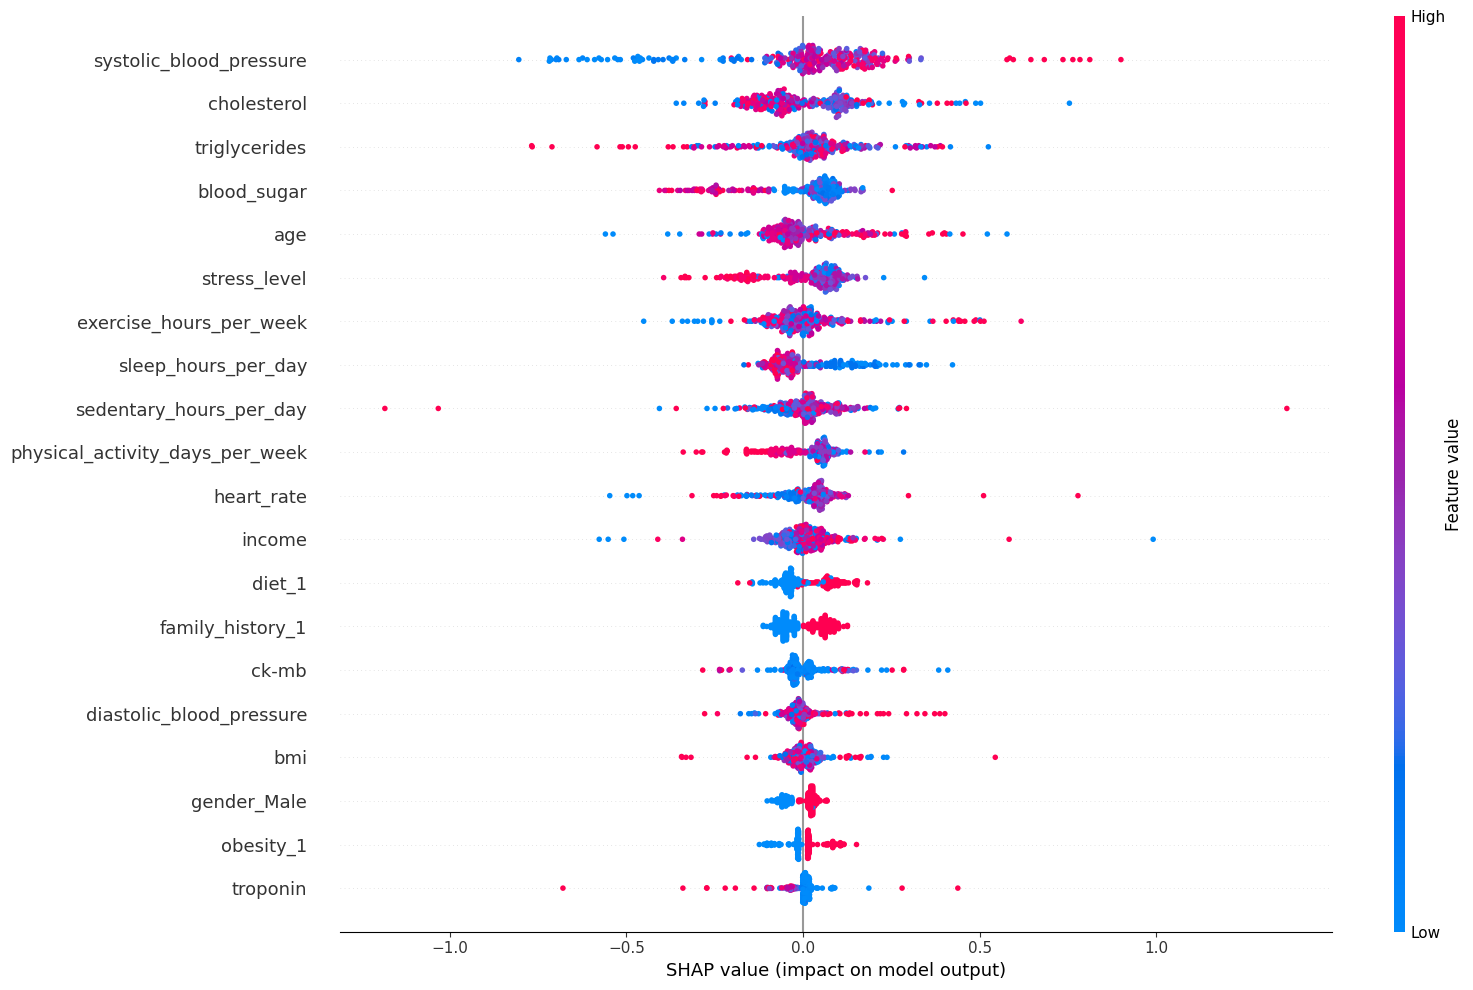

<Figure size 640x480 with 0 Axes>

In [67]:
# Создаем summary plot
shap.summary_plot(shap_values, X_train[:300], feature_names=X_train.columns.tolist(), plot_size=(16, 10))
plt.tight_layout()
plt.show()

**Выводы**
 - После удаления зашумленных значений из датафрейма картина влияния признаков стала более четкой
 - Появились выраженные группы значений для каждого признака: которые склоняют предсказание к одному из двух классов
 - Зависимость попрежнему нелинейна

# Теперь попробуем удалить подозрительные признаки

In [68]:
df_train_cleaned_no_abnormal_features = df_train_cleaned.drop(['blood_sugar', 'ck-mb', 'troponin'], axis=1)

df_train_cleaned_no_abnormal_features.shape

(8442, 24)

In [69]:
features = df_train_cleaned_no_abnormal_features.columns.tolist()

drop_features = [
    'id',
    'income'
]

target_feature = 'heart_attack_risk_(binary)'

cat_features = [
    'diabetes',
    'family_history',
    'obesity',
    'alcohol_consumption',
    'diet',
    'gender',
    'smoking',
    'medication_use'
]

num_features = [
    f for f in features if f not in cat_features + [target_feature] + drop_features
]

num_features

['age',
 'cholesterol',
 'heart_rate',
 'exercise_hours_per_week',
 'previous_heart_problems',
 'stress_level',
 'sedentary_hours_per_day',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

In [70]:
df_encoded_3 = pd.get_dummies(df_train_cleaned_no_abnormal_features, columns=cat_features, drop_first=True)

X = df_encoded_3.drop([target_feature]+drop_features, axis=1)
y = df_encoded_3[target_feature]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

In [71]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

gb_model_3 = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb_model_3.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [72]:
# для RandomForest используем TreeExplainer
explainer = shap.TreeExplainer(gb_model_3)
shap_values = explainer.shap_values(X_train[:300])

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


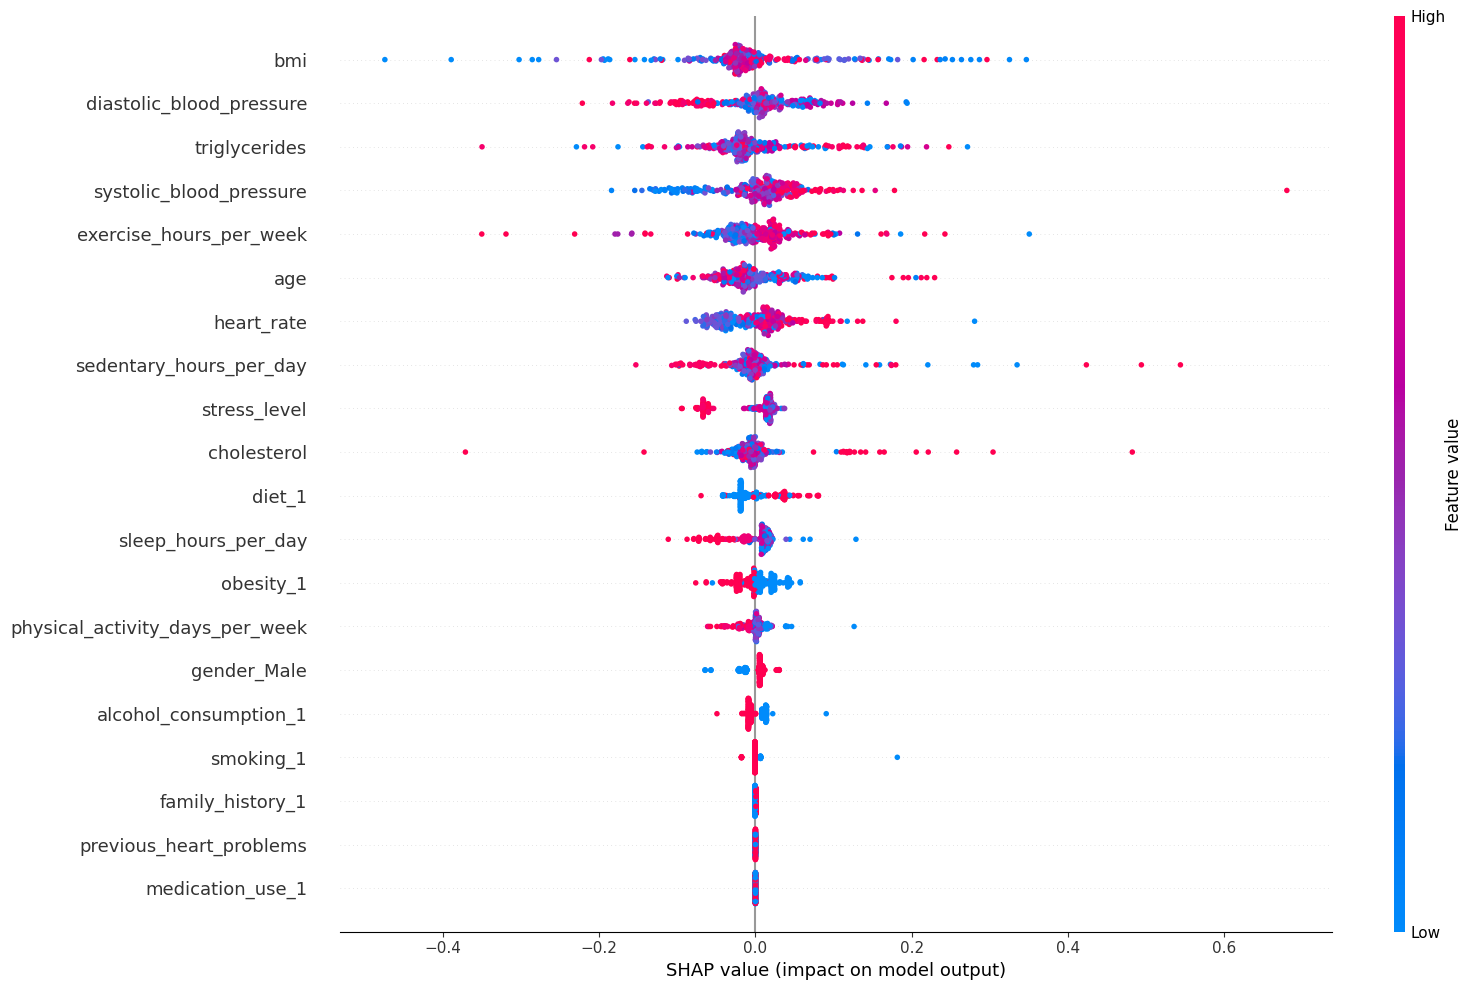

<Figure size 640x480 with 0 Axes>

In [73]:
# Создаем summary plot
shap.summary_plot(shap_values, X_train[:300], feature_names=X_train.columns.tolist(), plot_size=(16, 10))
plt.tight_layout()
plt.show()

**Вывод**
 - Удаление самих признаков из датасета мало повлияло на картину значимости признаков, группы значений (низких и высоких) смешаны, группы сконцентрированы около нуля (мало влияют на целевой признак)

## Промежуточный вывод

 - Зависимости признаков нелинейны
 - Удаление зашумленнных значений должно положительно сказаться на обучении качестве модели
 - ✅ **roc_auc** - Для целевого признака выявлен умеренный дисбаланс классов, в качестве метрики будем использовать roc_auc, как устойчивою к дисбалансу а также потому что нам не надо отдавать приоритет какому либо классу

# Обучение моделей

Для обучения будем использовать датафрейм без аномальных записей

In [74]:
features = df_train_cleaned_no_abnormal_entries.columns.tolist()

drop_features = [
    'id'
]

target_feature = 'heart_attack_risk_(binary)'

cat_features = [
    'diabetes',
    'family_history',
    'obesity',
    'alcohol_consumption',
    'diet',
    'gender',
    'smoking',
    'medication_use'
]

num_features = [
    f for f in features if f not in cat_features + [target_feature] + drop_features
]

num_features

['age',
 'cholesterol',
 'heart_rate',
 'exercise_hours_per_week',
 'previous_heart_problems',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'systolic_blood_pressure',
 'diastolic_blood_pressure']

In [75]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe',
            # OneHotEncoder(drop='first', handle_unknown='error')
            OneHotEncoder(drop='first', handle_unknown='ignore')
        )
    ]
)

num_pipe = Pipeline(
    [
        (
            'simpleImputer_num',
            SimpleImputer(missing_values=np.nan, strategy='median')
        )
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, cat_features),
     ('num', num_pipe, num_features)
    ],
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

На этапе выбора рассматривались все модели из param_grid, в последстии были закомментированы

In [76]:
# создаём словарь с гиперпараметрами для каждой модели
param_grid = [
    # {
    #     'models': [KNeighborsClassifier()],
    #     # нечётные числа чтобы избежать ситуации, когда число соседей разных классов совпадает
    #     'models__n_neighbors': range(3, 17, 2),
    #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    # },
    # {
    #     'models': [DecisionTreeClassifier(
    #         random_state=RANDOM_STATE,
    #     )],
    #     'models__max_depth': [3, 5, 7, 9, None],
    #     # ипользуем порции признаков (в долях)
    #     'models__max_features': [0.3, 0.5, 0.7, 'sqrt', 'log2'],
    #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    # },
    {
        'models': [ExtraTreesClassifier(random_state=RANDOM_STATE)],
        # 'models__n_estimators': [50, 100, 200],
        'models__n_estimators': [300],
        'models__max_depth': [3, 5, 7, None],
        'models__max_features': ['sqrt', 'log2', 0.3, 0.5],
        # 'models__class_weight': [None, 'balanced'],
        'preprocessor__num': ['passthrough'],
        'models__class_weight': ['balanced']
    },
    # {
    #     'models': [BaggingClassifier(
    #         random_state=RANDOM_STATE
    #     )],
    #     'models__n_estimators': [10, 50, 100],
    #     'models__max_samples': [0.5, 0.8, 1.0],
    #     'models__max_features': [0.5, 0.8, 1.0],
    #     'preprocessor__num': ['passthrough']
    # },
    # {
    #     'models': [LogisticRegression(
    #         random_state=RANDOM_STATE,
    #         solver='liblinear'
    #     )],
    #     'models__penalty': ['l1', 'l2'],
    #     # логарифмическая шкала
    #     'models__C': [0.01, 0.1, 1, 10],
    #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    # },
    # {
    #     'models': [SVC(
    #         random_state=RANDOM_STATE,
    #         # вычисляет вероятности - для корректной работы predict_proba()
    #         probability=True
    #     )],
    #     # логарифмическая шкала
    #     'models__C': [0.001, 0.01, 0.1, 1],
    #     # 'models__kernel': ['linear', 'rbf'], ## долгие вычисления
    #     # 'models__gamma': ['scale', 'auto'], ## долгие вычисления
    #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), PolynomialFeatures(), 'passthrough']
    # },
    # {
    #     'models': [GradientBoostingClassifier(random_state=RANDOM_STATE)],
    #     'models__n_estimators': [50, 100, 200],
    #     'models__learning_rate': [0.01, 0.1, 0.2],
    #     'models__max_depth': [3, 5, 7],
    #     'models__subsample': [0.8, 1.0],
    #     'preprocessor__num': ['passthrough']
    # },
]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    df_train_cleaned_no_abnormal_entries.drop(drop_features+[target_feature], axis=1),
    df_train_cleaned_no_abnormal_entries[target_feature],
    test_size = TEST_SIZE,
    random_state = RANDOM_STATE
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1418, 25), (473, 25), (1418,), (473,))

In [78]:
grid = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=33))])
,param_grid,"[{'models': [ExtraTreesCla...ndom_state=33)], 'models__class_weight': ['balanced'], 'models__max_depth': [3, 5, ...], 'models__max_features': ['sqrt', 'log2', ...], ...}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe', ...), ('num', ...)]"


In [79]:
print('Лучшая модель и её параметры:\n\n', grid.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid.best_score_)

# проверим работу модели на тестовой выборке
y_test_pred = grid.predict_proba(X_test)[:,1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['diabetes', 'family_history',
                                                   'obesity',
                                                   'alcohol_consumption',
                                                   'diet', 'gender', 'smoking',
                                             

In [82]:
## Проверим переобучение
abs(0.7739168992220504 - 0.783960261186556)

0.010043361964505615

**Выводы**
 - ✅ Переобучения нет (признаки переобучени "Train > Test на 0.05+", "Test score близок к 0.5")
 - ✅ Качество модели на тестовых данных несколько выше чем на тренировочных
 - ✅ Модель можно использовать с некоторым ограничениями, например для аналитики
 - Модель можно улучшить, главным образом через подготовку данных

## Рассмотрим влияние признаков на предсказания

In [83]:
best_model = grid.best_estimator_

In [84]:
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

In [85]:
explainer = shap.TreeExplainer(best_model.named_steps['models'])
shap_values = explainer.shap_values(X_train_transformed[:300])

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [86]:
preprocessor = best_model.named_steps['preprocessor']
feature_names = []
# Для one-hot encoded фичей
if 'ohe' in preprocessor.named_transformers_:
    ohe_transformer = preprocessor.named_transformers_['ohe']
    if hasattr(ohe_transformer, 'get_feature_names_out'):
        ohe_features = ohe_transformer.get_feature_names_out()
        feature_names.extend(ohe_features)

# Для числовых фичей
if 'num' in preprocessor.named_transformers_:
    num_features = preprocessor.transformers_[1][2]  # индексы числовых фичей
    feature_names.extend(num_features)

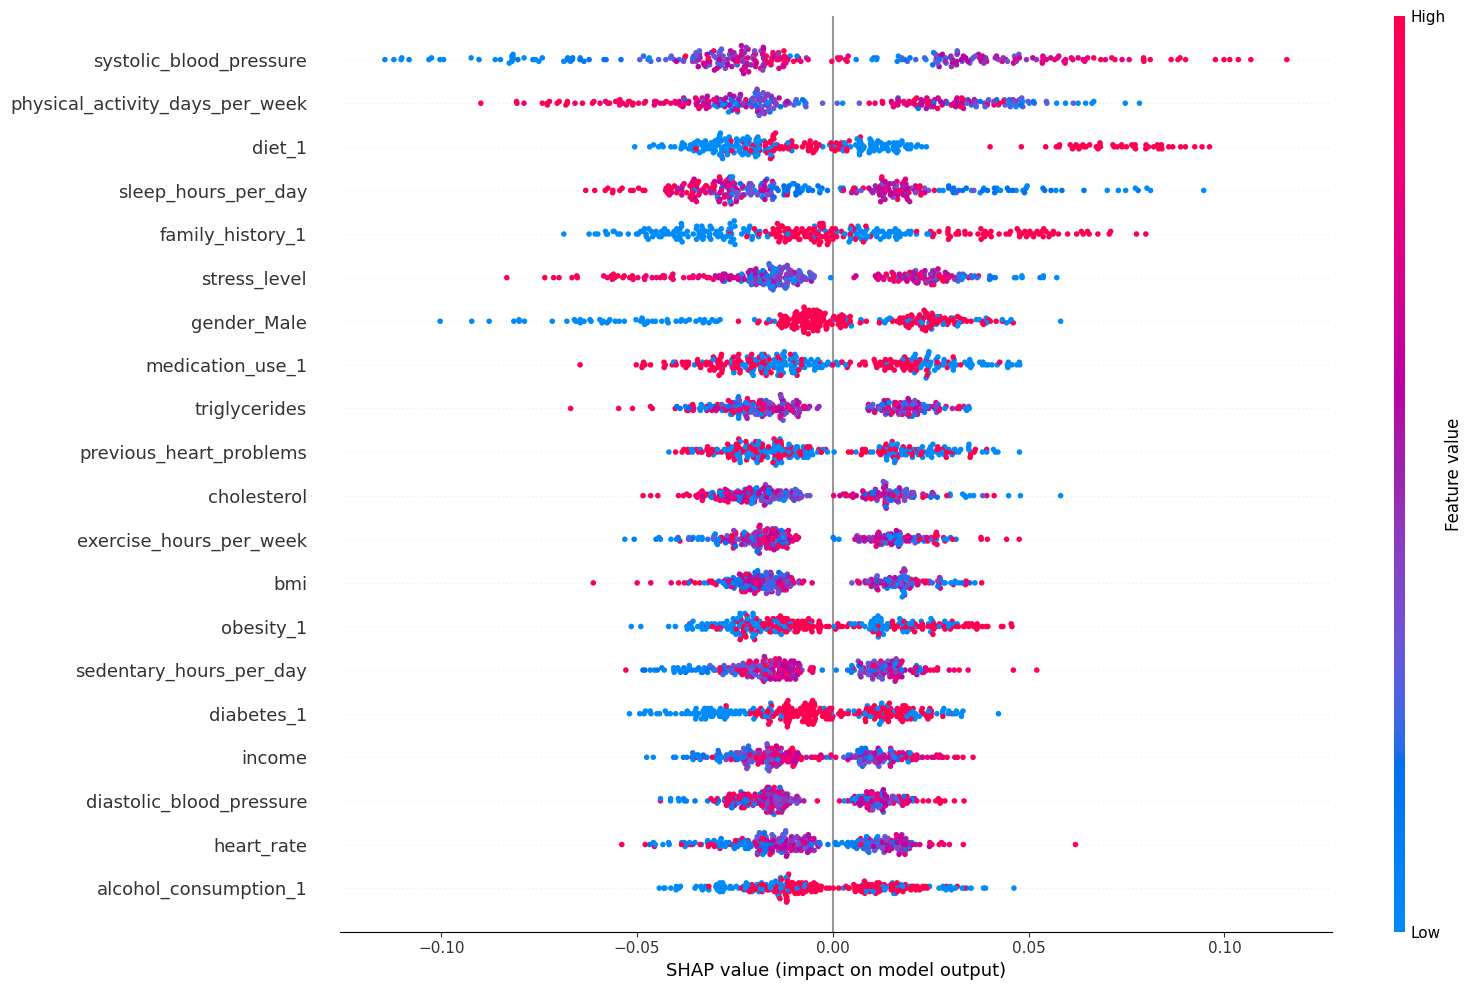

<Figure size 640x480 with 0 Axes>

In [87]:
# Создаем summary plot
shap.summary_plot(shap_values[:,:,1], X_train_transformed[:300], feature_names=feature_names, plot_size=(16, 10))
plt.tight_layout()
plt.show()

In [88]:
best_model.named_steps['models'].feature_importances_

array([0.03109379, 0.02779026, 0.03287583, 0.03046472, 0.01934443,
       0.02460263, 0.02617919, 0.00907251, 0.03218768, 0.04602343,
       0.04850162, 0.0474633 , 0.04823975, 0.03160207, 0.04951488,
       0.04927752, 0.04813145, 0.04982891, 0.05203275, 0.04896017,
       0.04717071, 0.03218102, 0.02763077, 0.03115678, 0.06054065,
       0.04813319])

                            feature  importance
24          systolic_blood_pressure    0.060541
18                    triglycerides    0.052033
17                              bmi    0.049829
14                     stress_level    0.049515
15          sedentary_hours_per_day    0.049278
19  physical_activity_days_per_week    0.048960
10                      cholesterol    0.048502
12          exercise_hours_per_week    0.048240
25         diastolic_blood_pressure    0.048133
16                           income    0.048131
11                       heart_rate    0.047463
20              sleep_hours_per_day    0.047171
9                               age    0.046023
2                         obesity_1    0.032876
8                  medication_use_1    0.032188
21                      blood_sugar    0.032181
13          previous_heart_problems    0.031602
23                         troponin    0.031157
0                        diabetes_1    0.031094
3             alcohol_consumption_1    0

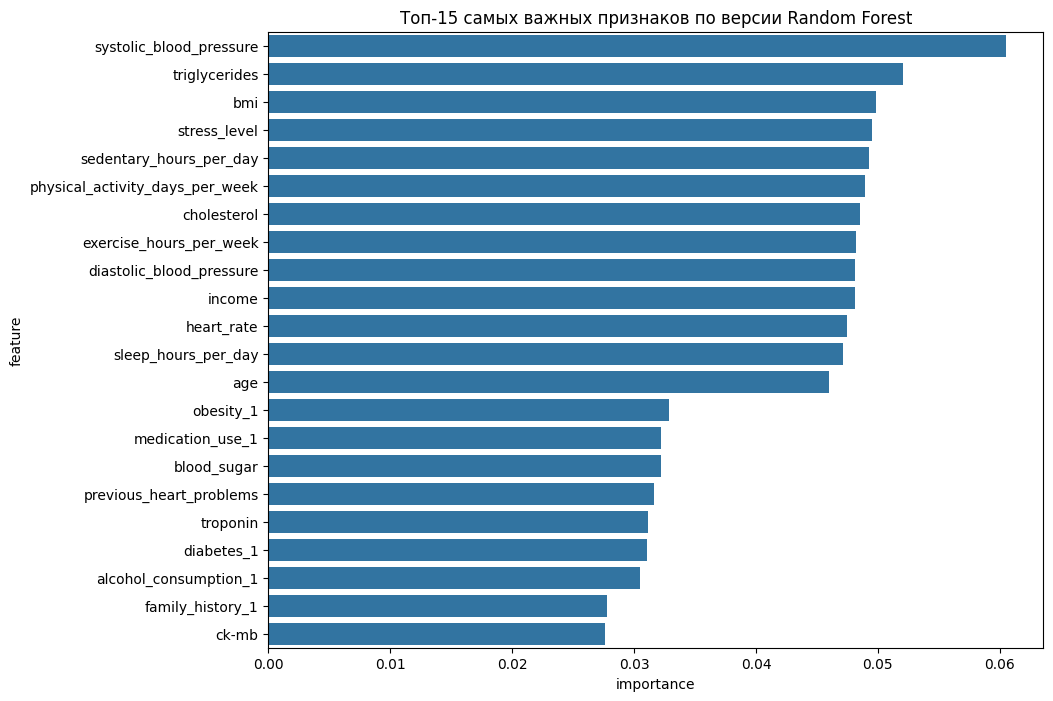

In [89]:
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model.named_steps['models'].feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importances)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances.head(22), x='importance', y='feature')
plt.title('Топ-15 самых важных признаков по версии Random Forest')
plt.show()

Сохраним модель

In [90]:
joblib.dump(best_model, 'model_healthcare_v1.pkl')

['model_healthcare_v1.pkl']

# Датаферейм без аномальных признаков

Для сравнения обучили вторую модель, качество которой оказалось существенно ниже. 

Код закомментирован для истории.

In [92]:
# df_train_cleaned_no_abnormal_features.columns.tolist()

In [93]:
# features = df_train_cleaned_no_abnormal_features.columns.tolist()

# drop_features = [
#     'id'
# ]

# target_feature = 'heart_attack_risk_(binary)'

# cat_features = [
#     'diabetes',
#     'family_history',
#     'obesity',
#     'alcohol_consumption',
#     'diet',
#     'gender',
#     'smoking',
#     'medication_use'
# ]

# num_features = [
#     f for f in features if f not in cat_features + [target_feature] + drop_features
# ]

# num_features

In [94]:
# ohe_pipe = Pipeline(
#     [
#         (
#             'simpleImputer_ohe',
#             SimpleImputer(missing_values=np.nan, strategy='most_frequent')
#         ),
#         (
#             'ohe',
#             OneHotEncoder(drop='first', handle_unknown='error')
#         )
#     ]
# )

# num_pipe = Pipeline(
#     [
#         (
#             'simpleImputer_num',
#             SimpleImputer(missing_values=np.nan, strategy='median')
#         )
#     ]
# )

# # создаём общий пайплайн для подготовки данных
# data_preprocessor = ColumnTransformer(
#     [('ohe', ohe_pipe, cat_features),
#      ('num', num_pipe, num_features)
#     ],
#     remainder='passthrough'
# )

# # создаём итоговый пайплайн: подготовка данных и модель
# pipe_final = Pipeline([
#     ('preprocessor', data_preprocessor),
#     ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
# ])

In [95]:
# # создаём словарь с гиперпараметрами для каждой модели
# param_grid = [
#     # {
#     #     'models': [KNeighborsClassifier()],
#     #     # нечётные числа чтобы избежать ситуации, когда число соседей разных классов совпадает
#     #     'models__n_neighbors': range(3, 17, 2),
#     #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
#     # },
#     # {
#     #     'models': [DecisionTreeClassifier(
#     #         random_state=RANDOM_STATE,
#     #     )],
#     #     'models__max_depth': [3, 5, 7, 9, None],
#     #     # ипользуем порции признаков (в долях)
#     #     'models__max_features': [0.3, 0.5, 0.7, 'sqrt', 'log2'],
#     #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
#     # },
#     # {
#     #     'models': [ExtraTreesClassifier(random_state=RANDOM_STATE)],
#     #     'models__n_estimators': [50, 100, 200],
#     #     'models__max_depth': [3, 5, 7, None],
#     #     'models__max_features': ['sqrt', 'log2', 0.3, 0.5],
#     #     'models__class_weight': [None, 'balanced'],
#     #     'preprocessor__num': ['passthrough']
#     # },
#     {
#         'models': [BaggingClassifier(
#             random_state=RANDOM_STATE
#         )],
#         'models__n_estimators': [10, 50, 100],
#         'models__max_samples': [0.5, 0.8, 1.0],
#         'models__max_features': [0.5, 0.8, 1.0],
#         'preprocessor__num': ['passthrough']
#     },
#     # {
#     #     'models': [LogisticRegression(
#     #         random_state=RANDOM_STATE,
#     #         solver='liblinear'
#     #     )],
#     #     'models__penalty': ['l1', 'l2'],
#     #     # логарифмическая шкала
#     #     'models__C': [0.01, 0.1, 1, 10],
#     #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
#     # },
#     # {
#     #     'models': [SVC(
#     #         random_state=RANDOM_STATE,
#     #         # вычисляет вероятности - для корректной работы predict_proba()
#     #         probability=True
#     #     )],
#     #     # логарифмическая шкала
#     #     'models__C': [0.001, 0.01, 0.1, 1],
#     #     # 'models__kernel': ['linear', 'rbf'], ## долгие вычисления
#     #     # 'models__gamma': ['scale', 'auto'], ## долгие вычисления
#     #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), PolynomialFeatures(), 'passthrough']
#     # },
#     # {
#     #     'models': [GradientBoostingClassifier(random_state=RANDOM_STATE)],
#     #     'models__n_estimators': [50, 100, 200],
#     #     'models__learning_rate': [0.01, 0.1, 0.2],
#     #     'models__max_depth': [3, 5, 7],
#     #     'models__subsample': [0.8, 1.0],
#     #     'preprocessor__num': ['passthrough']
#     # },
# ]

In [96]:
# X_train, X_test, y_train, y_test = train_test_split(
#     df_train_cleaned_no_abnormal_features.drop(drop_features+[target_feature], axis=1),
#     df_train_cleaned_no_abnormal_features[target_feature],
#     test_size = TEST_SIZE,
#     random_state = RANDOM_STATE
# )

# X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [97]:
# X_train.columns.tolist()

In [98]:
# grid = GridSearchCV(
#     pipe_final,
#     param_grid=param_grid,
#     cv=5,
#     scoring='roc_auc',
#     n_jobs=-1
# )
# grid.fit(X_train, y_train)

In [99]:
# print('Лучшая модель и её параметры:\n\n', grid.best_estimator_)
# print ('Метрика лучшей модели на тренировочной выборке:', grid.best_score_)

# # проверим работу модели на тестовой выборке
# y_test_pred = grid.predict_proba(X_test)[:,1]
# print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

# Предсказания для тестовых данных

Подготовим тестовые данные:
 - удалим лишние неинформативные колонки
 - пропуски осавим, пропуски будут обработаты в соответствии с пайплайном модели
 - сохраним отдельно ID записей, после предсказания привяжем обратно

In [101]:
test_data.columns.tolist()

['age',
 'cholesterol',
 'heart_rate',
 'diabetes',
 'family_history',
 'smoking',
 'obesity',
 'alcohol_consumption',
 'exercise_hours_per_week',
 'diet',
 'previous_heart_problems',
 'medication_use',
 'stress_level',
 'sedentary_hours_per_day',
 'income',
 'bmi',
 'triglycerides',
 'physical_activity_days_per_week',
 'sleep_hours_per_day',
 'blood_sugar',
 'ck-mb',
 'troponin',
 'gender',
 'systolic_blood_pressure',
 'diastolic_blood_pressure',
 'id']

In [102]:
test_data_id = test_data['id']

test_data_id.shape

(966,)

In [103]:
test_data.head(5)

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,...,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ck-mb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure,id
0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,...,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,...,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,...,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,...,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,...,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825


In [104]:
test_data_no_id = test_data.drop(['id'], axis = 1)

test_data_no_id.shape

(966, 25)

In [105]:
y_pred = best_model.predict(test_data_no_id)

/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [106]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,

In [107]:
result_df = pd.DataFrame({
    'id': test_data_id,
    'prediction': y_pred
})

In [108]:
result_df

,id,prediction
0,7746,0
1,4202,0
2,6632,1
3,4639,0
4,4825,0
...,...,...
961,9271,1
962,8012,1
963,2456,0
964,4984,0


In [109]:
result_df.to_csv('predictions.csv', index=False)

## Выводы

 - В ходе роботы был произведен анализ данных
 - В данных были выявлены аномалии
 - Для аномальных данных был исполользован вариант удаления записей, содержащих аномалии
 - Были обучены модели МО, в качестве лучшей выбрана модель ExtraTreesClassifier:
     - Метрика лучшей модели на тренировочной выборке: 0.77
     - Метрика ROC-AUC на тестовой выборке: 0.78
 - Сформирована таблица предсказания для тестовой выборки